### bootstrapping part below

In [4]:
install.packages('dplyr')
install.packages('ggplot2')
install.packages('Matrix')
install.packages('scran')
install.packages('Rtsne')
install.packages('BiocParallel')
install.packages('irlba')
install.packages('batchelor')
install.packages('stringr')
install.packages('gridExtra') ## can be replaced by just cowplot
install.packages('cowplot')
install.packages('M3C')
install.packages('Seurat')
install.packages('tidyr')


package 'dplyr' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aamw4\AppData\Local\Temp\RtmpC8H6Ot\downloaded_packages
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aamw4\AppData\Local\Temp\RtmpC8H6Ot\downloaded_packages

  There is a binary version available but the source version is later:
       binary source needs_compilation
Matrix 1.2-18  1.3-2              TRUE

  Binaries will be installed
package 'Matrix' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aamw4\AppData\Local\Temp\RtmpC8H6Ot\downloaded_packages


Warning message:
"package 'scran' is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"
also installing the dependency 'Rcpp'




package 'Rcpp' successfully unpacked and MD5 sums checked
package 'Rtsne' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aamw4\AppData\Local\Temp\RtmpC8H6Ot\downloaded_packages


Warning message:
"package 'BiocParallel' is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"


package 'irlba' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aamw4\AppData\Local\Temp\RtmpC8H6Ot\downloaded_packages


Warning message:
"package 'batchelor' is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"
also installing the dependency 'stringi'




package 'stringi' successfully unpacked and MD5 sums checked
package 'stringr' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aamw4\AppData\Local\Temp\RtmpC8H6Ot\downloaded_packages
package 'gridExtra' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aamw4\AppData\Local\Temp\RtmpC8H6Ot\downloaded_packages
package 'cowplot' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aamw4\AppData\Local\Temp\RtmpC8H6Ot\downloaded_packages


Warning message:
"package 'M3C' is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"
also installing the dependencies 'sys', 'bitops', 'fs', 'askpass', 'yaml', 'cpp11', 'gtools', 'caTools', 'BH', 'sass', 'jquerylib', 'sitmo', 'globals', 'listenv', 'parallelly', 'plyr', 'curl', 'mime', 'openssl', 'zoo', 'htmlwidgets', 'tidyr', 'lazyeval', 'crosstalk', 'data.table', 'promises', 'rappdirs', 'gplots', 'reshape2', 'RcppArmadillo', 'httpuv', 'xtable', 'sourcetools', 'later', 'fastmap', 'commonmark', 'bslib', 'cachem', 'spatstat.data', 'spatstat.utils', 'spatstat.sparse', 'abind', 'tensor', 'goftest', 'deldir', 'polyclip', 'FNN', 'RSpectra', 'dqrng', 'fitdistrplus', 'future', 'future.apply', 'ggrepel', 'ggridges', 'httr', 'ica', 'igraph', 'leiden', 'lmtest', 'matrixStats', 'miniUI', 'patchwork', 'pbapply', 'plotly', 'png', 'RANN',


  There is a binary version available but the source version is later:
              binary source needs_compilation
spatstat.core 1.65-5  2.0-0              TRUE

  Binaries will be installed
package 'sys' successfully unpacked and MD5 sums checked
package 'bitops' successfully unpacked and MD5 sums checked
package 'fs' successfully unpacked and MD5 sums checked
package 'askpass' successfully unpacked and MD5 sums checked
package 'yaml' successfully unpacked and MD5 sums checked
package 'cpp11' successfully unpacked and MD5 sums checked
package 'gtools' successfully unpacked and MD5 sums checked
package 'caTools' successfully unpacked and MD5 sums checked
package 'BH' successfully unpacked and MD5 sums checked
package 'sass' successfully unpacked and MD5 sums checked
package 'jquerylib' successfully unpacked and MD5 sums checked
package 'sitmo' successfully unpacked and MD5 sums checked
package 'globals' successfully unpacked and MD5 sums checked
package 'listenv' successfully unpack

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    #library(scran)
    library(Rtsne)
    #library(BiocParallel)
    require(irlba)
    #library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    #library(M3C)
    library(Seurat)
    library(tidyr)
})

In [3]:
source("C:/Users/aamw4/home/aamw4/plot_colours.R")
options(repr.plot.width = 20, repr.plot.height = 10)

In [2]:
#WT chimera
meta = read.table("C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab", header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
meta = meta %>% filter(celltype.mapped != 'Doublet' & celltype.mapped != 'Stripped')
meta = meta %>% filter(stage == 'E8.5')
meta = meta %>% filter(!(tdTom == 'nan'))

meta_haem = read.csv("C:/Users/aamw4/home/aamw4/wtinjection/big_meta_mapping+haem.csv")

#Mixl1 chimera
out_folder = "C:/Users/aamw4/home/aamw4/"
own_meta = read.table(paste0(out_folder,"big_meta_mapping+meso3.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
own_meta <- own_meta %>% filter(!is.na(own_meta$tdTom))

   

In [232]:
#for haem
chim_meta = read.table("C:/Users/aamw4/home/aamw4/Mixl1/big_meta_mapping.tab", header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [238]:
#for gut
gut_meta = read.table("C:/Users/aamw4/home/aamw4/Mixl1/big_meta_mapping.tab", header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [240]:
gut_meta = gut_meta %>% filter(!is.na(gut_meta$tdTom))

In [198]:
chim_meta <- chim_meta %>% filter(!is.na(chim_meta$tdTom))
chim_meta

cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,...,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,tdTom,weight,stage.mapped,celltype.mapped,closest.cell,haem_subclust.mapped
<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,...,<lgl>,<lgl>,<lgl>,<lgl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
chim_cell_2,mixl_1,E8.5,AAACCCAAGGGACTGT,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,NA,pos,139333,E8.5,Erythroid3,atlas_cell_39819,Ery3
chim_cell_8,mixl_1,E8.5,AAACCCATCAGCCTTC,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,NA,pos,139339,E8.5,Erythroid3,atlas_cell_37672,Ery3
chim_cell_10,mixl_1,E8.5,AAACCCATCATTGGTG,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,NA,pos,139341,E8.5,Erythroid3,atlas_cell_136027,Ery3
chim_cell_12,mixl_1,E8.5,AAACGAAAGGCCTGAA,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,NA,pos,139343,E8.5,Erythroid3,atlas_cell_100974,Ery3
chim_cell_13,mixl_1,E8.5,AAACGAAGTGTAAACA,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,NA,pos,139344,E8.5,Erythroid3,atlas_cell_136832,Ery3
chim_cell_18,mixl_1,E8.5,AAACGCTCAATGTTGC,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,NA,pos,139349,E8.5,Erythroid3,atlas_cell_40941,Ery4
chim_cell_20,mixl_1,E8.5,AAACGCTCATCTCCCA,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,NA,pos,139351,E8.5,Erythroid3,atlas_cell_40941,Ery4
chim_cell_22,mixl_1,E8.5,AAACGCTTCCGCTGTT,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,NA,pos,139353,E8.5,Erythroid3,atlas_cell_138495,Ery3
chim_cell_23,mixl_1,E8.5,AAACGCTTCGAACCAT,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,NA,pos,139354,E8.5,Erythroid3,atlas_cell_40412,Ery3


In [237]:
table(own_meta$sample, own_meta$tdTom)

        
          neg  pos
  mixl_1 6756    0
  mixl_2    0 8941
  mixl_3 3964    0
  mixl_4    0 3168
  mixl_5 7387    0
  mixl_6    0 6992

In [132]:
celltype_colours = list('#532C8A',
 '#c19f70',
 '#f9decf',
 '#c9a997',
 '#B51D8D',
 '#3F84AA',
 '#9e6762',
 '#354E23',
 '#F397C0',
 '#eda450',
 '#635547',
 '#C72228',
 '#EF4E22',
 '#f77b59',
 '#989898',
 '#7F6874',
 '#8870ad',
 '#647a4f',
 '#EF5A9D',
 '#FBBE92',
 '#139992',
 '#ed8f84',
 '#DFCDE4',
 '#8EC792',
 '#C594BF',
 '#C3C388',
 '#0F4A9C',
 '#FACB12',
 '#8DB5CE',
 '#1A1A1A',
 '#C9EBFB',
 '#DABE99',
 '#65A83E',
 '#005579',
 '#CDE088',
 '#BBDCA8',
 '#F6BFCB'
               ,
'#F5F5F5')

#adata_chim.uns['celltype.mapped_colors'] = lista_colori
#adata.uns['celltype_colors'] = lista_colori
#adata_atlas.uns['celltype_colors'] = lista_colori

In [254]:
wt

Var1,Var2,Freq
<fct>,<fct>,<dbl>
Foregut 1,neg,0.06819182
Foregut 2,neg,0.06819182
Hindgut 1,neg,0.04546455
Hindgut 2,neg,0.27273727
Midgut,neg,0.06819182
Midgut/Hindgut,neg,0.20455545
Pharyngeal endoderm,neg,0.27273727
Foregut 1,pos,0.08001000
Foregut 2,pos,0.12001000


In [255]:
pdf3 = table(meta$meso.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.00001

p1 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20) ,
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))])

In [256]:
wt = pdf3

In [257]:
pdf3 = table(own_meta$meso.mapped, own_meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.00001

p2 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("Mixl1 KO injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "right", text = element_text(size = 20),
        axis.title.x = element_blank()) +
  scale_x_discrete(limits = c("Presomitic_mesoderm", "Posterior-most_somites", "Dermomyotome", "Sclerotome", "Anterior-most_somites", "Head_mesoderm"))

In [258]:
ko = pdf3

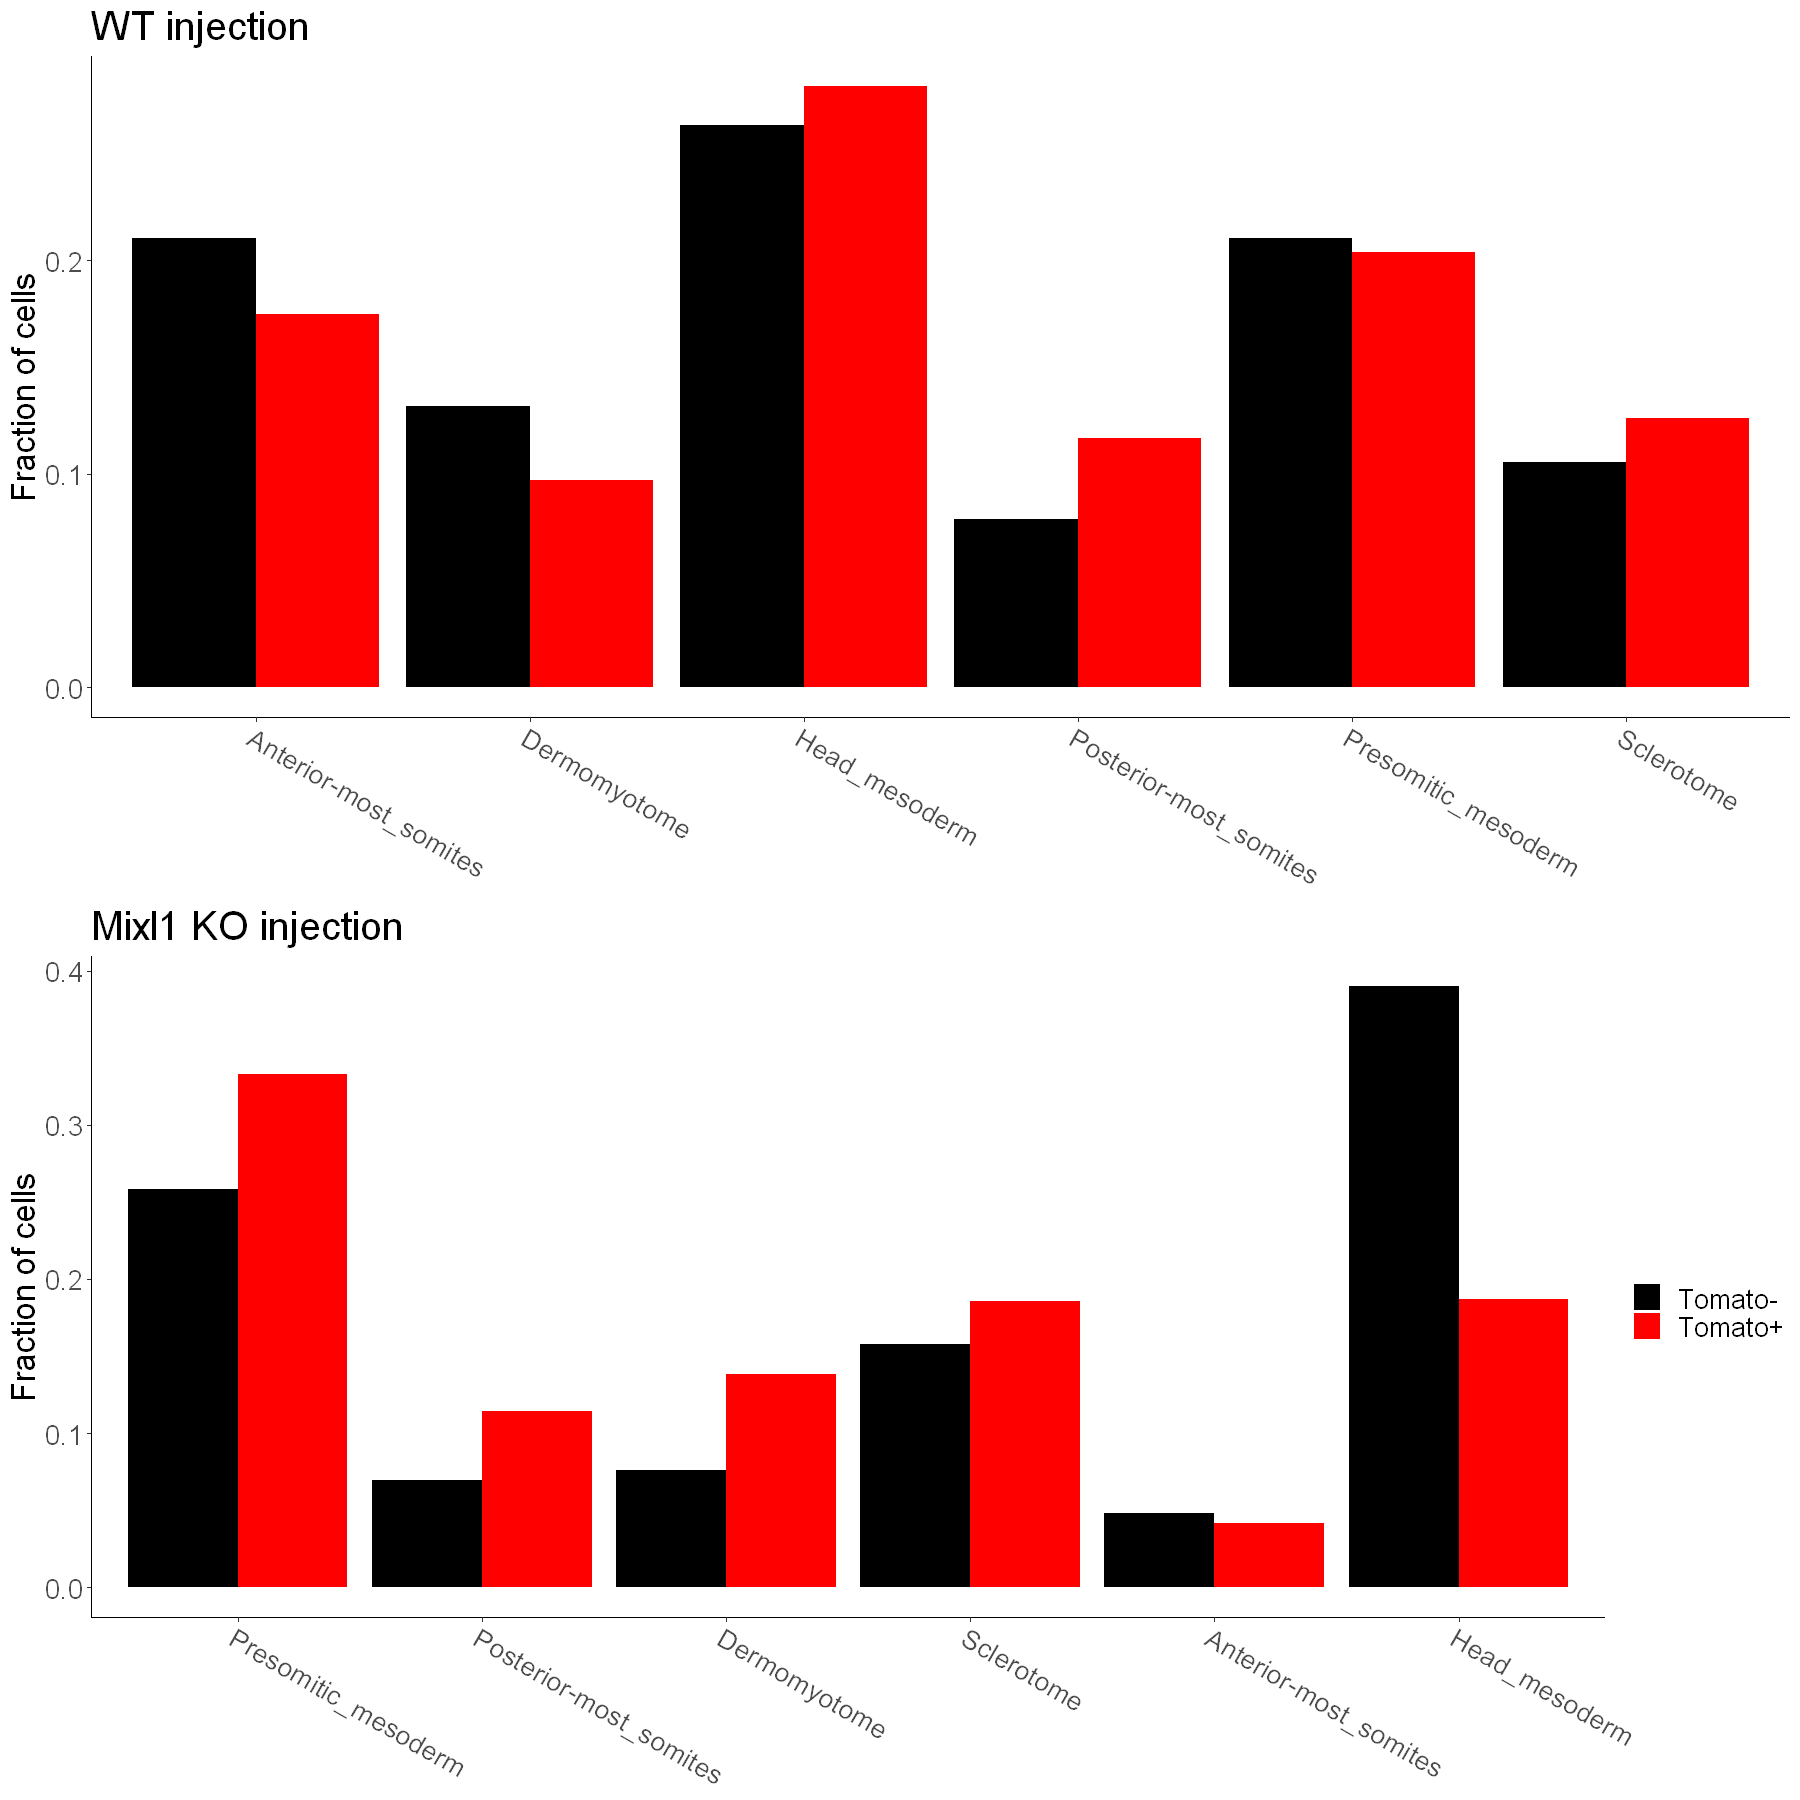

In [259]:
options(repr.plot.width = 15, repr.plot.height = 15)
grid.arrange(p1, p2, nrow =2)

In [260]:
pdf("C:/Users/aamw4/home/aamw4/celltype_ko_wt_meso_fraction_comparison.pdf", height=14, width=15)
    grid.arrange(p1, p2, nrow =2)
dev.off()

png 
  2

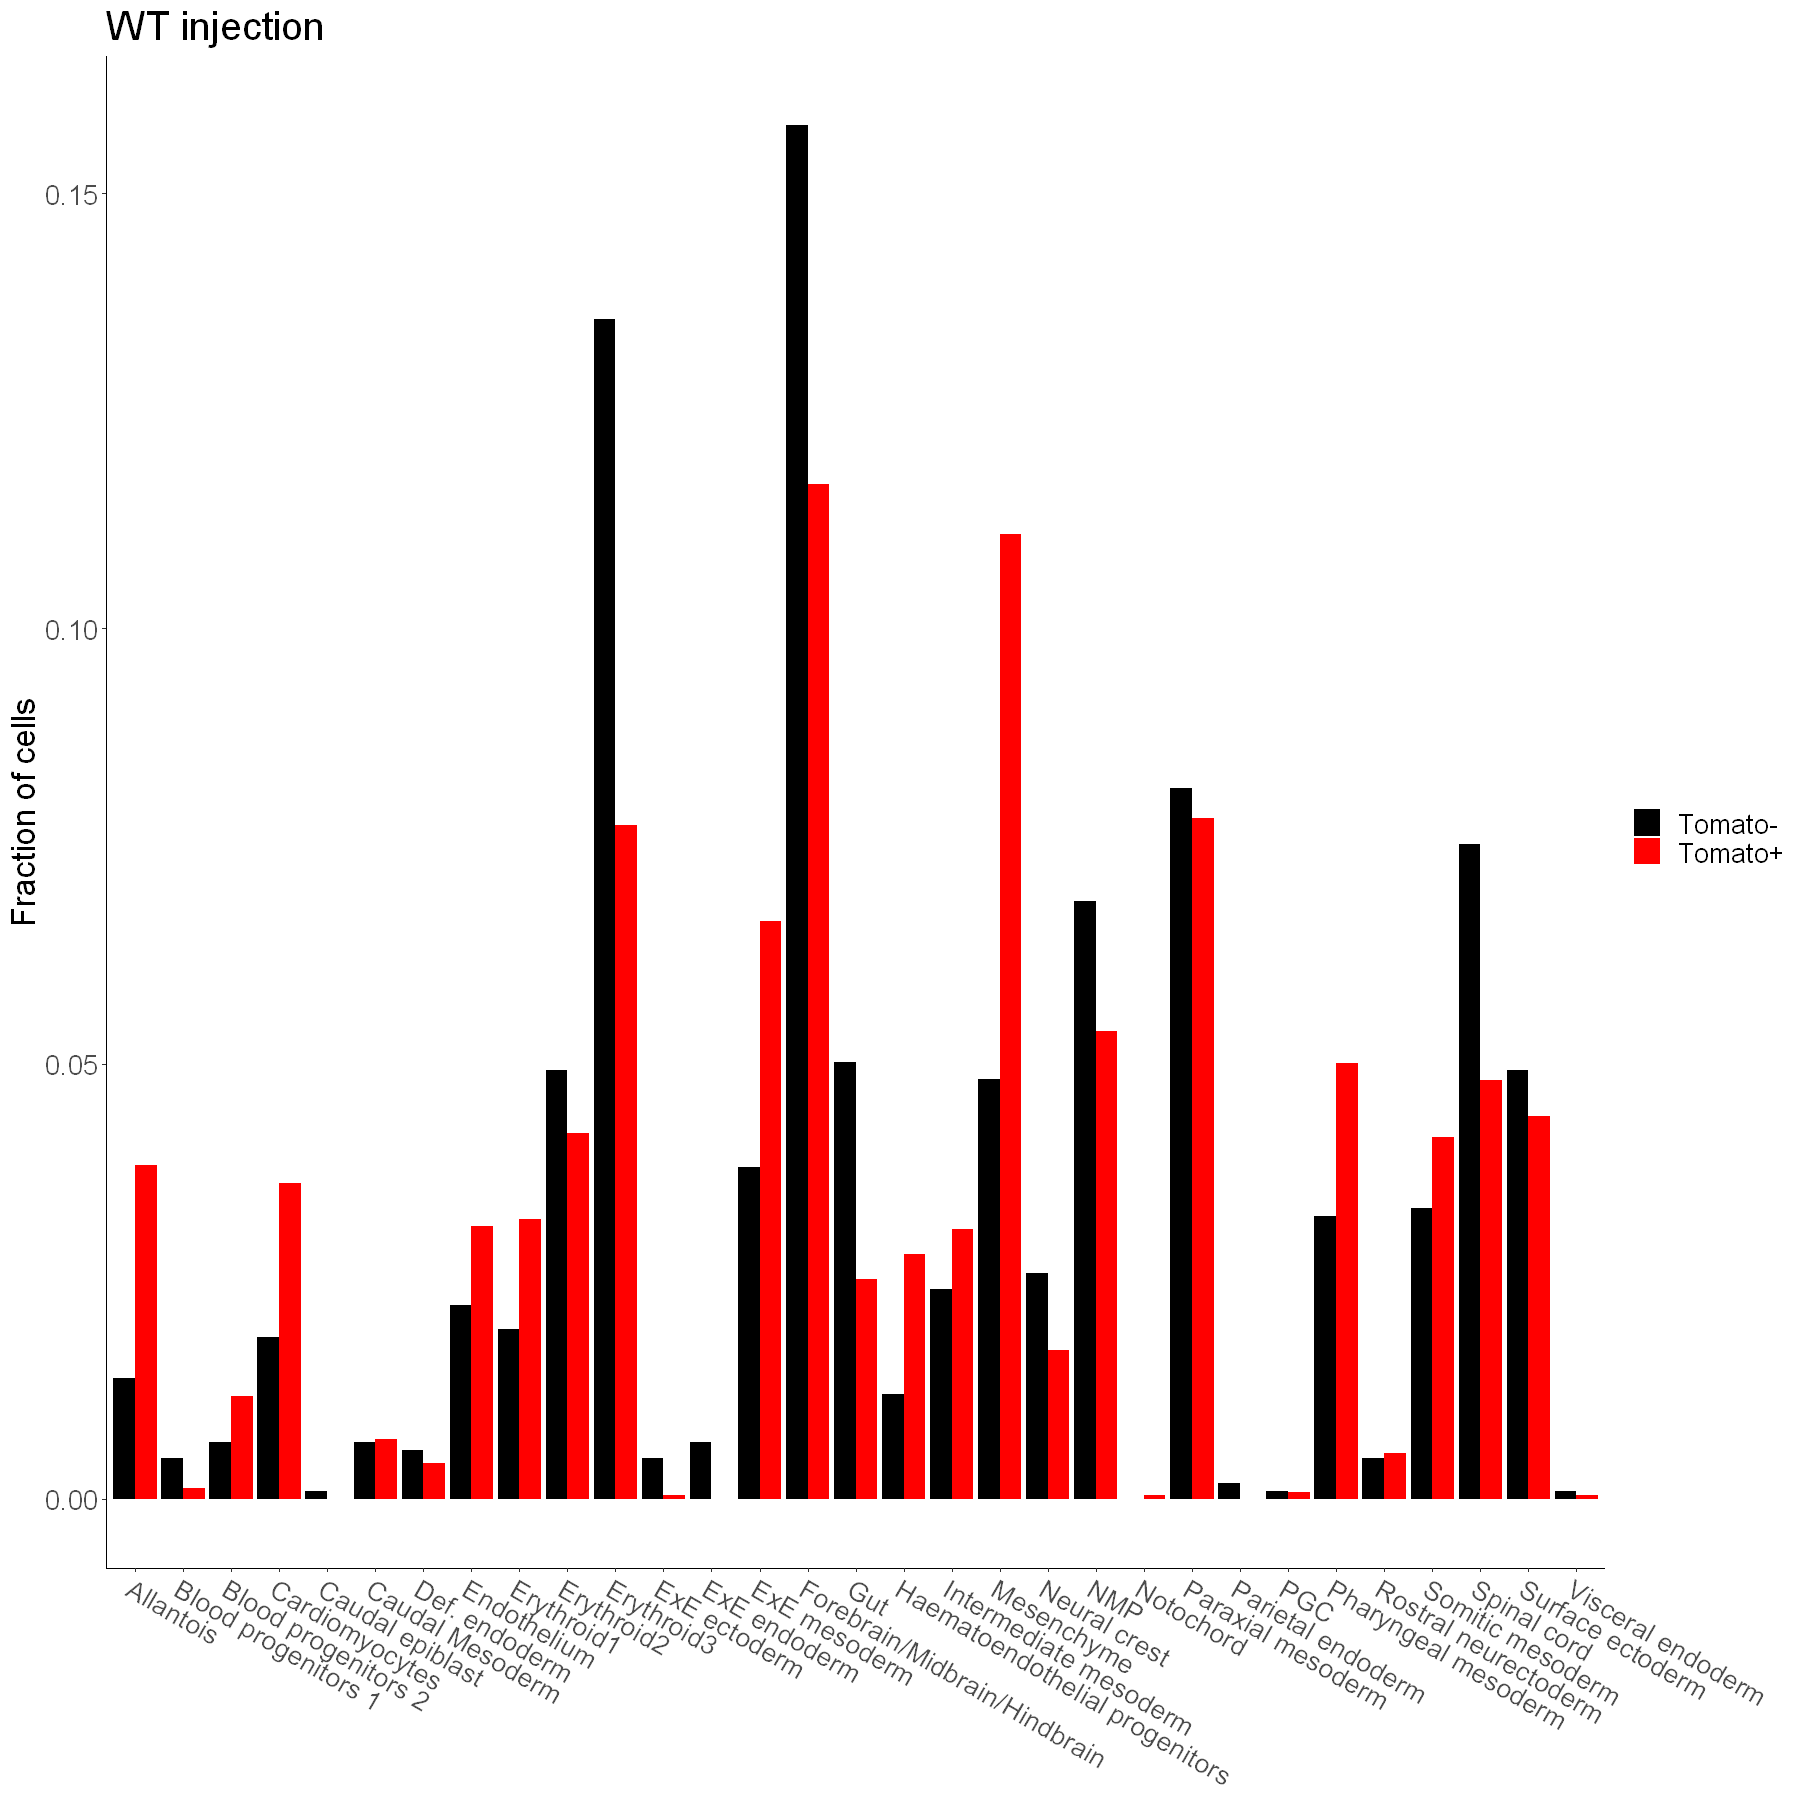

In [7]:
pdf3 = table(meta$celltype.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.00001

p1 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "right", text = element_text(size = 20) ,
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

wt = pdf3


options(repr.plot.width = 15, repr.plot.height = 15)
grid.arrange(p1)


In [9]:
pdf("C:/Users/aamw4/home/aamw4/celltype_wt_celltype_fraction.pdf", height=14, width=15)
    grid.arrange(p1)
dev.off()

png 
  2

In [261]:
head(wt)

,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
1,Anterior-most_somites,neg,0.21053632
2,Dermomyotome,neg,0.13158895
3,Head_mesoderm,neg,0.26316789
4,Posterior-most_somites,neg,0.07895737
5,Presomitic_mesoderm,neg,0.21053632
6,Sclerotome,neg,0.10527316


In [262]:
wt_ratio = spread(wt, Var2, Freq)
colnames(wt_ratio) = c('Var1','host', 'inject')
wt_ratio$ratio_wt = log(wt_ratio$inject/wt_ratio$host)
wt_ratio = wt_ratio %>% select(Var1, ratio_wt)

ko_ratio = spread(ko, Var2, Freq)
colnames(ko_ratio) = c('Var1','host', 'inject')
ko_ratio$ratio_ko = log(ko_ratio$inject/ko_ratio$host)
ko_ratio = ko_ratio %>% select(Var1, ratio_ko)

merged = merge(wt_ratio, ko_ratio, by='Var1')

merged$ratio = abs(merged$ratio_ko/merged$ratio_wt)
merged$sign =  ifelse(merged$ratio_ko < 0,"negative", "positive")
merged$ratio = ifelse(merged$sign == 'negative', -1*merged$ratio, merged$ratio)

In [263]:
head(merged)

,Var1,ratio_wt,ratio_ko,ratio,sign
,<fct>,<dbl>,<dbl>,<dbl>,<chr>
1,Anterior-most_somites,-0.18620289,-0.1370356,-0.7359475,negative
2,Dermomyotome,-0.30396865,0.5989638,1.9704789,positive
3,Head_mesoderm,0.06756543,-0.7358378,-10.8907440,negative
4,Posterior-most_somites,0.38911070,0.4957243,1.2739930,positive
5,Presomitic_mesoderm,-0.03206038,0.2541847,7.9283116,positive
6,Sclerotome,0.18149640,0.1610906,0.8875689,positive


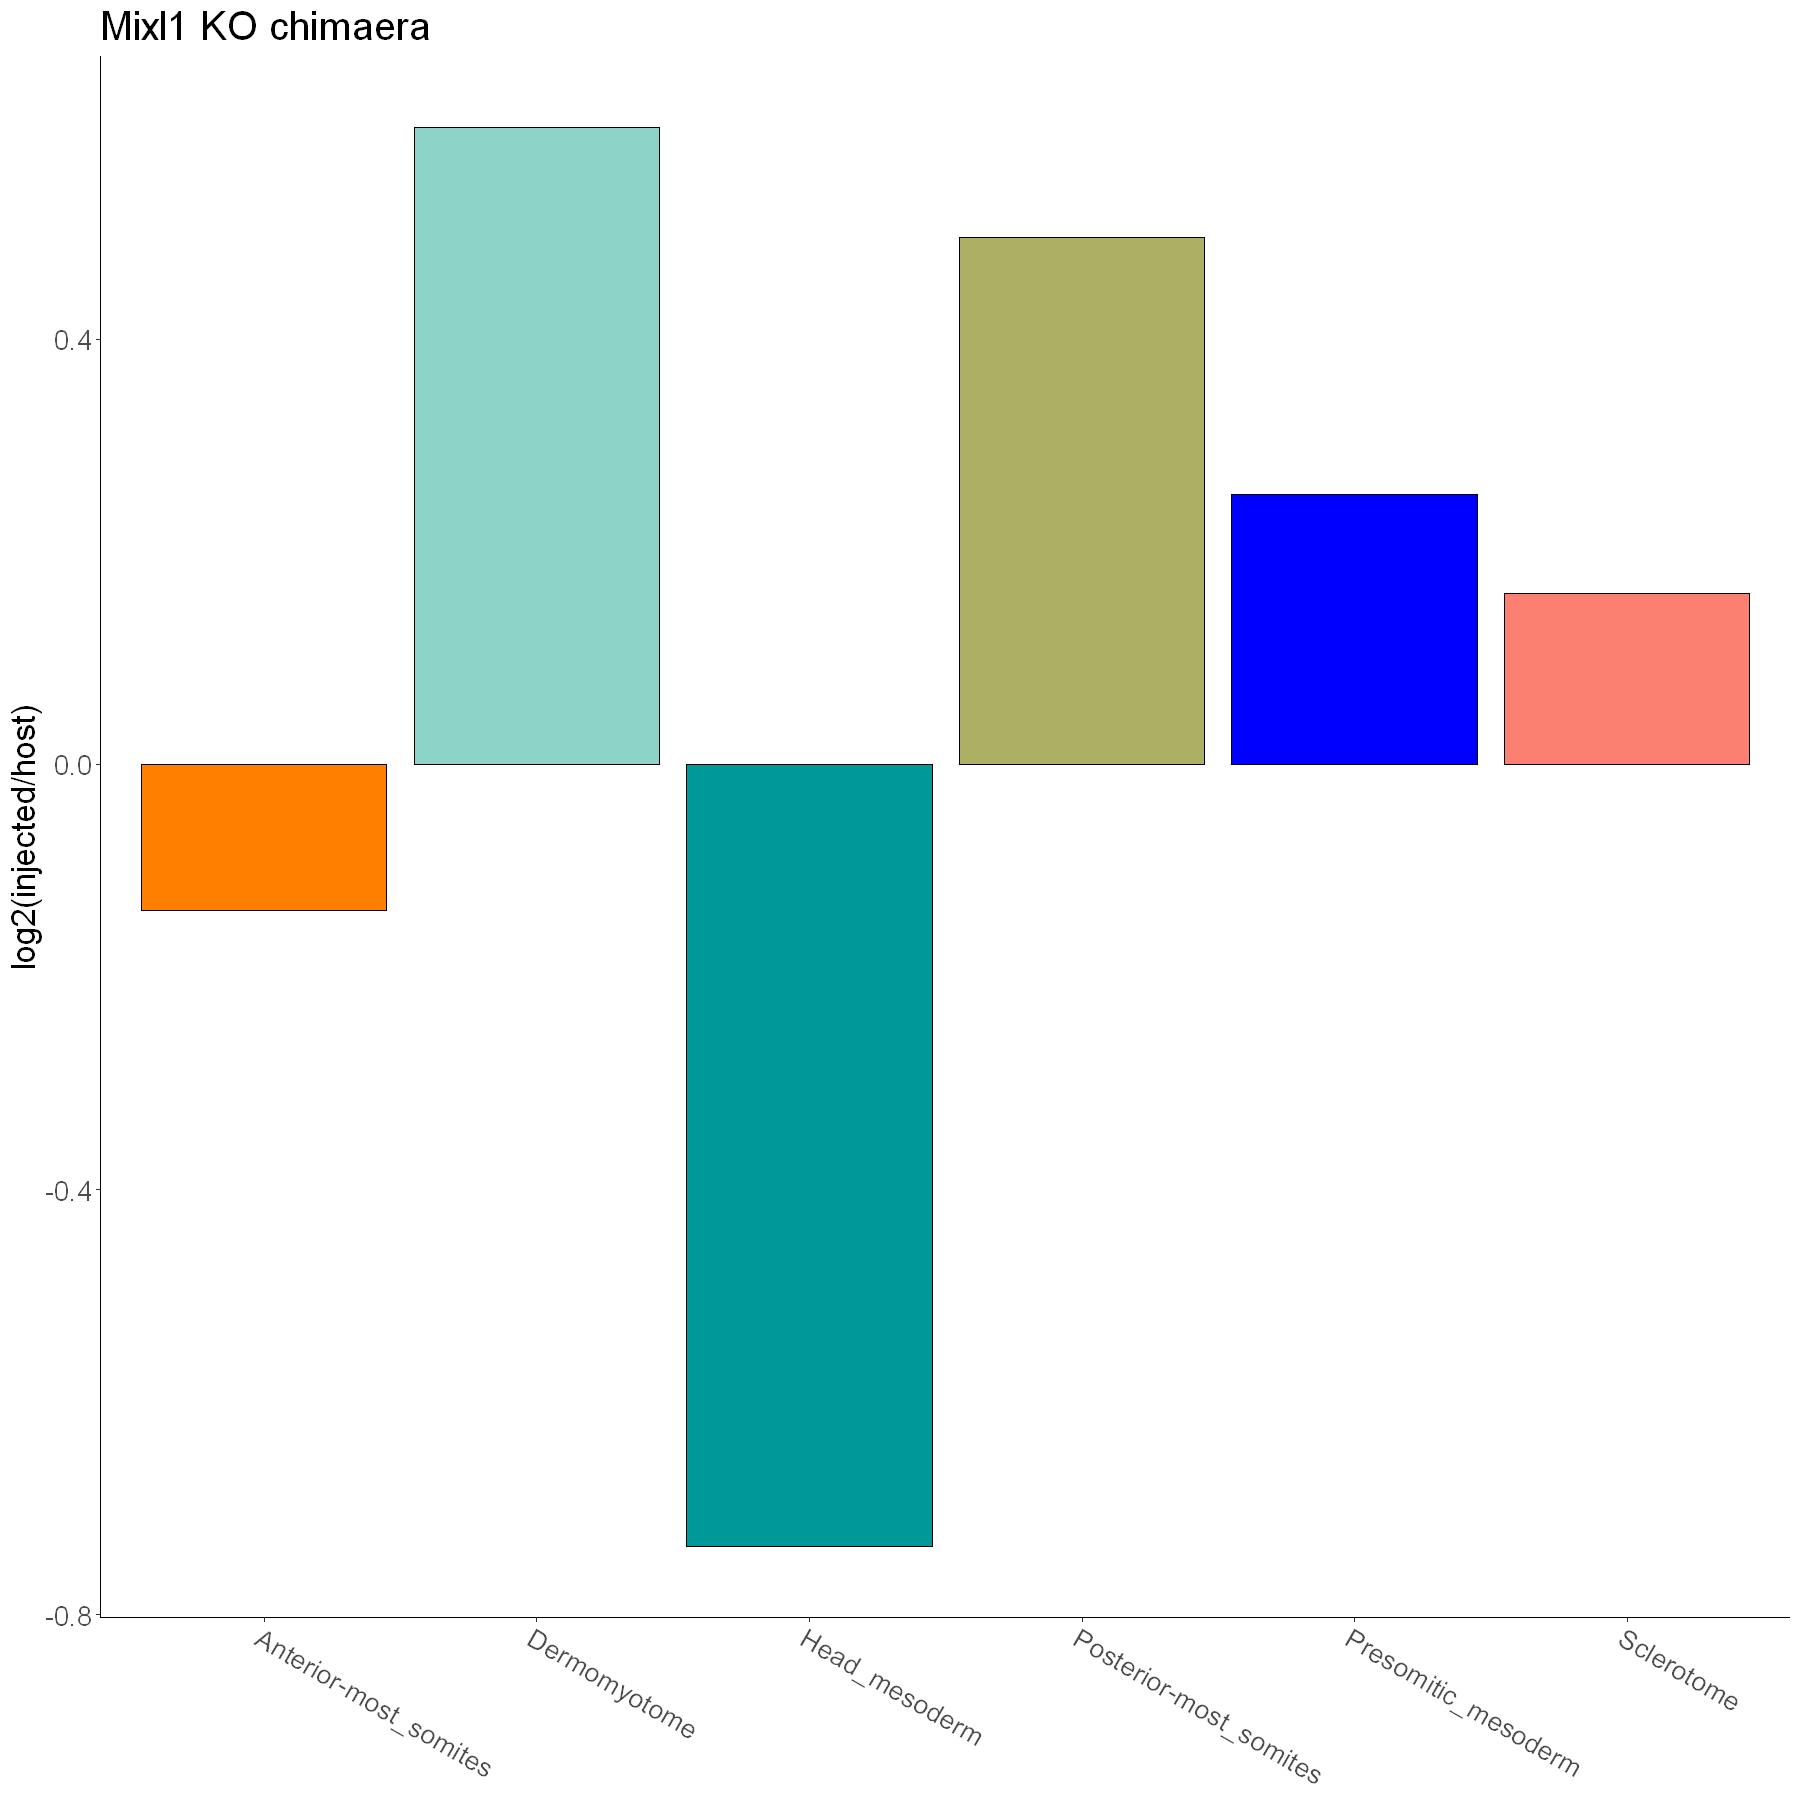

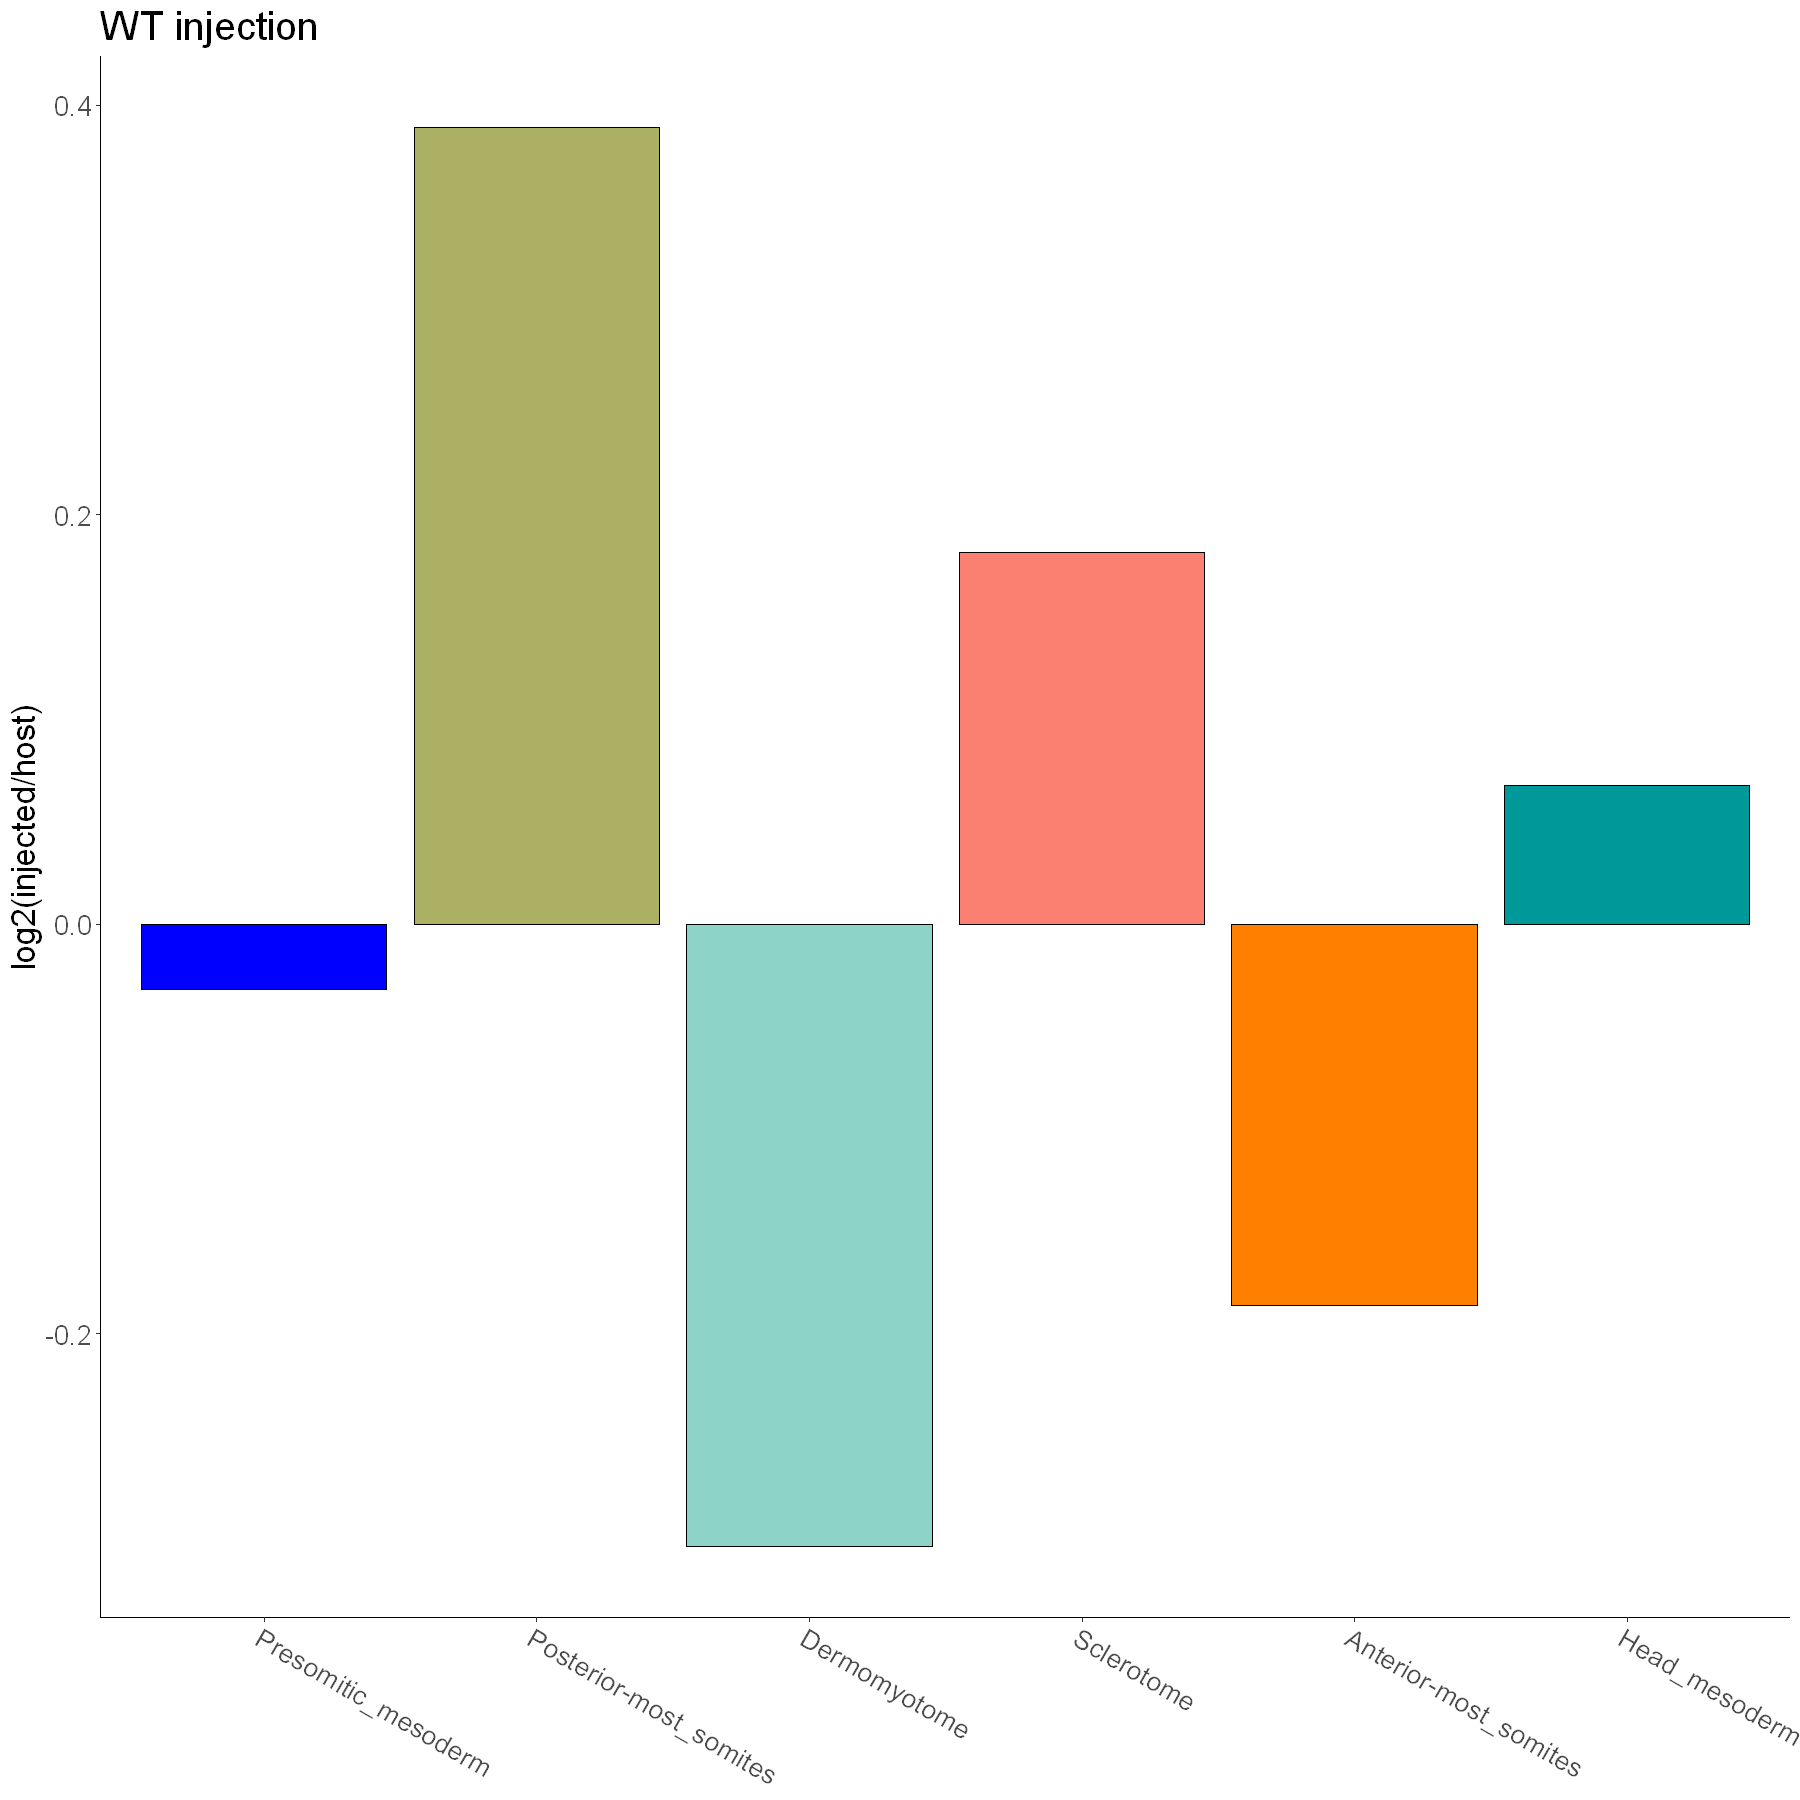

In [265]:
#merged_stripped = merged %>% filter(Var1 != 'Mixed mesoderm')
p1 = ggplot(data = merged, mapping = aes(x = Var1, y = ratio_ko, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = meso_colours, labels = meso_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))])
p1

p2 = ggplot(data = merged, mapping = aes(x = Var1, y = ratio_wt, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = meso_colours, labels = meso_labels, name = "celltype") +
  scale_x_discrete(limits = c("Presomitic_mesoderm", "Posterior-most_somites", "Dermomyotome", "Sclerotome", "Anterior-most_somites", "Head_mesoderm"))
p2

In [266]:
pdf("C:/Users/aamw4/home/aamw4/celltype_ko_wt_meso_ratio.pdf", height=14, width=15)
    grid.arrange(p1, p2, nrow =2)
dev.off()

png 
  2

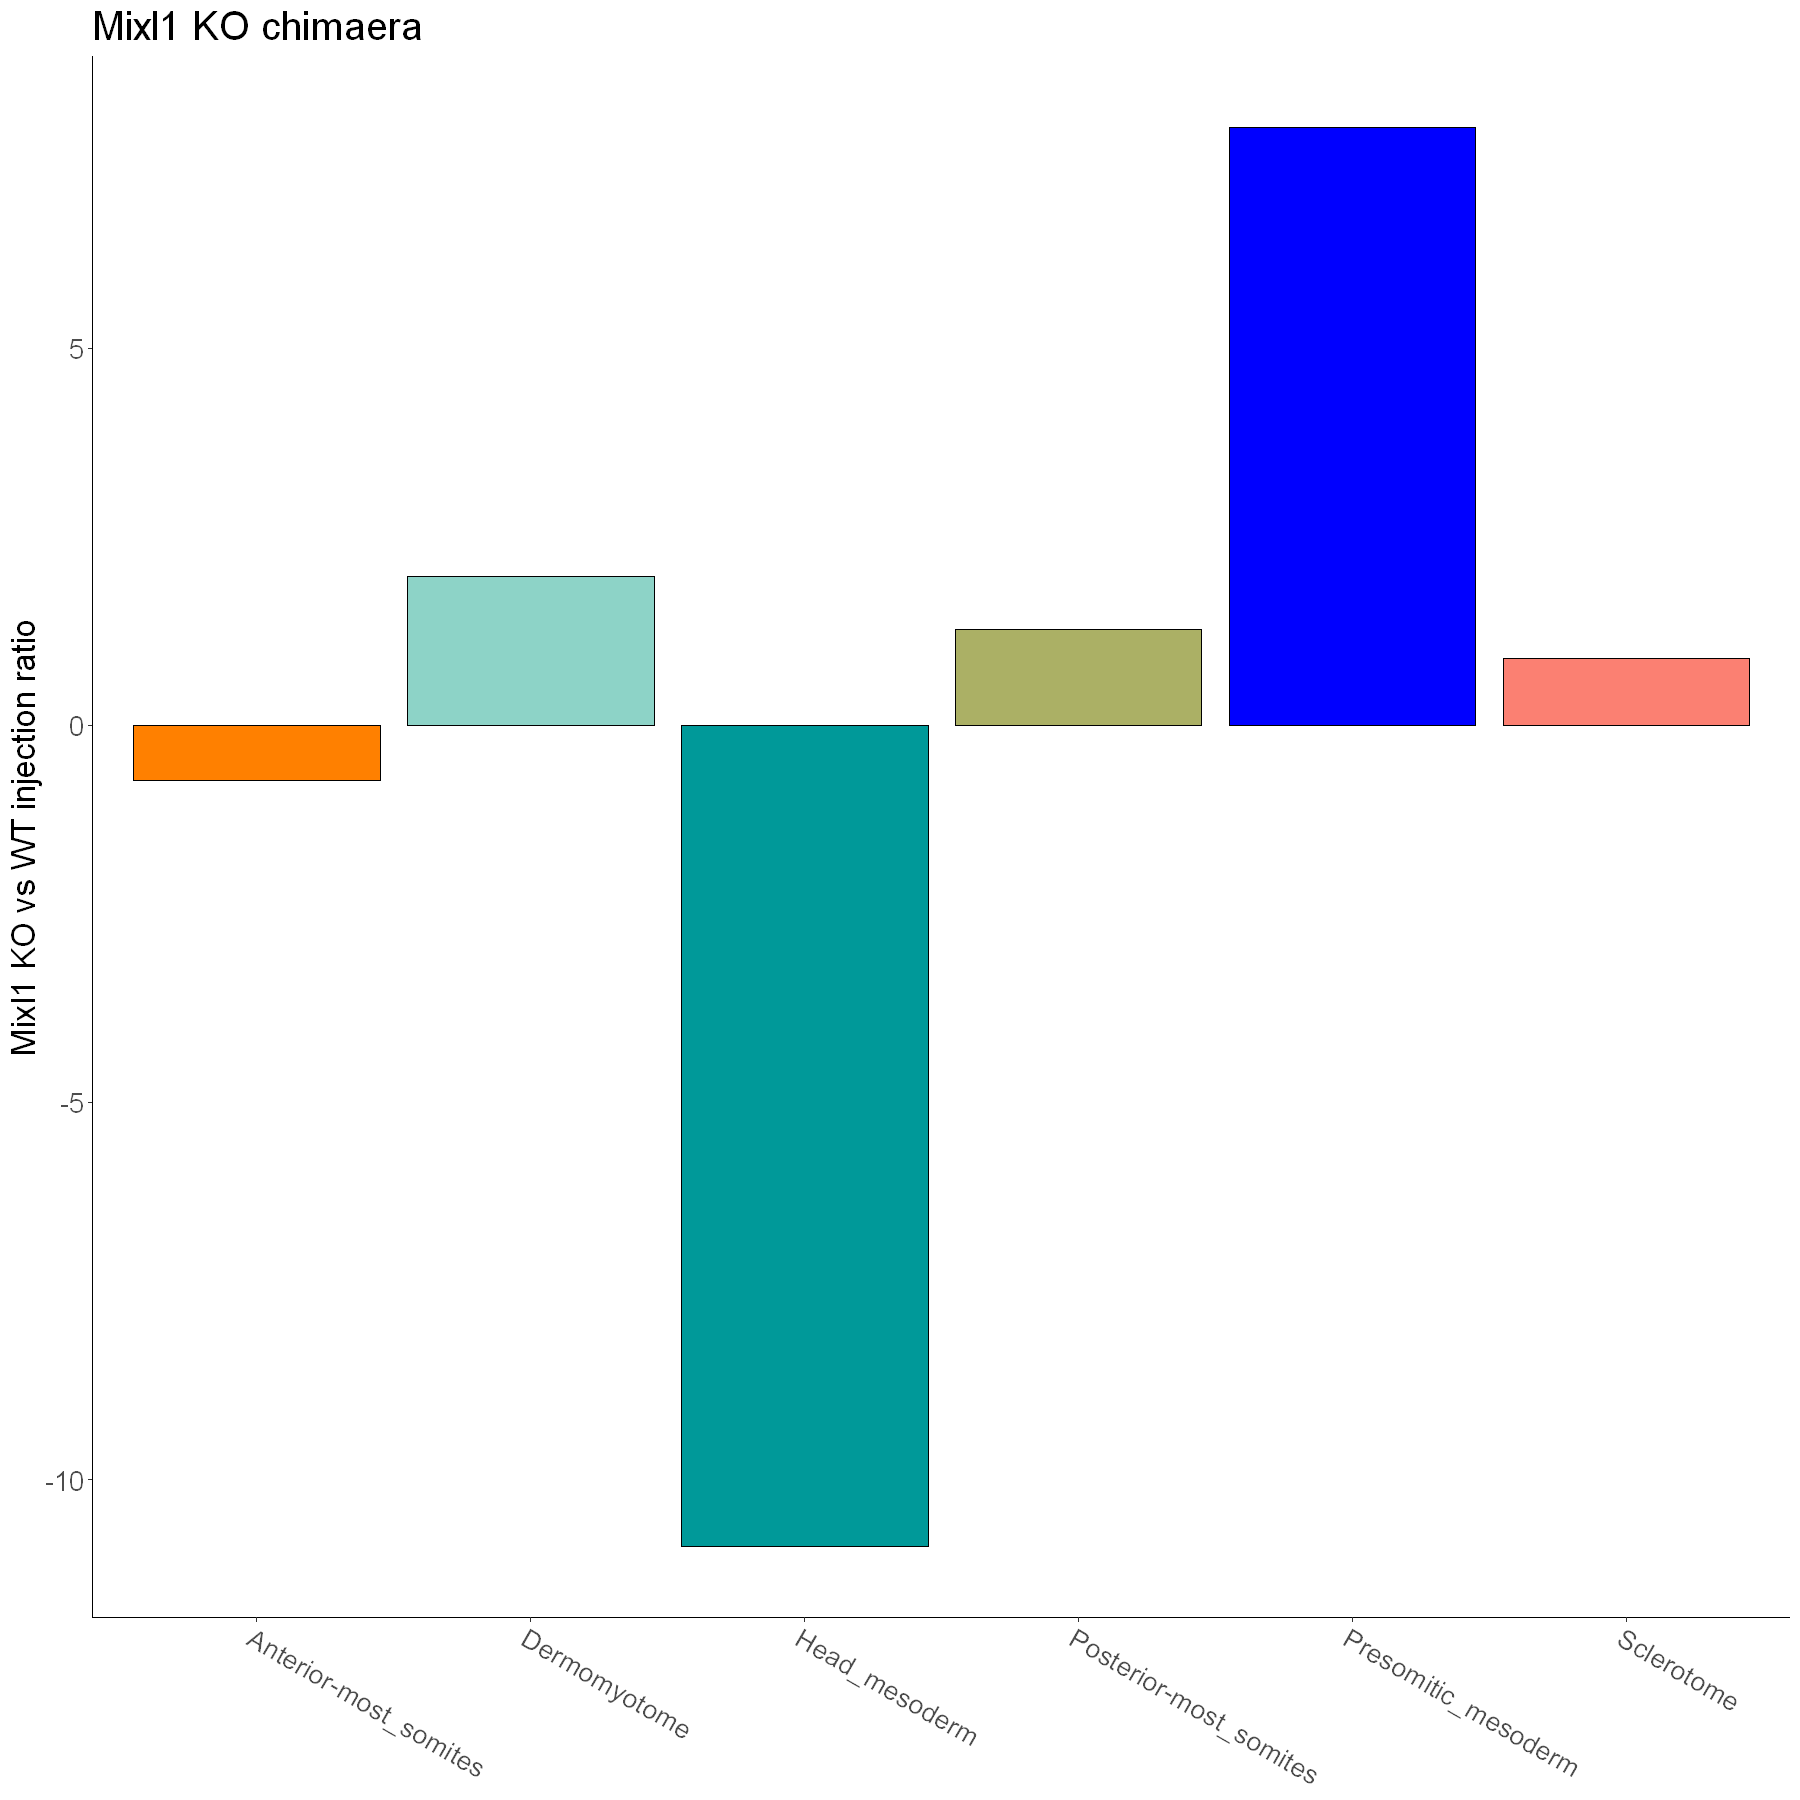

In [267]:
merged_maxed = merged
merged_maxed$ratio = ifelse(merged_maxed$ratio > 20, 20, merged_maxed$ratio)

p = ggplot(data = merged_maxed, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "Mixl1 KO vs WT injection ratio") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = meso_colours, labels = meso_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))])

p

In [161]:
pdf("C:/Users/aamw4/home/aamw4/celltype_injection_meso_ratio.pdf", height=8, width=15)
    p
dev.off()

png 
  2

In [268]:
merged2 = gather(merged, exp, ratio, -Var1, -ratio, -sign)

In [269]:
head(merged2)

,Var1,sign,exp,ratio
,<fct>,<chr>,<chr>,<dbl>
1,Anterior-most_somites,negative,ratio_wt,-0.18620289
2,Dermomyotome,positive,ratio_wt,-0.30396865
3,Head_mesoderm,negative,ratio_wt,0.06756543
4,Posterior-most_somites,positive,ratio_wt,0.38911070
5,Presomitic_mesoderm,positive,ratio_wt,-0.03206038
6,Sclerotome,positive,ratio_wt,0.18149640


In [270]:
unique(meta$meso.mapped)

[1] NA                       "Presomitic_mesoderm"    "Head_mesoderm"         
[4] "Posterior-most_somites" "Dermomyotome"           "Anterior-most_somites" 
[7] "Sclerotome"

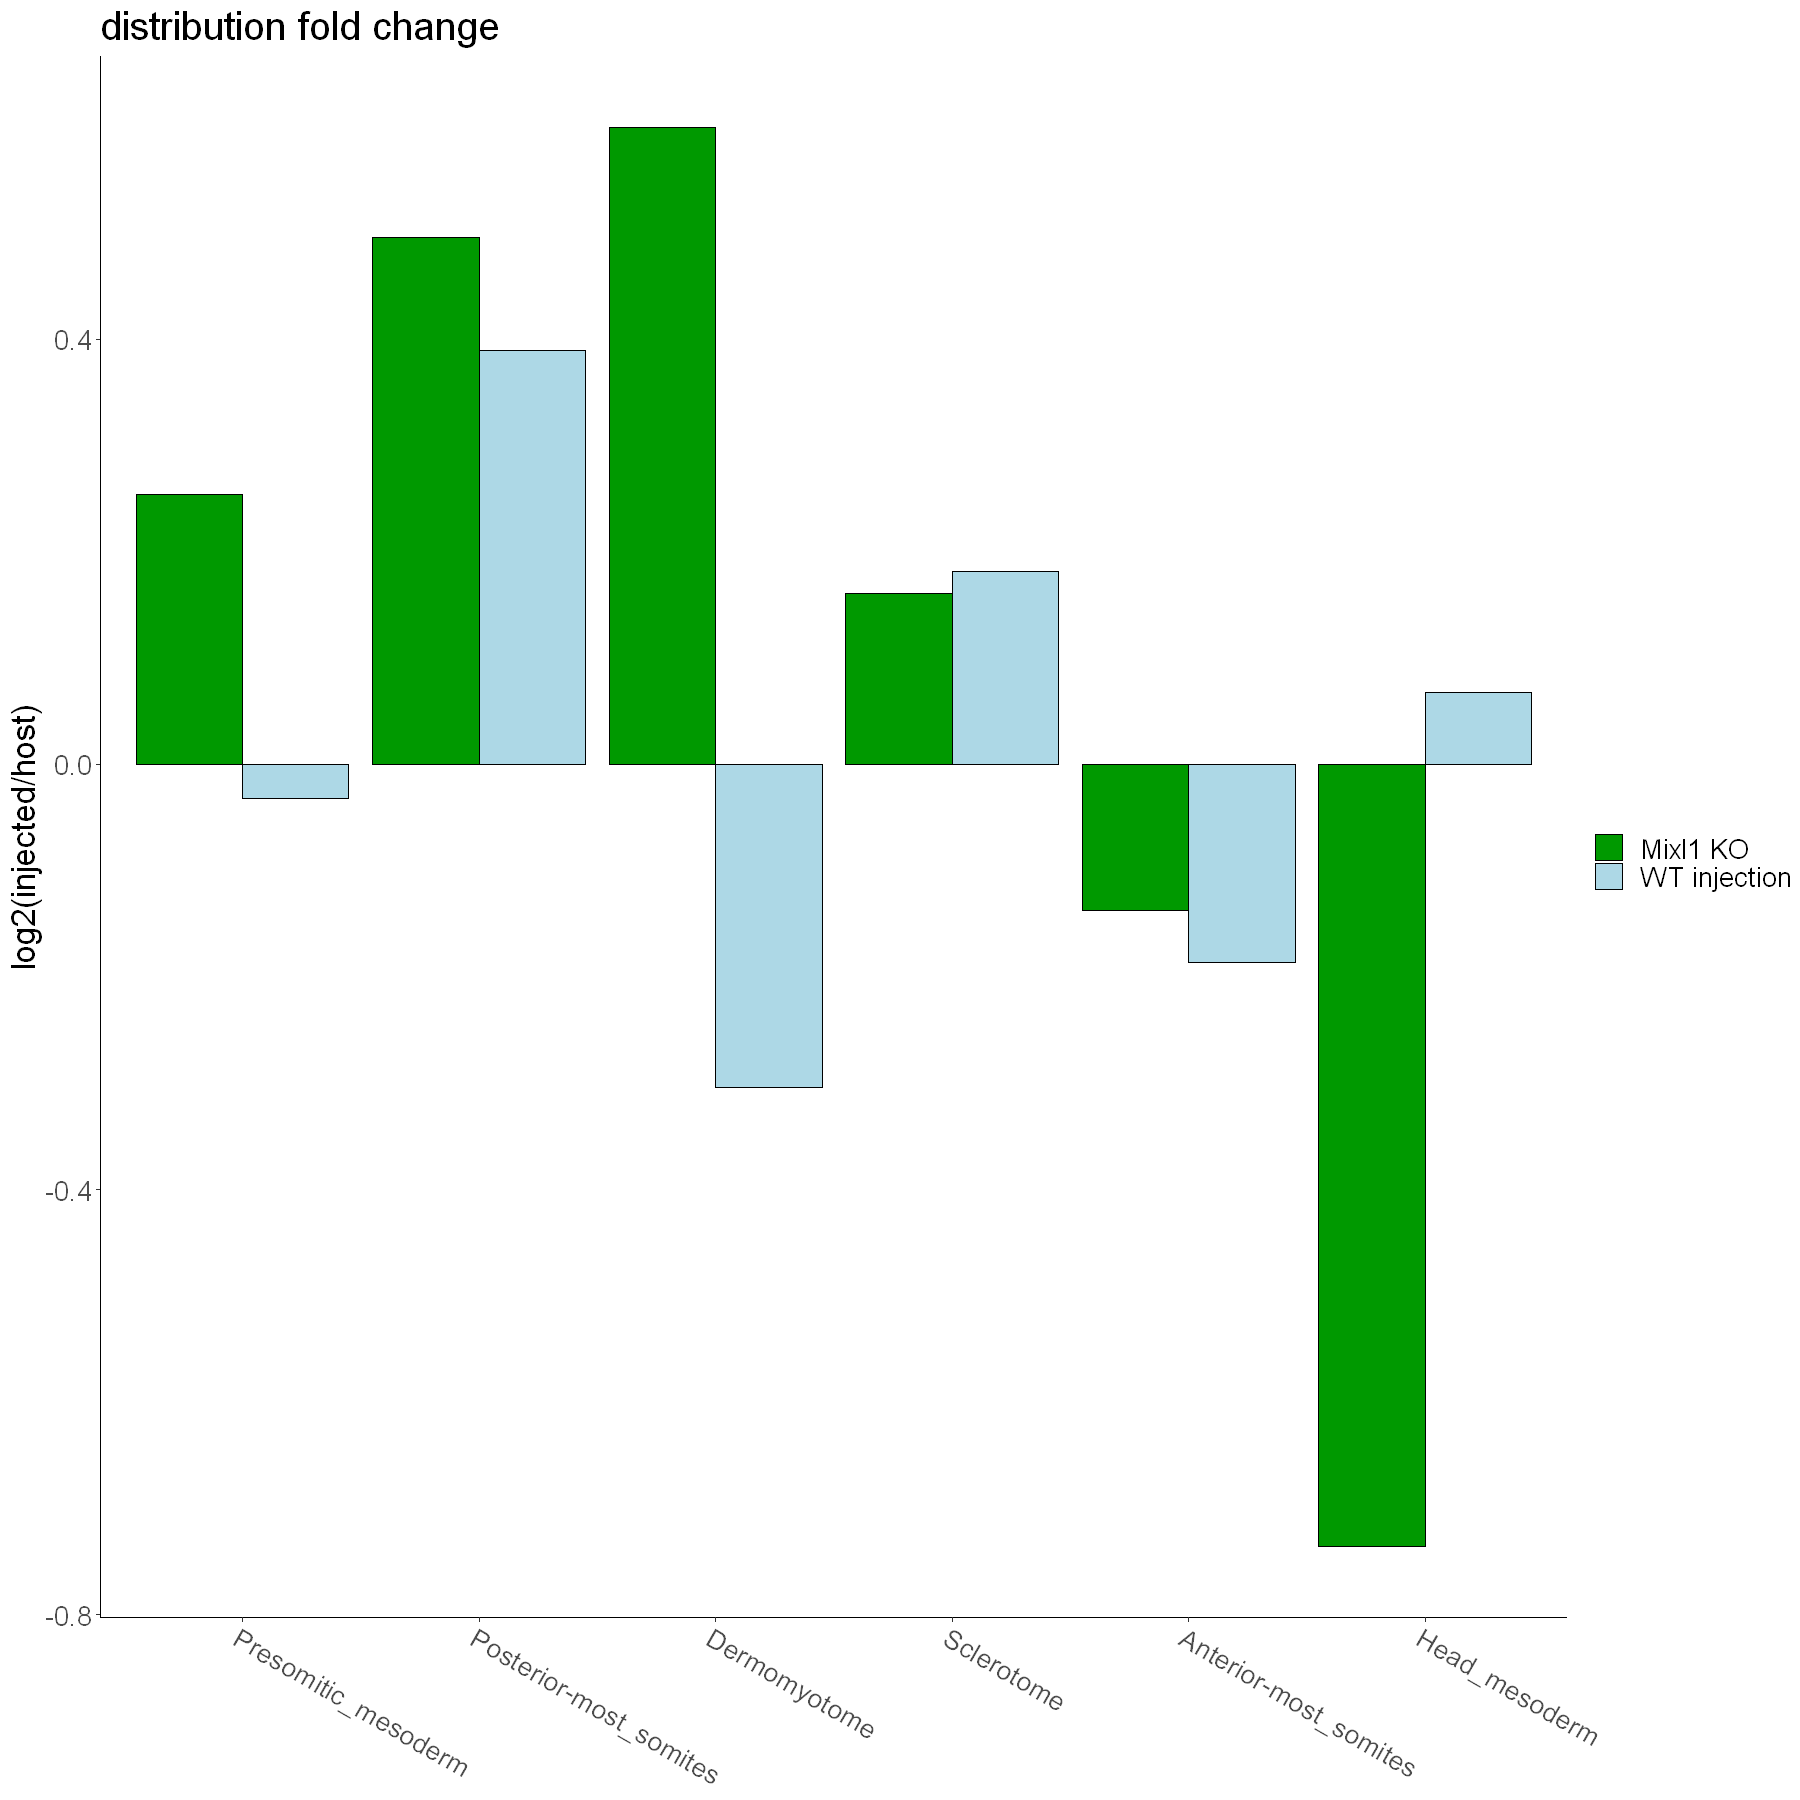

In [271]:
#merged_stripped = merged %>% filter(Var1 != 'Mixed mesoderm')
p = ggplot(data = merged2, mapping = aes(x = Var1, y = ratio, fill=exp)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("distribution fold change") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  scale_fill_manual(values = c("ratio_ko" = "#009900", "ratio_wt" = "#add8e6"), 
                    labels = c("ratio_ko" = "Mixl1 KO", "ratio_wt" = "WT injection"),
                    name = "") +
  scale_x_discrete(limits = c("Presomitic_mesoderm", "Posterior-most_somites", "Dermomyotome", "Sclerotome", "Anterior-most_somites", "Head_mesoderm"))
p

In [272]:
pdf("C:/Users/aamw4/home/aamw4/celltype_ko_wt_ratio_meso_side.pdf", height=8, width=15)
    p
dev.off()

png 
  2

In [447]:
# exclude low cell nr
own_meta$count = 1
counts = own_meta %>% group_by(meso.mapped) %>% summarize(count = sum(count))
# exclude ExE
exe = c('ExE ectoderm', 'ExE endoderm', 'Visceral endoderm', 'Parietal endoderm')
exclude = counts %>% filter(count < 40 | celltype.mapped %in% exe) %>% .$celltype.mapped


`summarise()` ungrouping output (override with `.groups` argument)



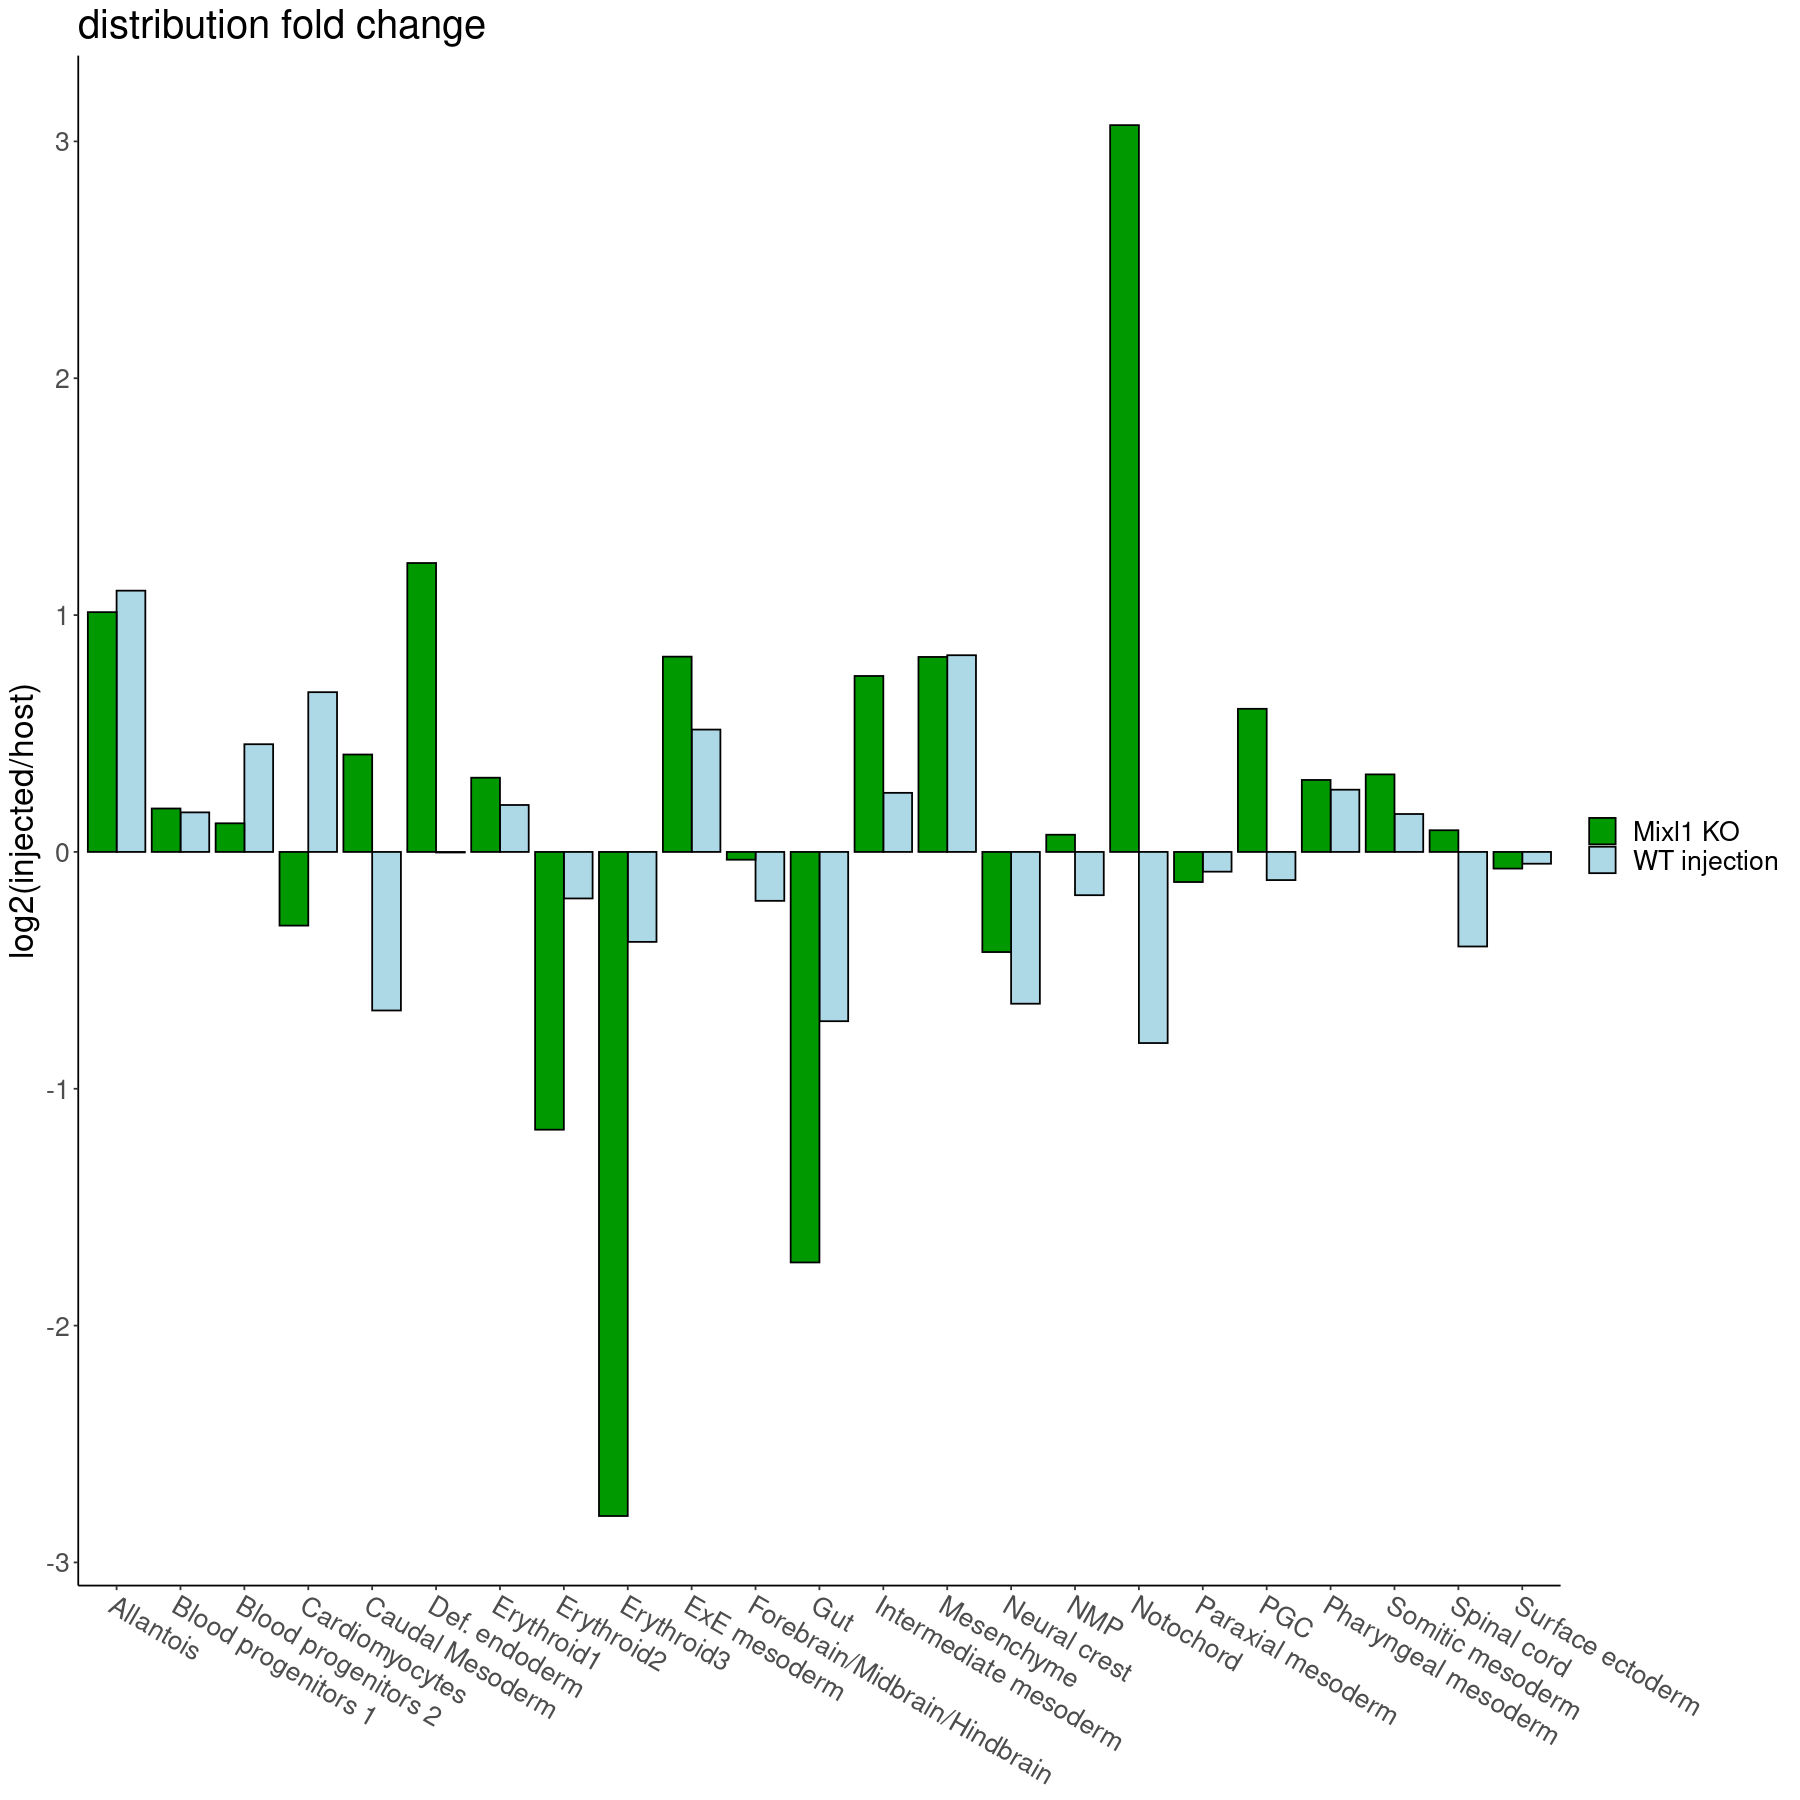

In [450]:
merged_stripped = merged2 %>% filter(!Var1 %in% exclude)
p = ggplot(data = merged_stripped, mapping = aes(x = Var1, y = ratio, fill=exp)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("distribution fold change") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  scale_fill_manual(values = c("ratio_ko" = "#009900", "ratio_wt" = "#add8e6"), 
                    labels = c("ratio_ko" = "Mixl1 KO", "ratio_wt" = "WT injection"),
                    name = "") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])
p

In [451]:
pdf(paste0(plot_folder, "celltype_ko_wt_ratio_side_no_exe.pdf"), height=8, width=15)
    p
dev.off()

png 
  2

In [ ]:
#haem

In [205]:
haem_wt = meta %>% filter(!is.na(meta$haem_subclust.mapped))

In [219]:
meso_wt = meta %>% filter(!is.na(meta$meso.mapped))

In [220]:
meso_wt #only 141 cells instead of 235??

X.1,X,barcode,batch,cell,celltype,celltype.mapped,closest.cell,cluster,cluster.stage,...,tdTom,theiler,umapX,umapY,origin,haem_subclust.mapped,celltype_origin,meso_subcluster,meso.mapped,gut_subclust.mapped
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,...,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
126326,wt_cell_10014-1,AACTCCCAGTATTGGA,1,wt_cell_10014,Somitic mesoderm,Somitic mesoderm,atlas_cell_98468,NA,NA,...,pos,nan,NA,NA,wt,NA,NA,NA,Presomitic_mesoderm,NA
126342,wt_cell_10030-1,AAGACCTAGCAAATCA,1,wt_cell_10030,Somitic mesoderm,Somitic mesoderm,atlas_cell_130759,NA,NA,...,pos,nan,NA,NA,wt,NA,NA,NA,Presomitic_mesoderm,NA
126389,wt_cell_10077-1,ACACCGGTCGGAAACG,1,wt_cell_10077,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_137735,NA,NA,...,pos,nan,NA,NA,wt,NA,NA,NA,Head_mesoderm,NA
126391,wt_cell_10079-1,ACACTGAAGGTACTCT,1,wt_cell_10079,Somitic mesoderm,Somitic mesoderm,atlas_cell_139074,NA,NA,...,pos,nan,NA,NA,wt,NA,NA,NA,Posterior-most_somites,NA
126410,wt_cell_10098-1,ACATACGAGGCTCATT,1,wt_cell_10098,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_37158,NA,NA,...,pos,nan,NA,NA,wt,NA,NA,NA,Dermomyotome,NA
126440,wt_cell_10128-1,ACGAGGAAGATATGGT,1,wt_cell_10128,Somitic mesoderm,Somitic mesoderm,atlas_cell_99073,NA,NA,...,pos,nan,NA,NA,wt,NA,NA,NA,Presomitic_mesoderm,NA
126455,wt_cell_10143-1,ACGATACCAGGTGGAT,1,wt_cell_10143,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_97214,NA,NA,...,pos,nan,NA,NA,wt,NA,NA,NA,Head_mesoderm,NA
126491,wt_cell_10179-1,ACGGGCTGTCGAAAGC,1,wt_cell_10179,Somitic mesoderm,Somitic mesoderm,atlas_cell_38563,NA,NA,...,pos,nan,NA,NA,wt,NA,NA,NA,Presomitic_mesoderm,NA
126539,wt_cell_10227-1,ACTTACTAGGATATAC,1,wt_cell_10227,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_39613,NA,NA,...,pos,nan,NA,NA,wt,NA,NA,NA,Head_mesoderm,NA


In [206]:
haem_wt #only 820 cells, and not 1963 like what I initially found when remapping?

X.1,X,barcode,batch,cell,celltype,celltype.mapped,closest.cell,cluster,cluster.stage,...,tdTom,theiler,umapX,umapY,origin,haem_subclust.mapped,celltype_origin,meso_subcluster,meso.mapped,gut_subclust.mapped
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,...,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
126264,wt_cell_9952-1,AAACCTGAGATGCCTT,1,wt_cell_9952,Endothelium,Endothelium,atlas_cell_96660,NA,NA,...,pos,nan,NA,NA,wt,EC7,NA,NA,NA,NA
126266,wt_cell_9954-1,AAACCTGCATACTCTT,1,wt_cell_9954,Erythroid3,Erythroid3,atlas_cell_135387,NA,NA,...,pos,nan,NA,NA,wt,Ery4,NA,NA,NA,NA
126267,wt_cell_9955-1,AAACGGGTCAACACCA,1,wt_cell_9955,Erythroid1,Erythroid1,atlas_cell_129986,NA,NA,...,pos,nan,NA,NA,wt,Ery1,NA,NA,NA,NA
126268,wt_cell_9956-1,AAACGGGTCACTCTTA,1,wt_cell_9956,Endothelium,Endothelium,atlas_cell_39198,NA,NA,...,pos,nan,NA,NA,wt,EC7,NA,NA,NA,NA
126280,wt_cell_9968-1,AAAGCAAGTGAACCTT,1,wt_cell_9968,Erythroid1,Erythroid1,atlas_cell_35595,NA,NA,...,pos,nan,NA,NA,wt,Ery2,NA,NA,NA,NA
126294,wt_cell_9982-1,AAATGCCGTCAGCTAT,1,wt_cell_9982,Erythroid2,Erythroid2,atlas_cell_69508,NA,NA,...,pos,nan,NA,NA,wt,Ery2,NA,NA,NA,NA
126298,wt_cell_9986-1,AAATGCCTCACGGTTA,1,wt_cell_9986,Erythroid3,Erythroid3,atlas_cell_73231,NA,NA,...,pos,nan,NA,NA,wt,Ery2,NA,NA,NA,NA
126299,wt_cell_9987-1,AAATGCCTCAGTTCGA,1,wt_cell_9987,Erythroid3,Erythroid3,atlas_cell_69097,NA,NA,...,pos,nan,NA,NA,wt,Ery4,NA,NA,NA,NA
126304,wt_cell_9992-1,AACCATGAGCACACAG,1,wt_cell_9992,Haematoendothelial progenitors,Haematoendothelial progenitors,atlas_cell_69721,NA,NA,...,pos,nan,NA,NA,wt,EC1,NA,NA,NA,NA


In [234]:
chim_meta$tdTom = NULL
chim_meta$tdTom[chim_meta$sample %in% c('mixl_1', 'mixl_3', 'mixl_5')] <- "neg"
chim_meta$tdTom[chim_meta$sample %in% c('mixl_2', 'mixl_4', 'mixl_6')] <- "pos"

chim_meta <- chim_meta %>% filter(!is.na(chim_meta$tdTom))

png 
  2

,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
1,BP1,neg,0.000010000
2,BP2,neg,0.022398060
3,BP3,neg,0.011204030
4,BP4,neg,0.000010000
5,EC1,neg,0.007472687
6,EC2,neg,0.037323433


,Var1,ratio_wt,ratio_ko,ratio,sign
,<fct>,<dbl>,<dbl>,<dbl>,<chr>
1,BP1,6.9920565,4.0730651,0.5825275,positive
2,BP2,0.5300182,1.0854713,2.0479889,positive
3,BP3,-1.1261629,1.0496234,0.9320352,positive
4,BP4,5.8952808,0.8729626,0.1480782,positive
5,EC8,-0.1628268,4.0730651,25.0147106,positive
6,Ery1,0.4144640,1.5263437,3.6826930,positive


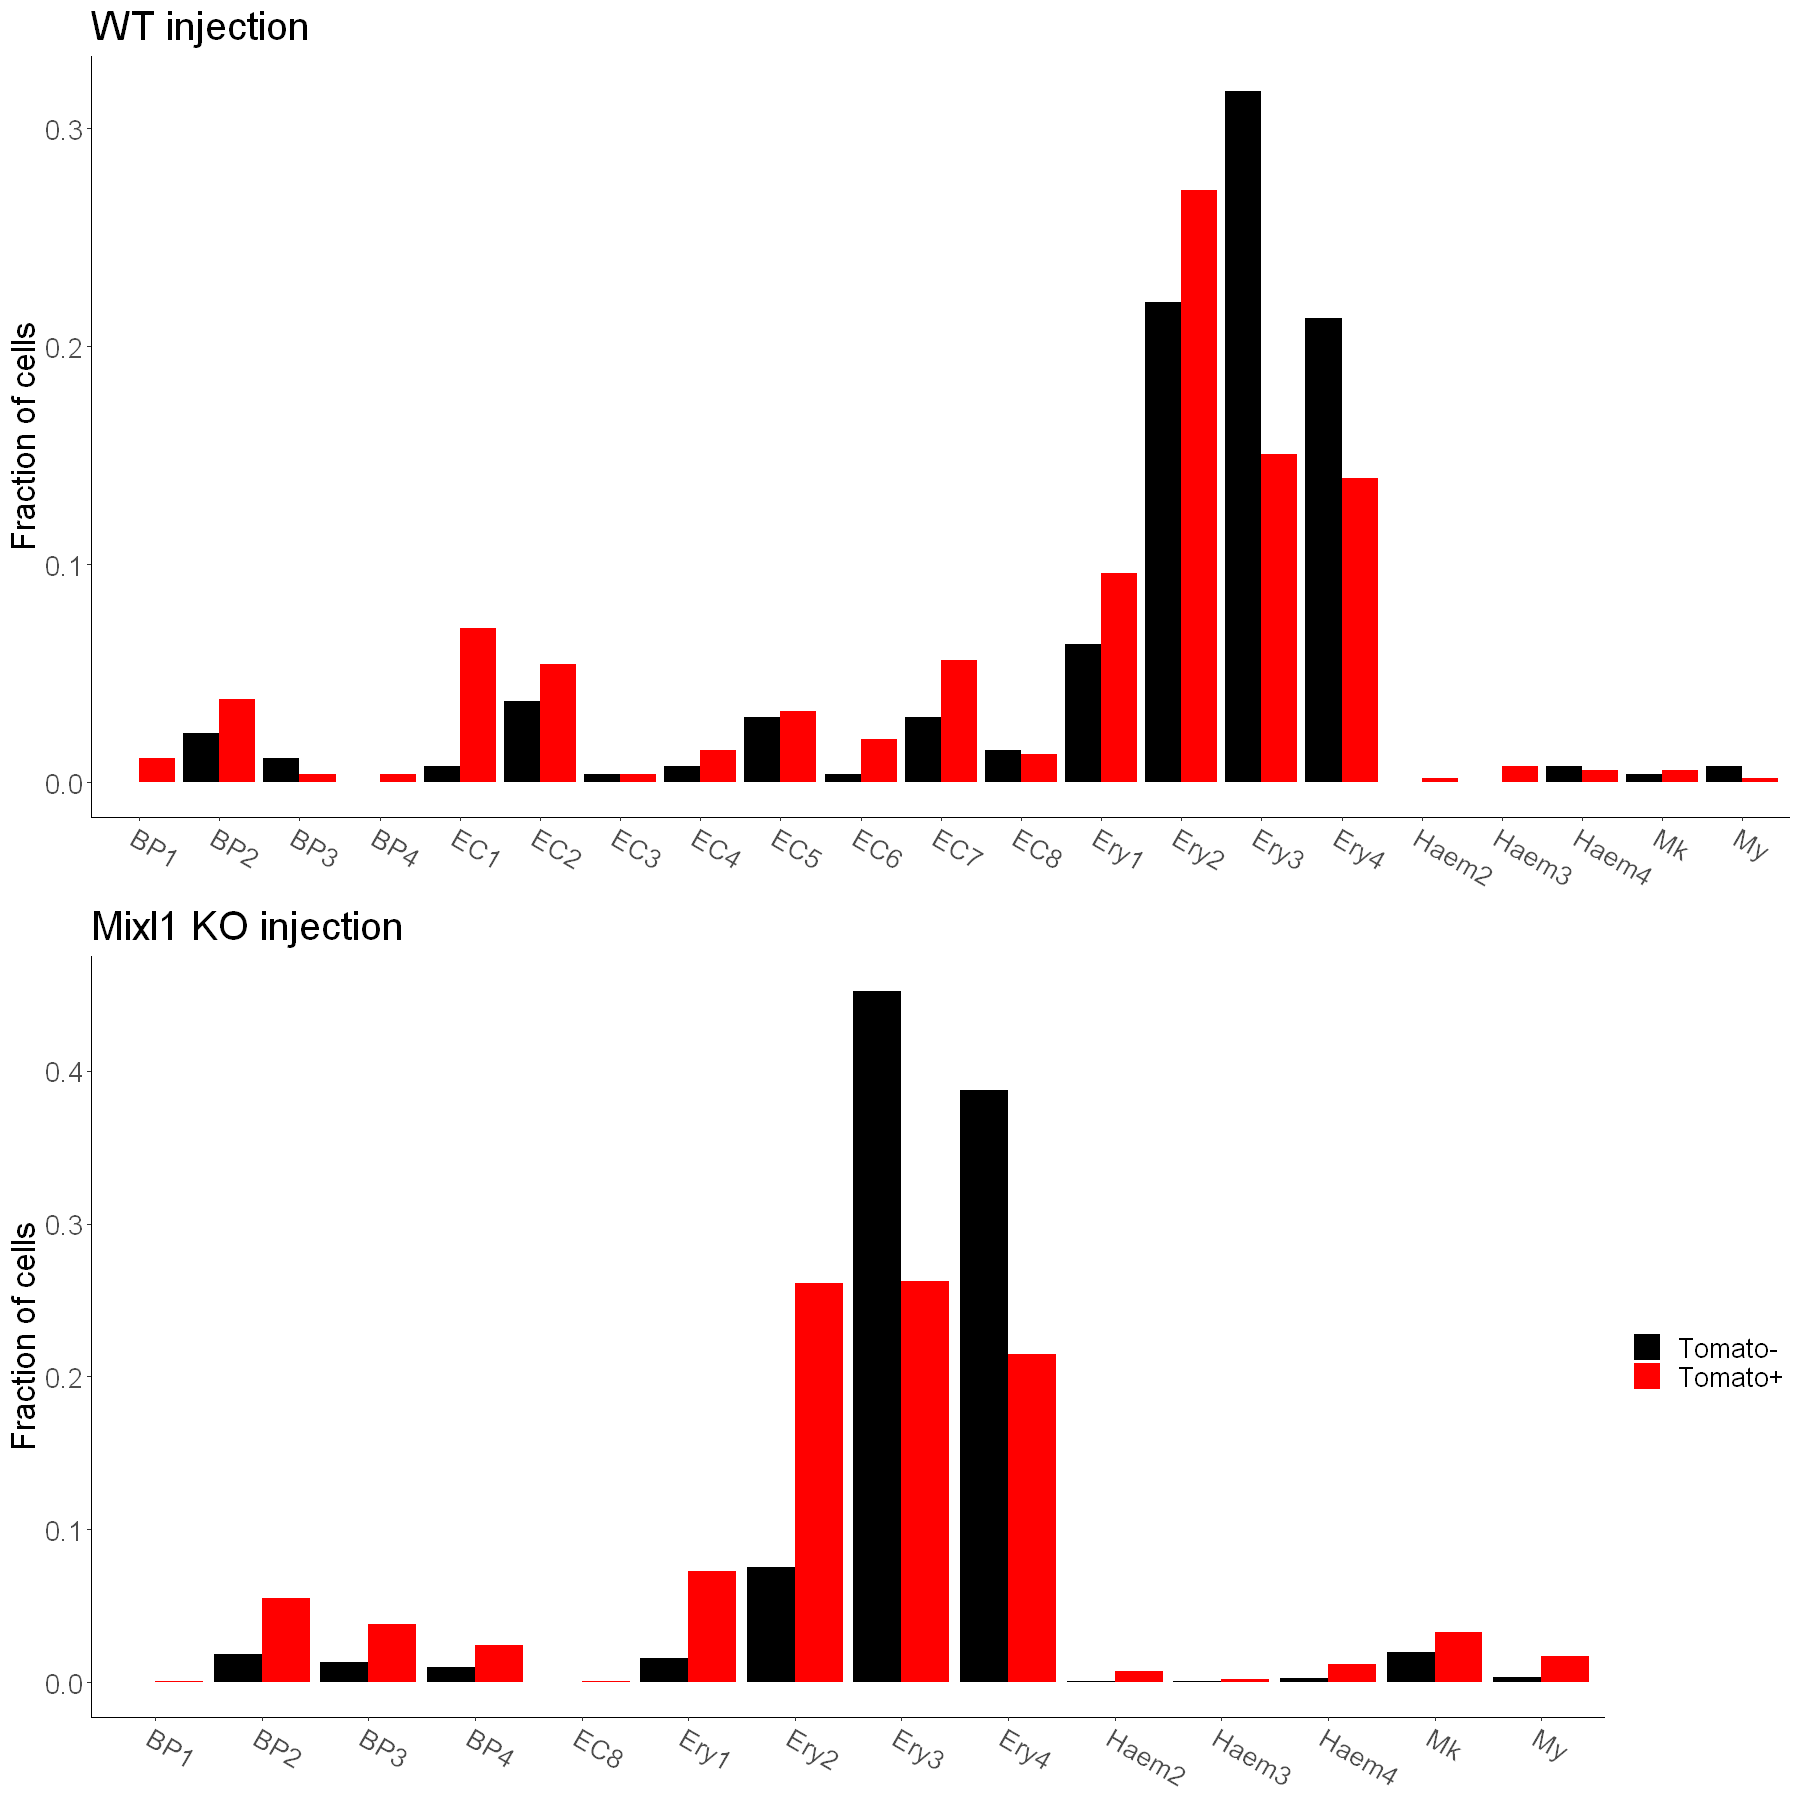

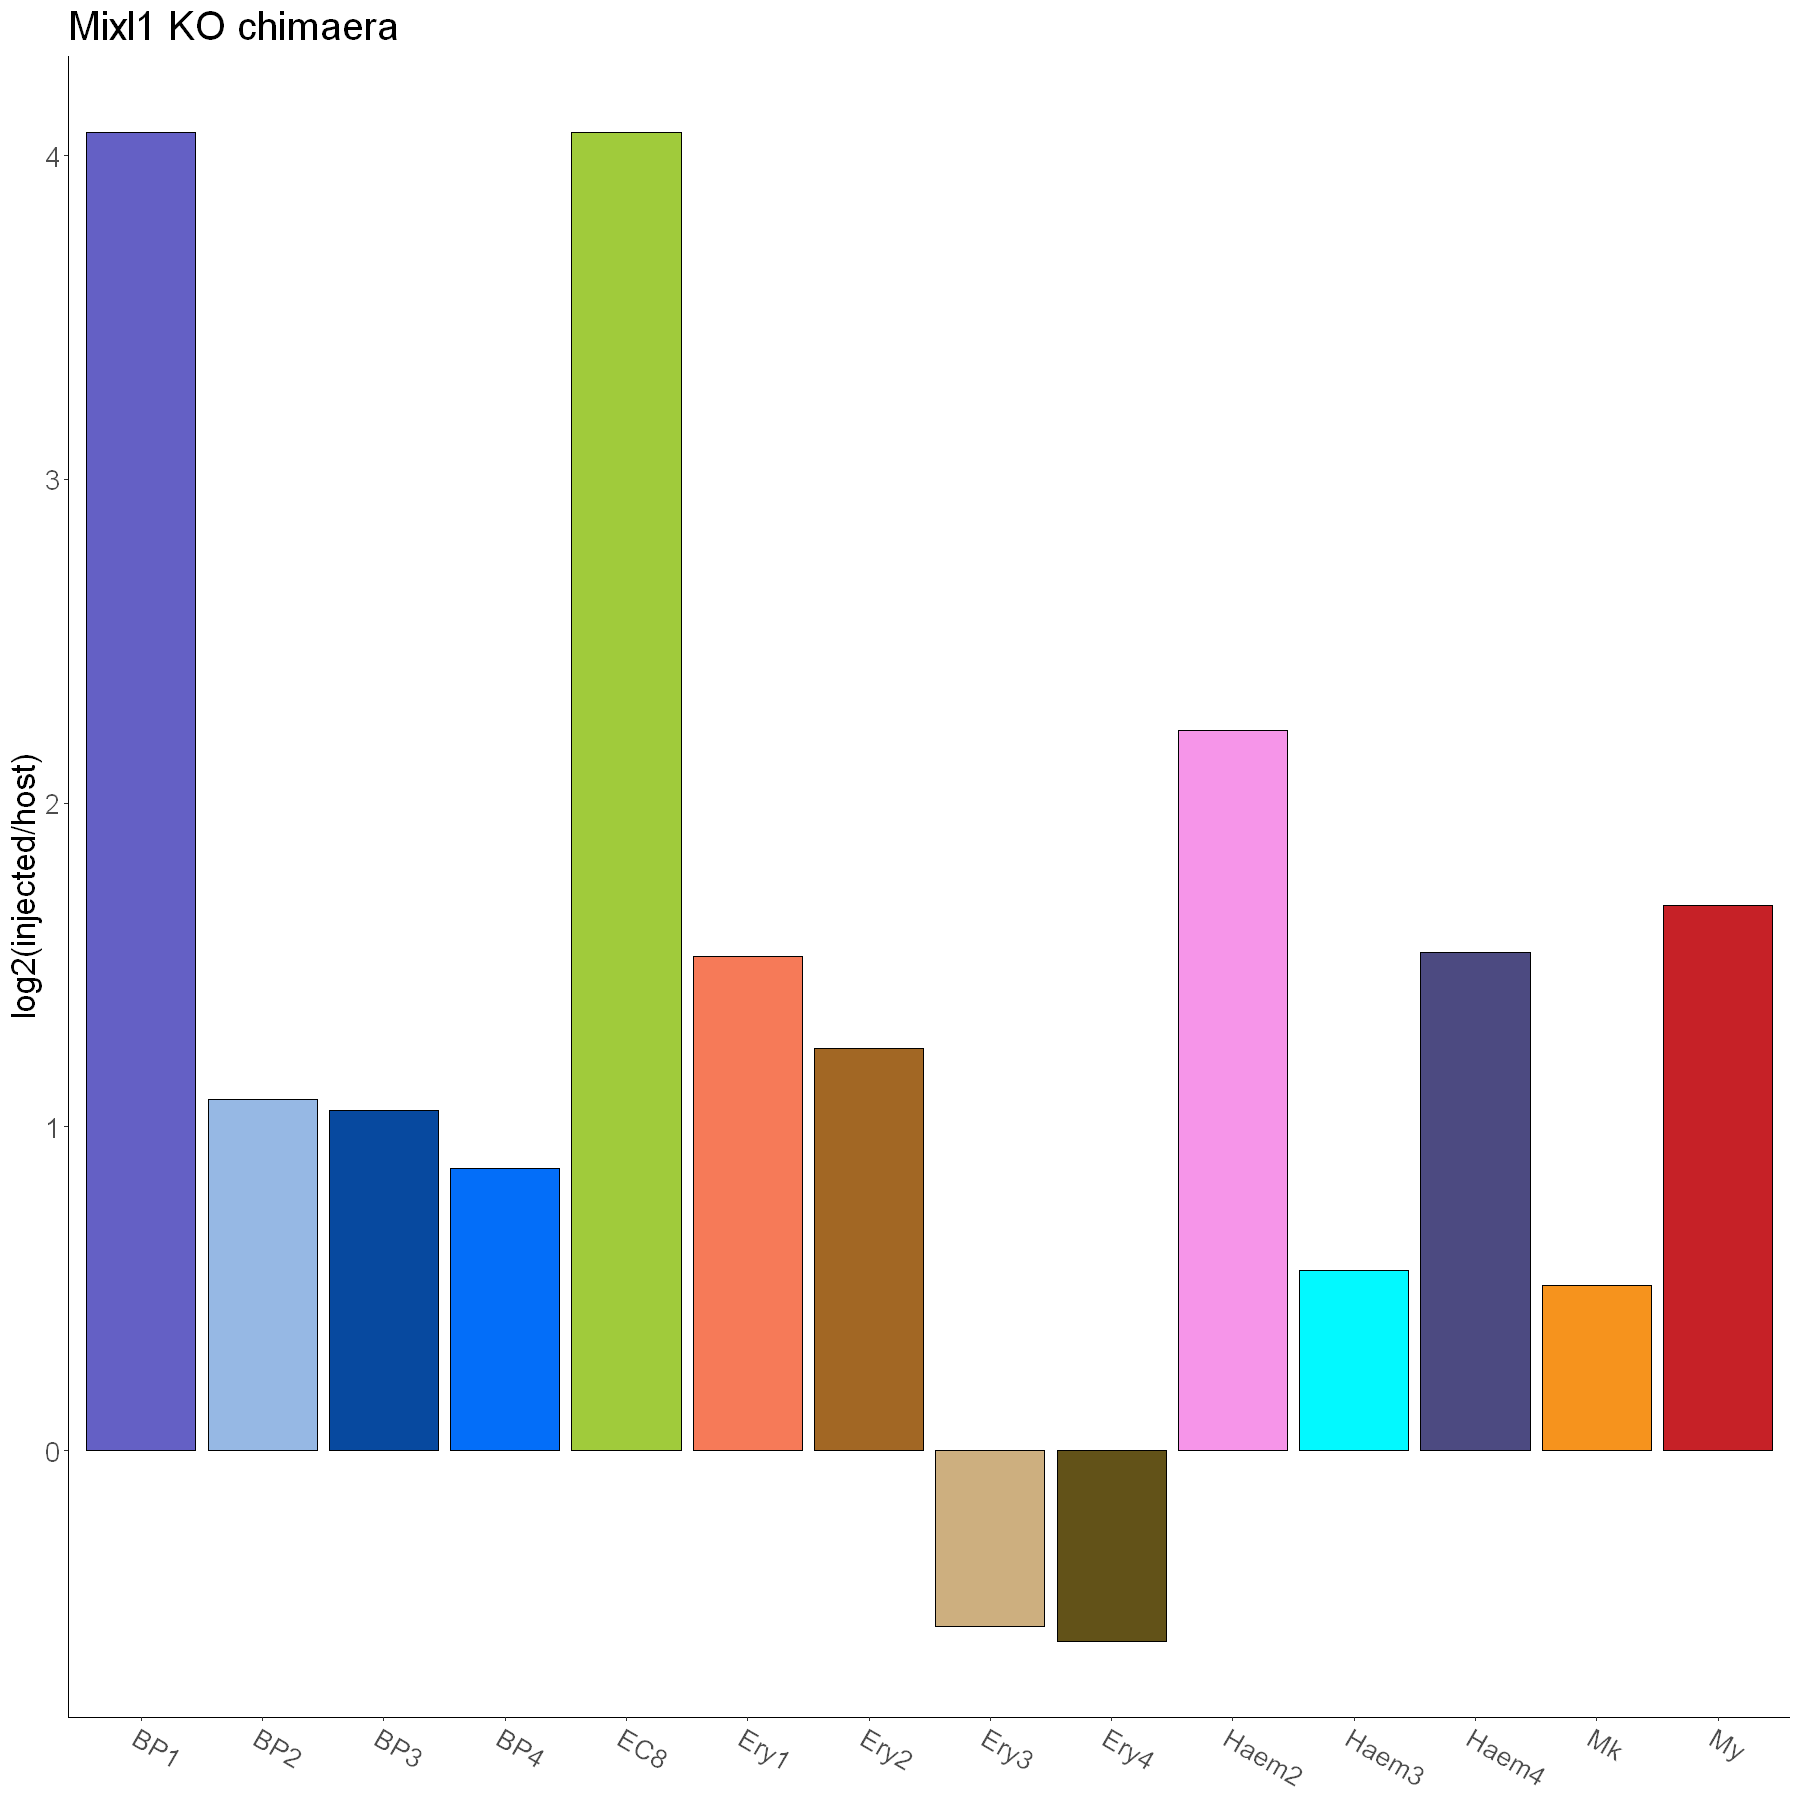

png 
  2

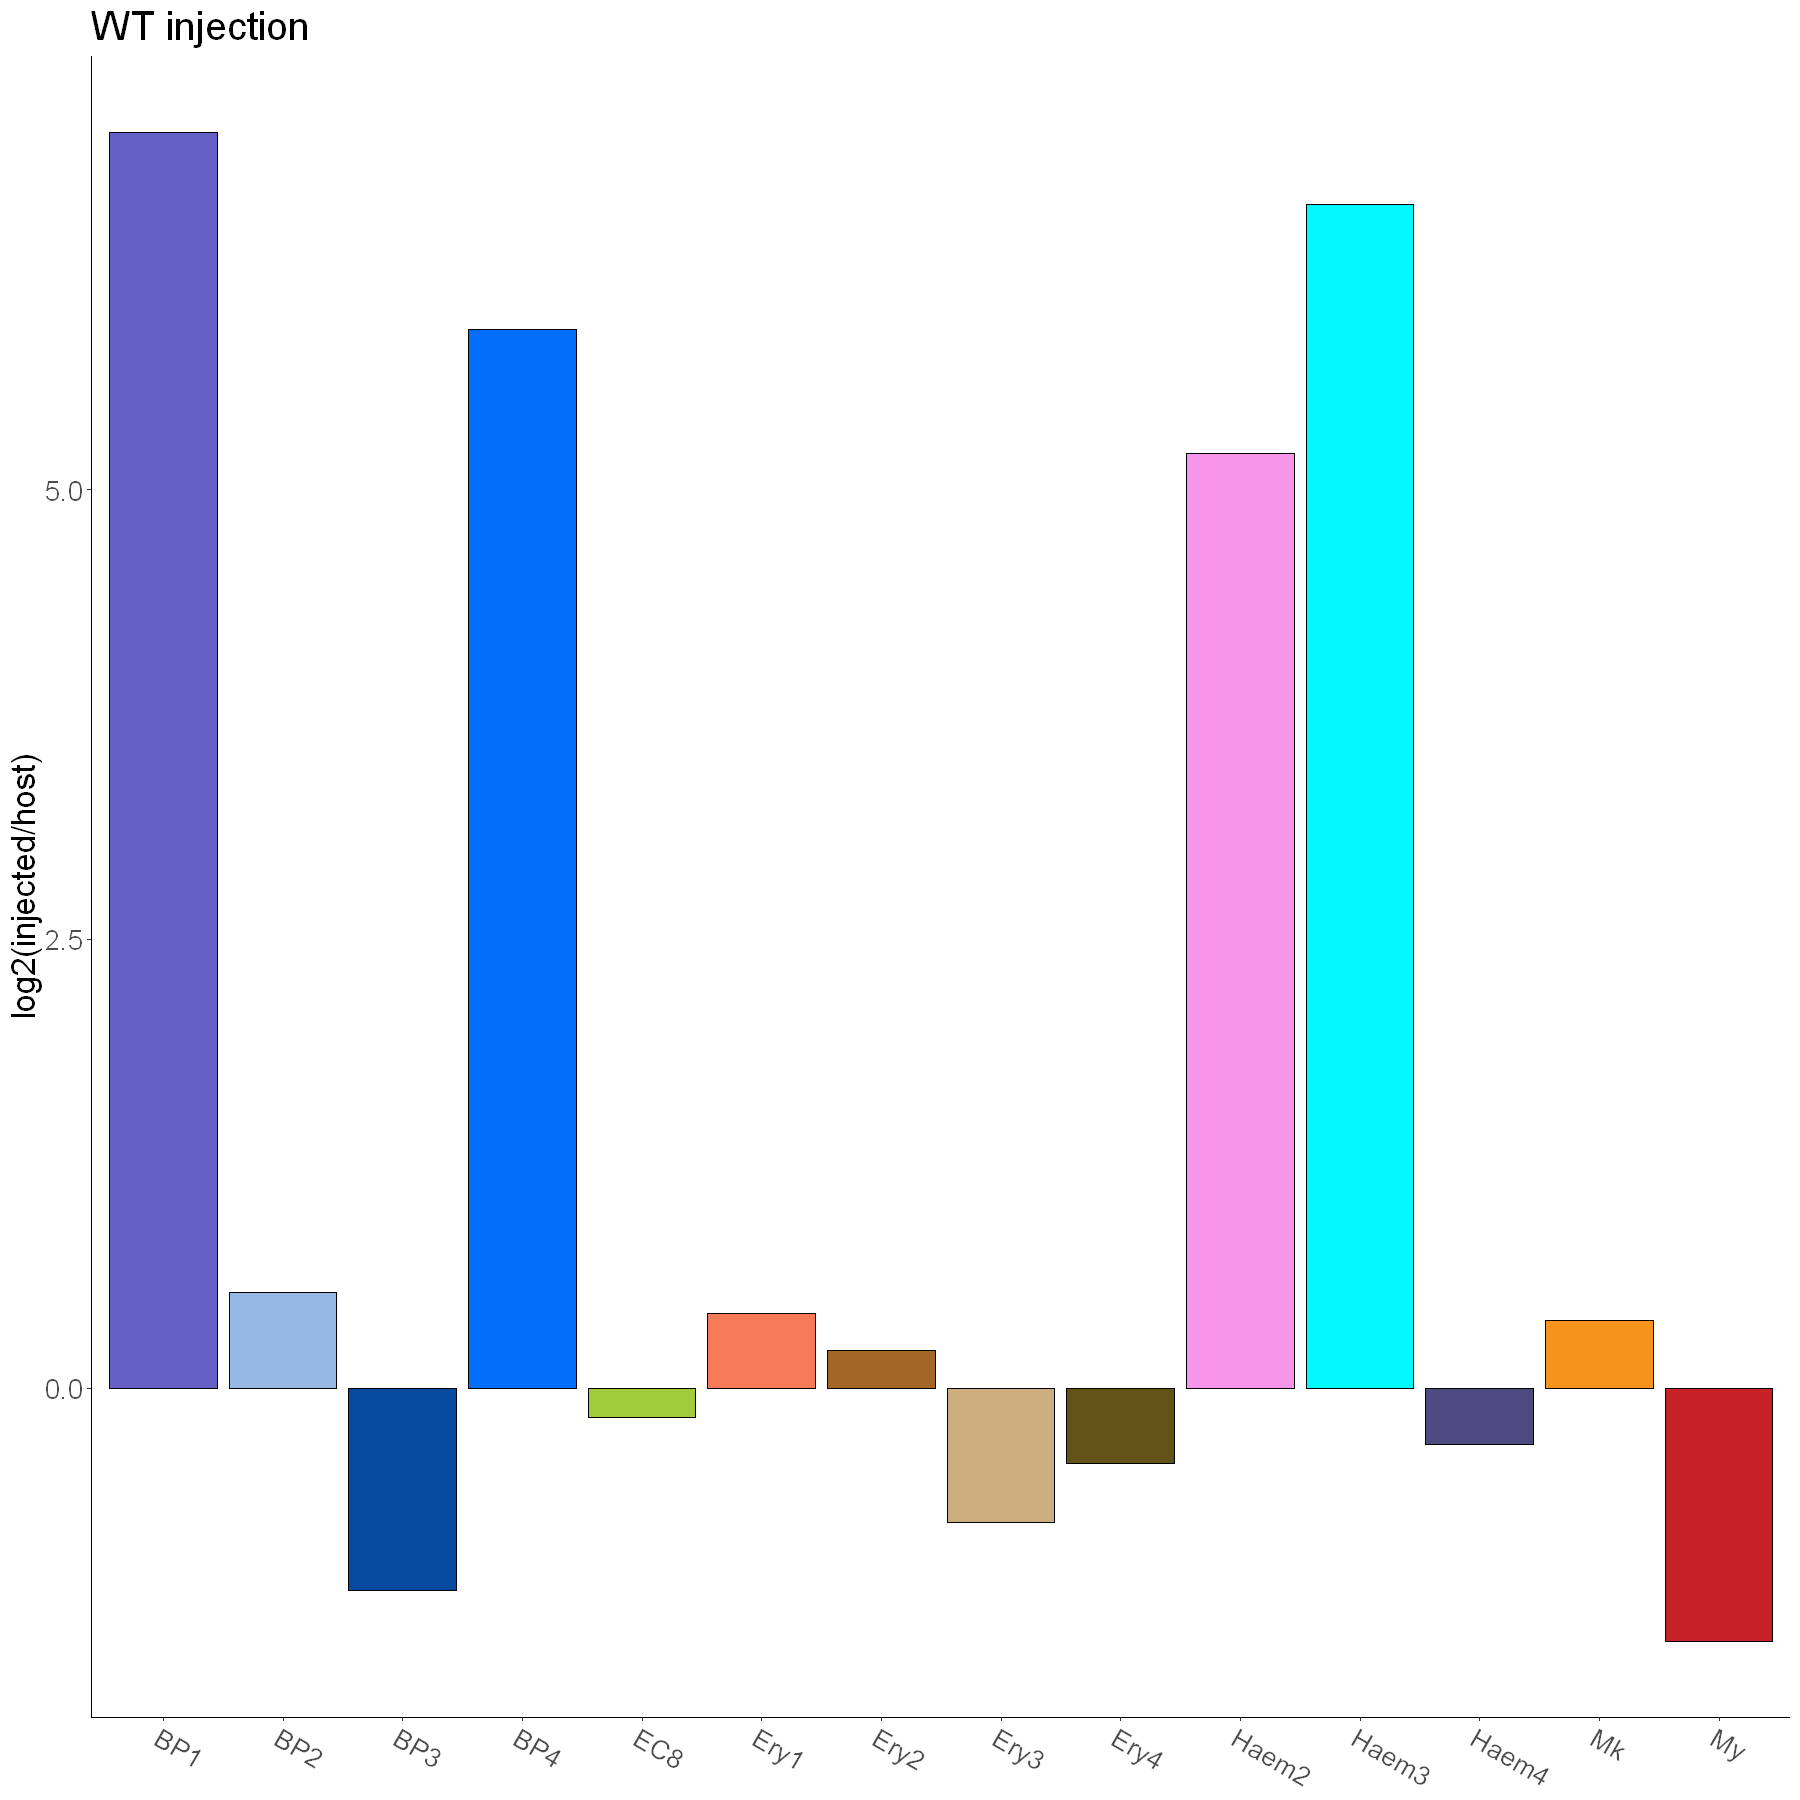

png 
  2

,Var1,sign,exp,ratio
,<fct>,<chr>,<chr>,<dbl>
1,BP1,positive,ratio_wt,6.9920565
2,BP2,positive,ratio_wt,0.5300182
3,BP3,positive,ratio_wt,-1.1261629
4,BP4,positive,ratio_wt,5.8952808
5,EC8,positive,ratio_wt,-0.1628268
6,Ery1,positive,ratio_wt,0.4144640


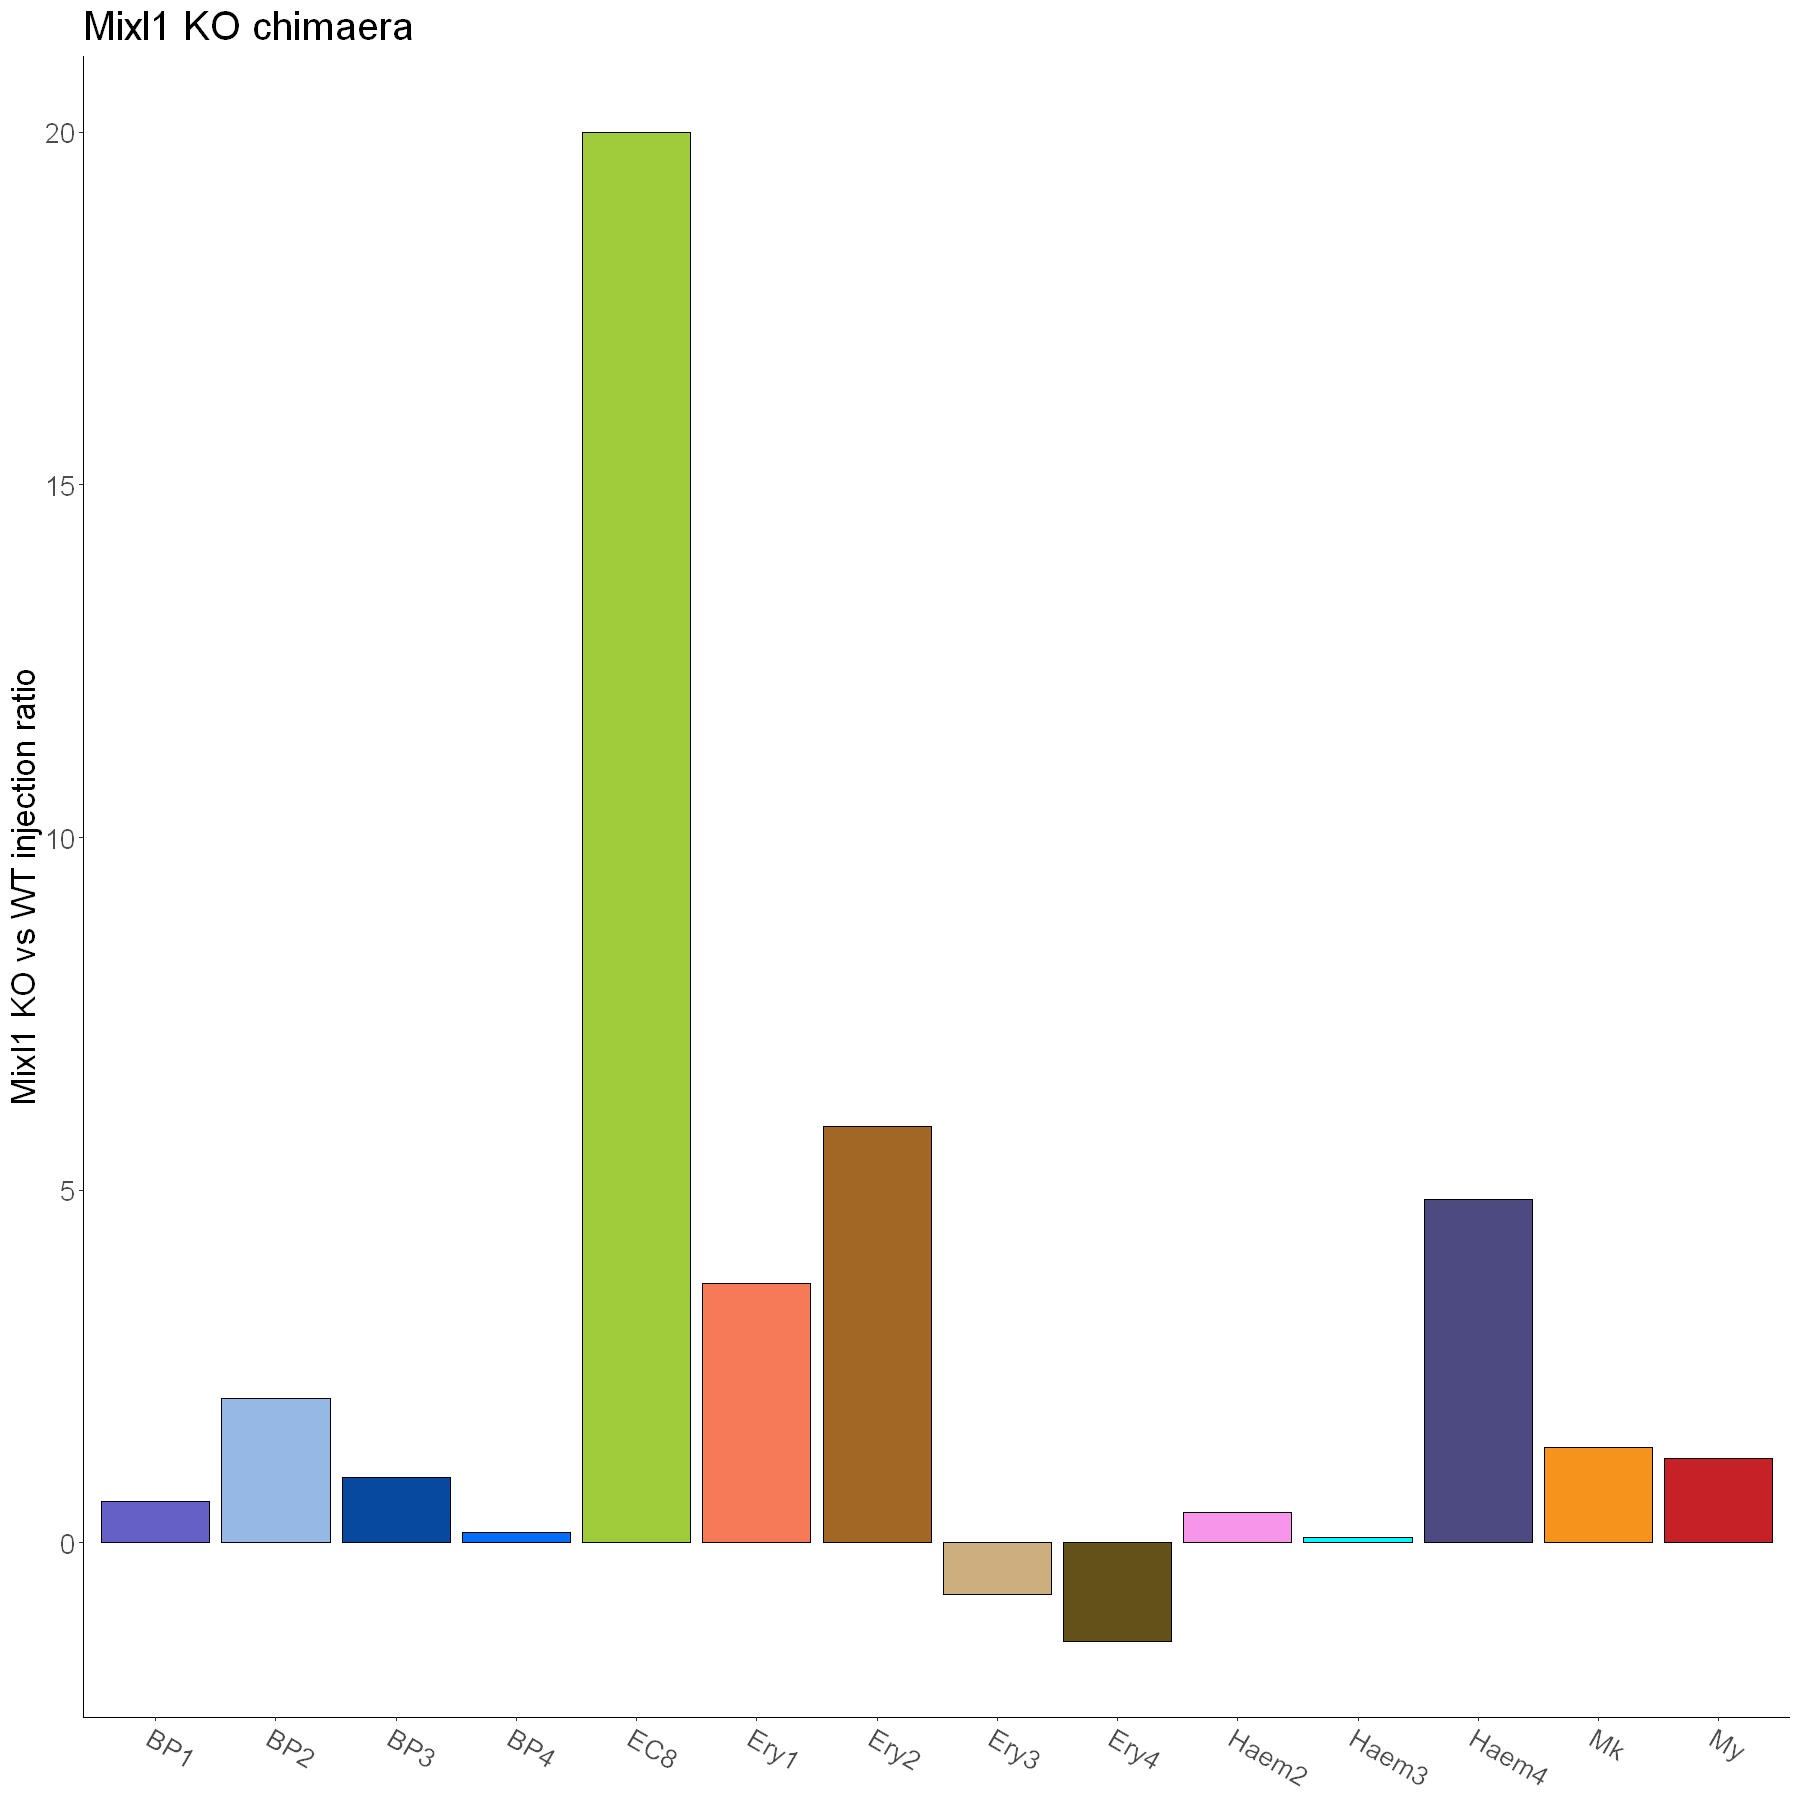

png 
  2

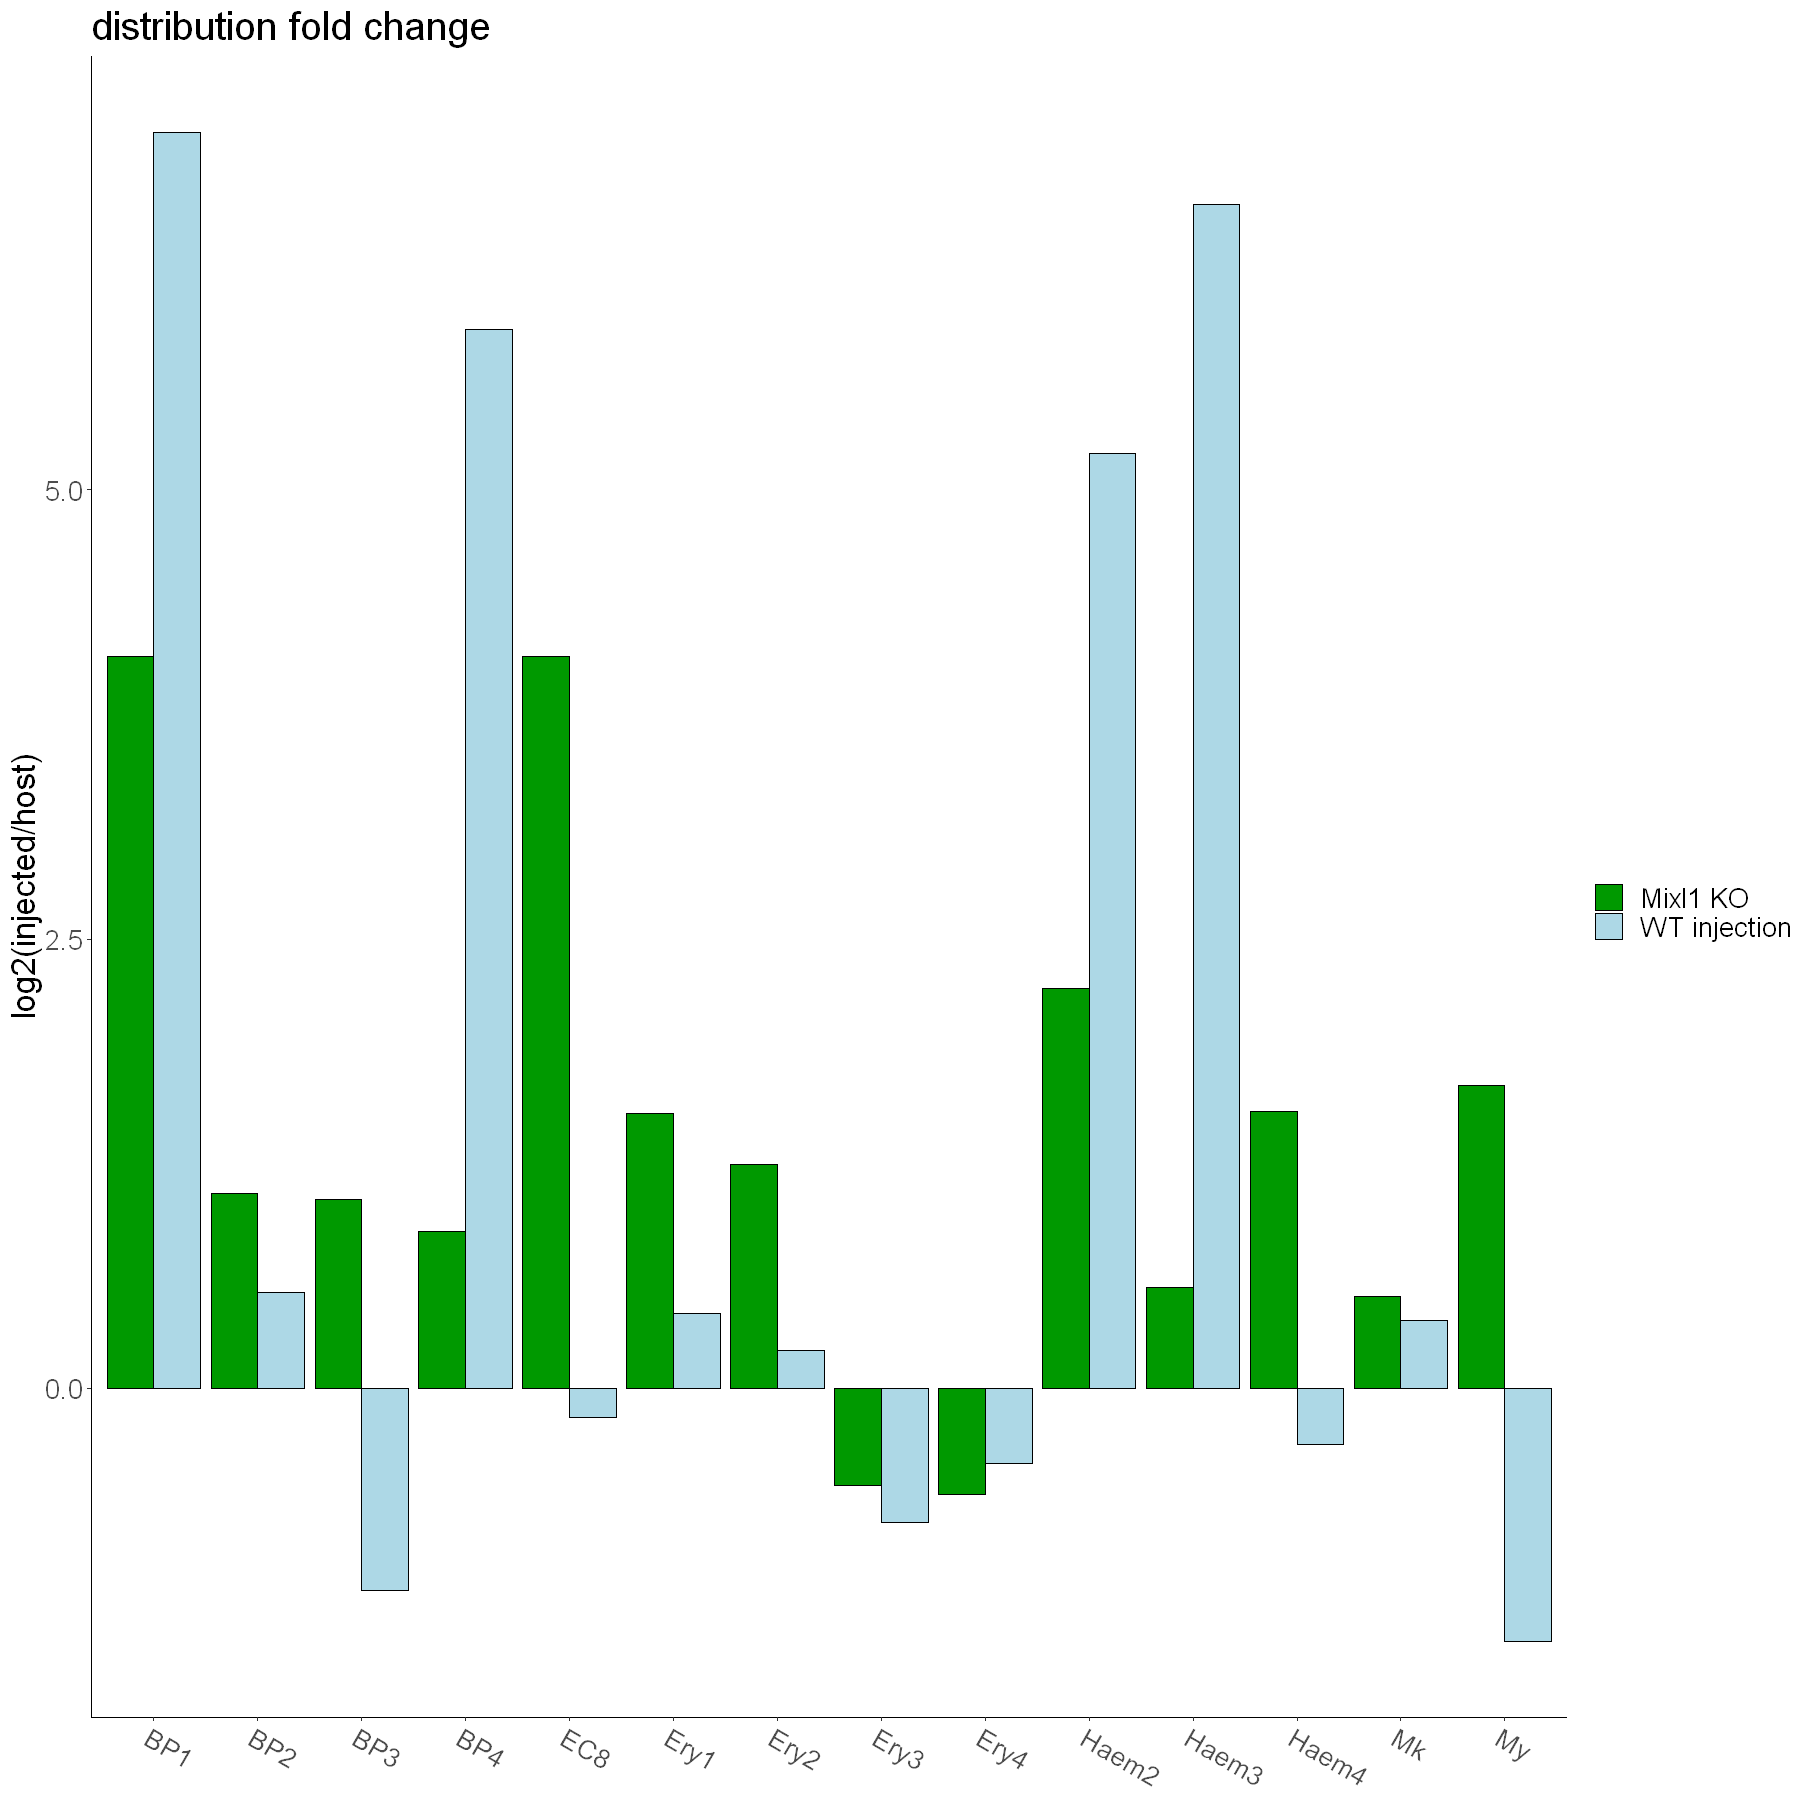

In [235]:
pdf3 = table(meta$haem_subclust.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.00001

p1 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20) ,
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))])

wt = pdf3

pdf3 = table(chim_meta$haem_subclust.mapped, chim_meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.00001

p2 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("Mixl1 KO injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "right", text = element_text(size = 20),
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(chim_meta$haem_subclust.mapped)[order(unique(chim_meta$haem_subclust.mapped))])

ko = pdf3

options(repr.plot.width = 15, repr.plot.height = 15)
grid.arrange(p1, p2, nrow =2)

pdf("C:/Users/aamw4/home/aamw4/celltype_ko_wt_haem_fraction_comparison.pdf", height=14, width=15)
    grid.arrange(p1, p2, nrow =2)
dev.off()

head(wt)

wt_ratio = spread(wt, Var2, Freq)
colnames(wt_ratio) = c('Var1','host', 'inject')
wt_ratio$ratio_wt = log(wt_ratio$inject/wt_ratio$host)
wt_ratio = wt_ratio %>% select(Var1, ratio_wt)

ko_ratio = spread(ko, Var2, Freq)
colnames(ko_ratio) = c('Var1','host', 'inject')
ko_ratio$ratio_ko = log(ko_ratio$inject/ko_ratio$host)
ko_ratio = ko_ratio %>% select(Var1, ratio_ko)

merged = merge(wt_ratio, ko_ratio, by='Var1')

merged$ratio = abs(merged$ratio_ko/merged$ratio_wt)
merged$sign =  ifelse(merged$ratio_ko < 0,"negative", "positive")
merged$ratio = ifelse(merged$sign == 'negative', -1*merged$ratio, merged$ratio)

head(merged)

#merged_stripped = merged %>% filter(Var1 != 'Mixed mesoderm')
p1 = ggplot(data = merged, mapping = aes(x = Var1, y = ratio_ko, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = haem_colours, labels = haem_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(chim_meta$haem_subclust.mapped)[order(unique(chim_meta$haem_subclust.mapped))])
p1

p2 = ggplot(data = merged, mapping = aes(x = Var1, y = ratio_wt, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = haem_colours, labels = haem_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))])
p2

pdf("C:/Users/aamw4/home/aamw4/celltype_ko_wt_haem_ratio.pdf", height=14, width=15)
    grid.arrange(p1, p2, nrow =2)
dev.off()

merged_maxed = merged
merged_maxed$ratio = ifelse(merged_maxed$ratio > 20, 20, merged_maxed$ratio)

p = ggplot(data = merged_maxed, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "Mixl1 KO vs WT injection ratio") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = haem_colours, labels = haem_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(chim_meta$haem_subclust.mapped)[order(unique(chim_meta$haem_subclust.mapped))])

p

pdf("C:/Users/aamw4/home/aamw4/celltype_injection_haem_ratio.pdf", height=8, width=15)
    p
dev.off()

merged2 = gather(merged, exp, ratio, -Var1, -ratio, -sign)

head(merged2)

#merged_stripped = merged %>% filter(Var1 != 'Mixed mesoderm')
p = ggplot(data = merged2, mapping = aes(x = Var1, y = ratio, fill=exp)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("distribution fold change") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  scale_fill_manual(values = c("ratio_ko" = "#009900", "ratio_wt" = "#add8e6"), 
                    labels = c("ratio_ko" = "Mixl1 KO", "ratio_wt" = "WT injection"),
                    name = "") +
  scale_x_discrete(breaks = unique(chim_meta$haem_subclust.mapped)[order(unique(chim_meta$haem_subclust.mapped))])
p

pdf("C:/Users/aamw4/home/aamw4/celltype_ko_wt_ratio_haem_side.pdf", height=8, width=15)
    p
dev.off()

In [195]:
unique(chim_meta$tdTom)

[1] "pos" "neg"

In [190]:
meta2 <- chim_meta %>% filter(!is.na(chim_meta$tdTom))

In [ ]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = chim_meta$haem_subclust.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas haem_subclust", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(chim_meta$haem_subclust.mapped)[order(unique(chim_meta$haem_subclust.mapped))])
  
  

pdf1 = table(chim_meta$haem_subclust.mapped[chim_meta$sample %in% embryo1], meta$tdTom[chim_meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas haem_subclust", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(chim_meta$haem_subclust.mapped)[order(unique(chim_meta$haem_subclust.mapped))])


pdf2 = table(meta$haem_subclust.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas haem_subclust", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))], 
                   drop = FALSE)

pdf3 = table(chim_meta$haem_subclust.mapped, chim_meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas haem_subclust", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(chim_meta$haem_subclust.mapped)[order(unique(chim_meta$haem_subclust.mapped))])

options(repr.plot.width = 20, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

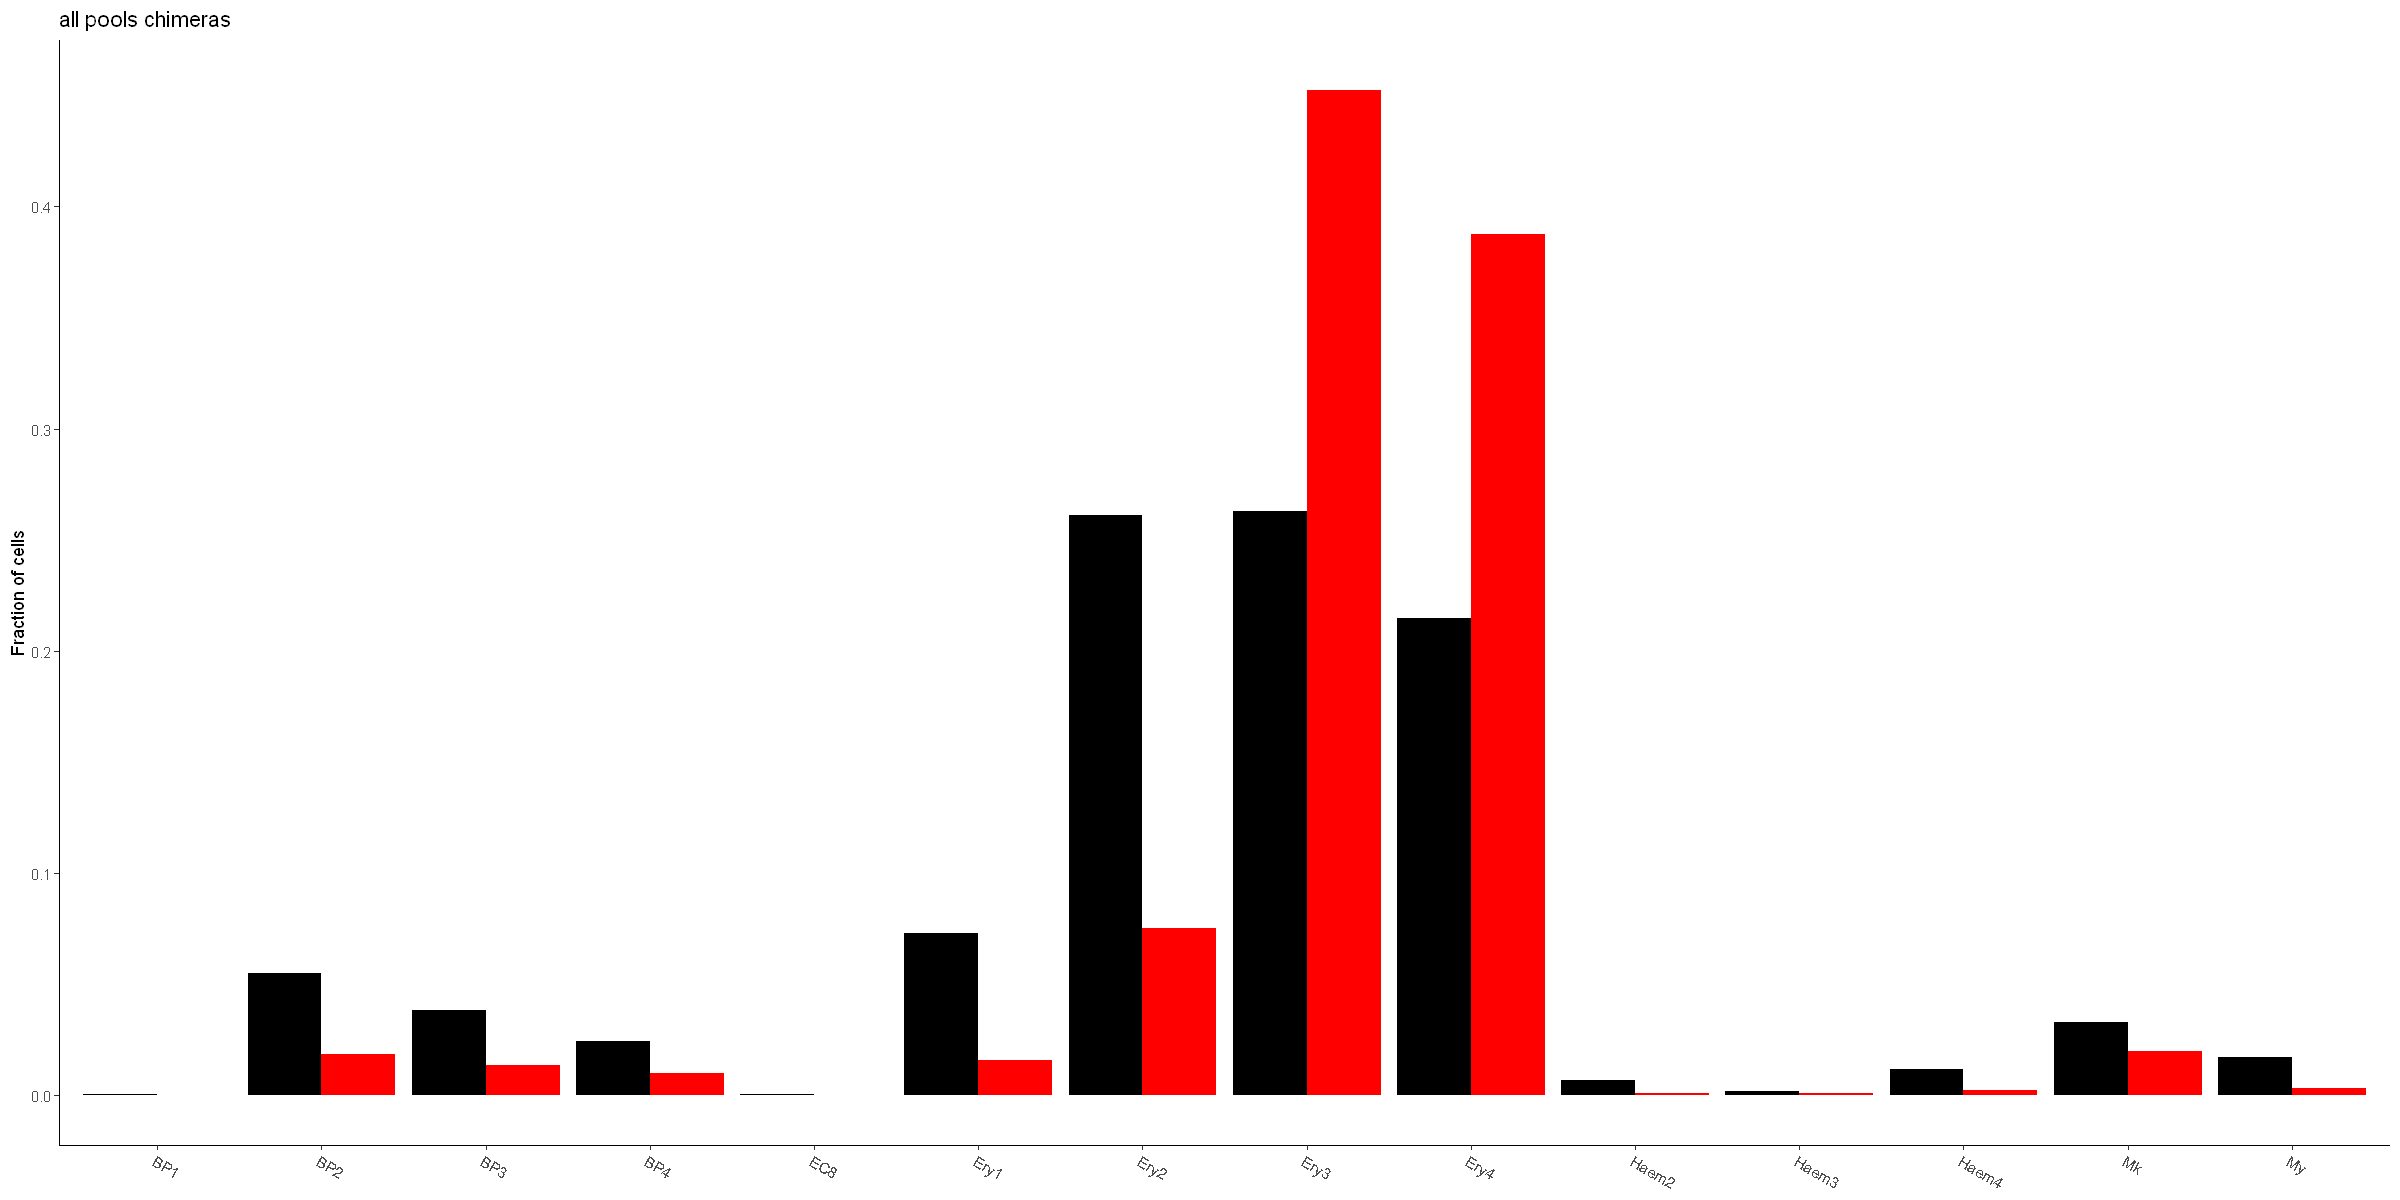

In [193]:
pdf3 = table(meta$haem_subclust.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas haem_subclust", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))])

options(repr.plot.width = 20, repr.plot.height = 10)
plot(p4)

png 
  2

,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
1,Foregut 1,neg,0.06819182
2,Foregut 2,neg,0.06819182
3,Hindgut 1,neg,0.04546455
4,Hindgut 2,neg,0.27273727
5,Midgut,neg,0.06819182
6,Midgut/Hindgut,neg,0.20455545


,Var1,ratio_wt,ratio_ko,ratio,sign
,<fct>,<dbl>,<dbl>,<dbl>,<chr>
1,Foregut 1,0.15982704,-0.7956263,-4.9780459,negative
2,Foregut 2,0.56525048,-0.5476252,-0.9688187,negative
3,Hindgut 1,-0.82070065,-7.1644972,-8.7297326,negative
4,Hindgut 2,0.02631636,-0.9756703,-37.0746743,negative
5,Midgut,0.15982704,-1.6688530,-10.4416187,negative
6,Midgut/Hindgut,-0.71556893,-3.1378108,-4.3850574,negative


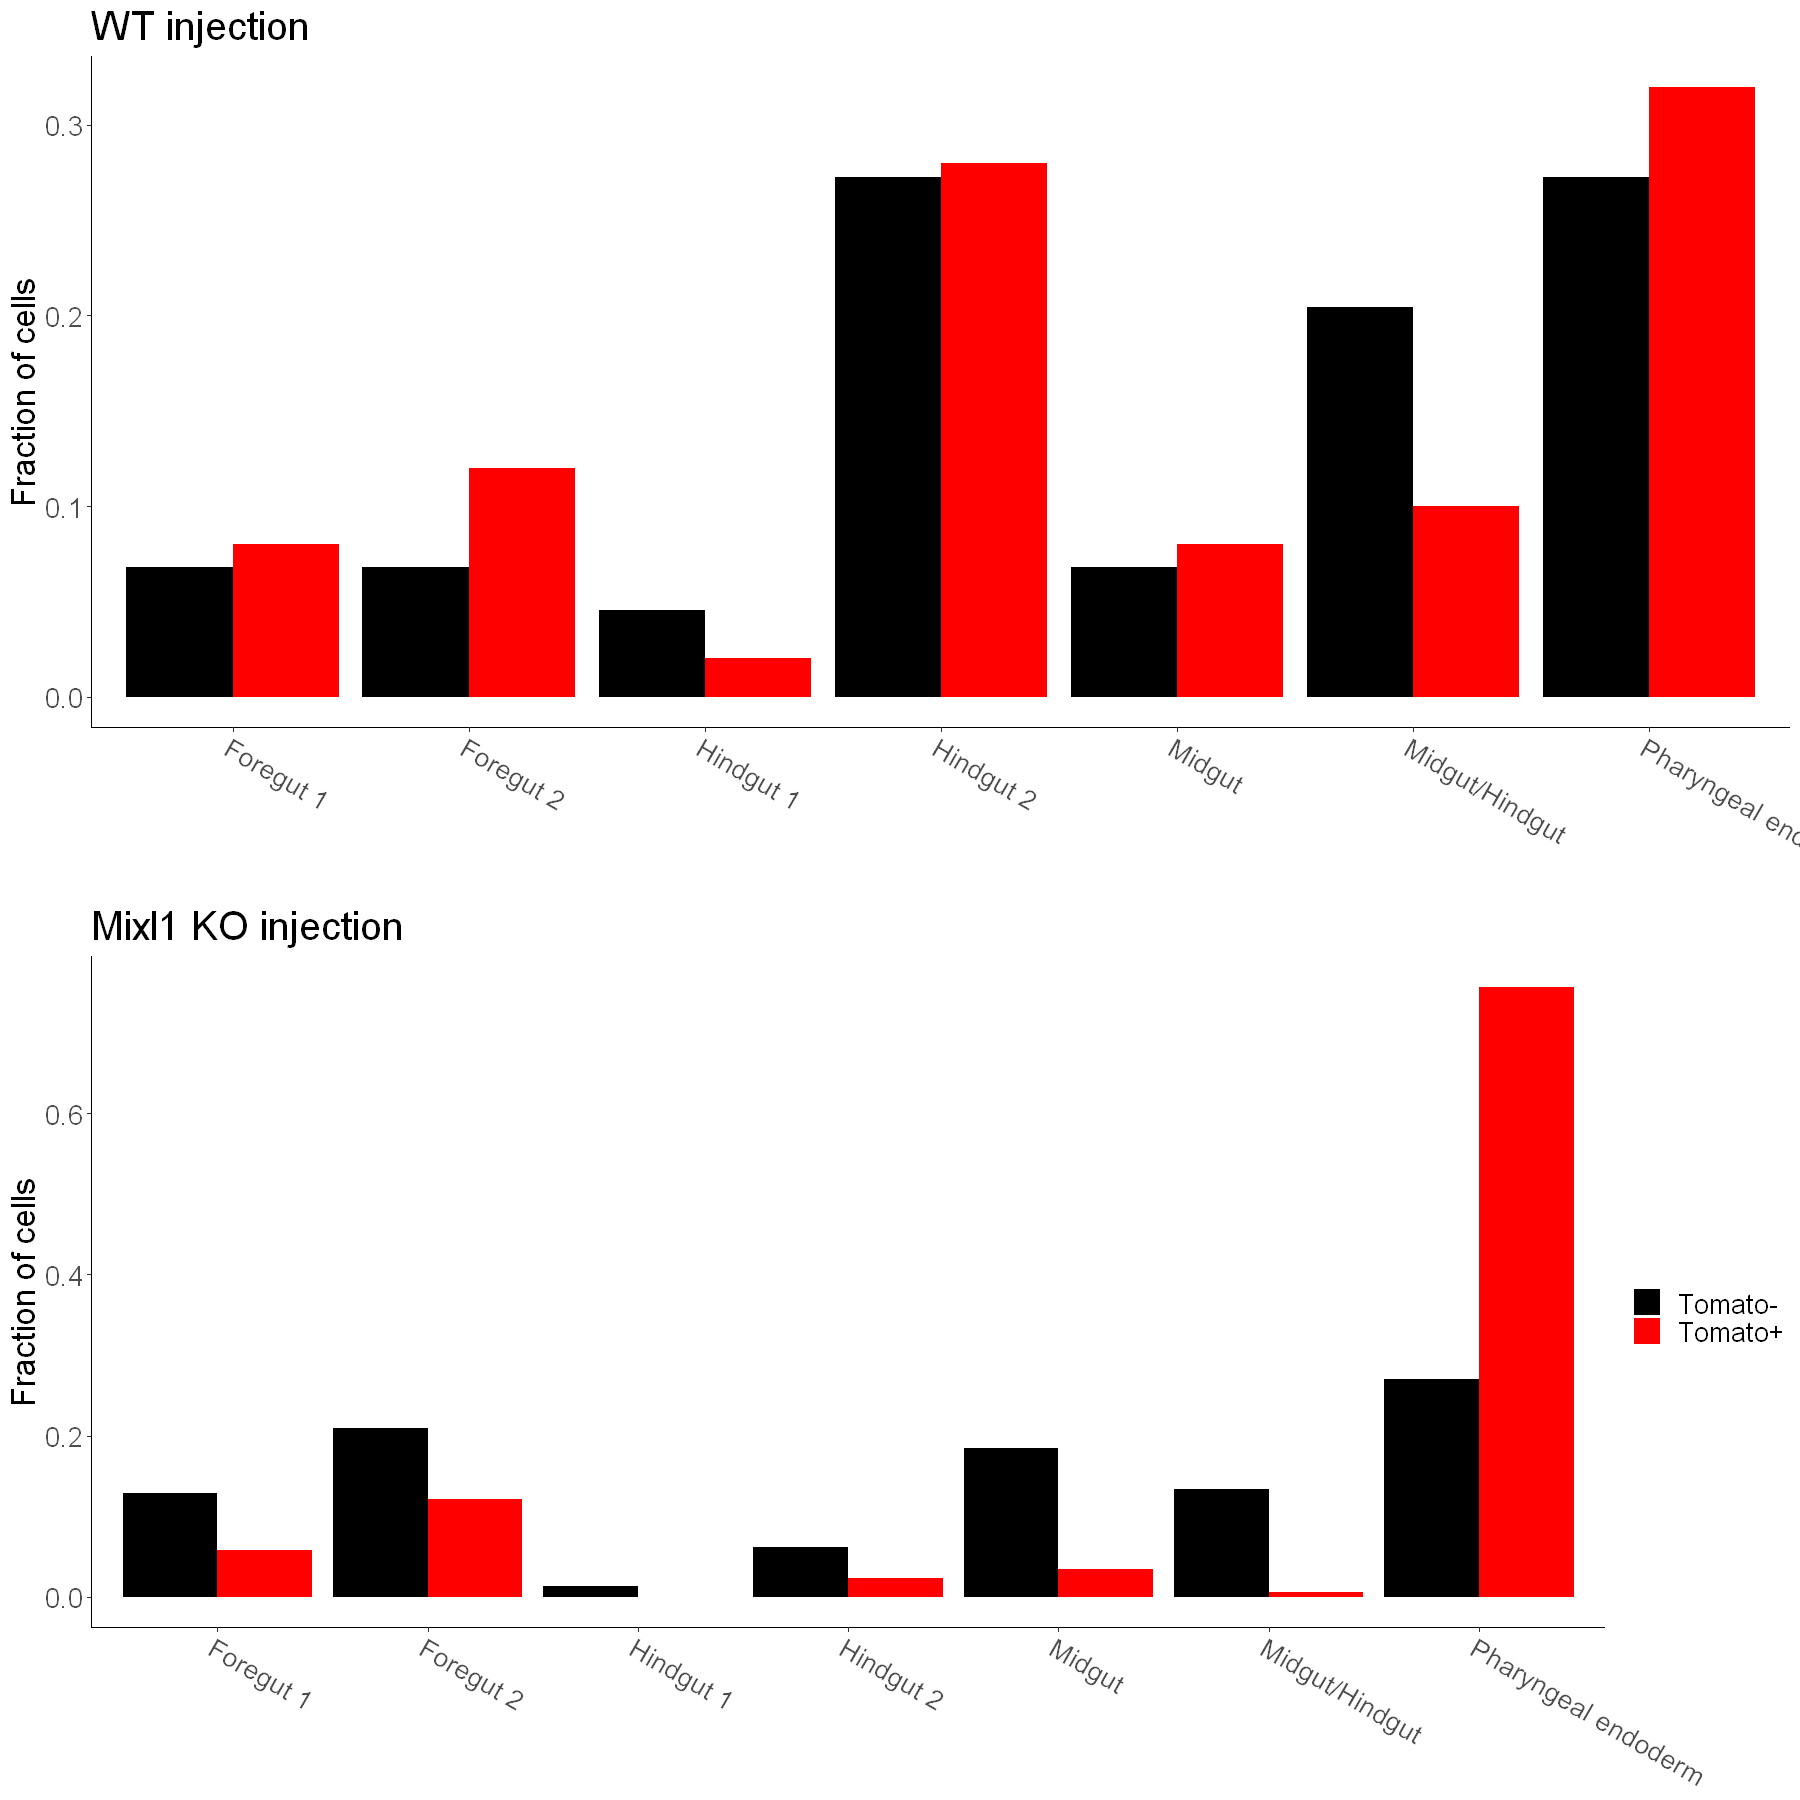

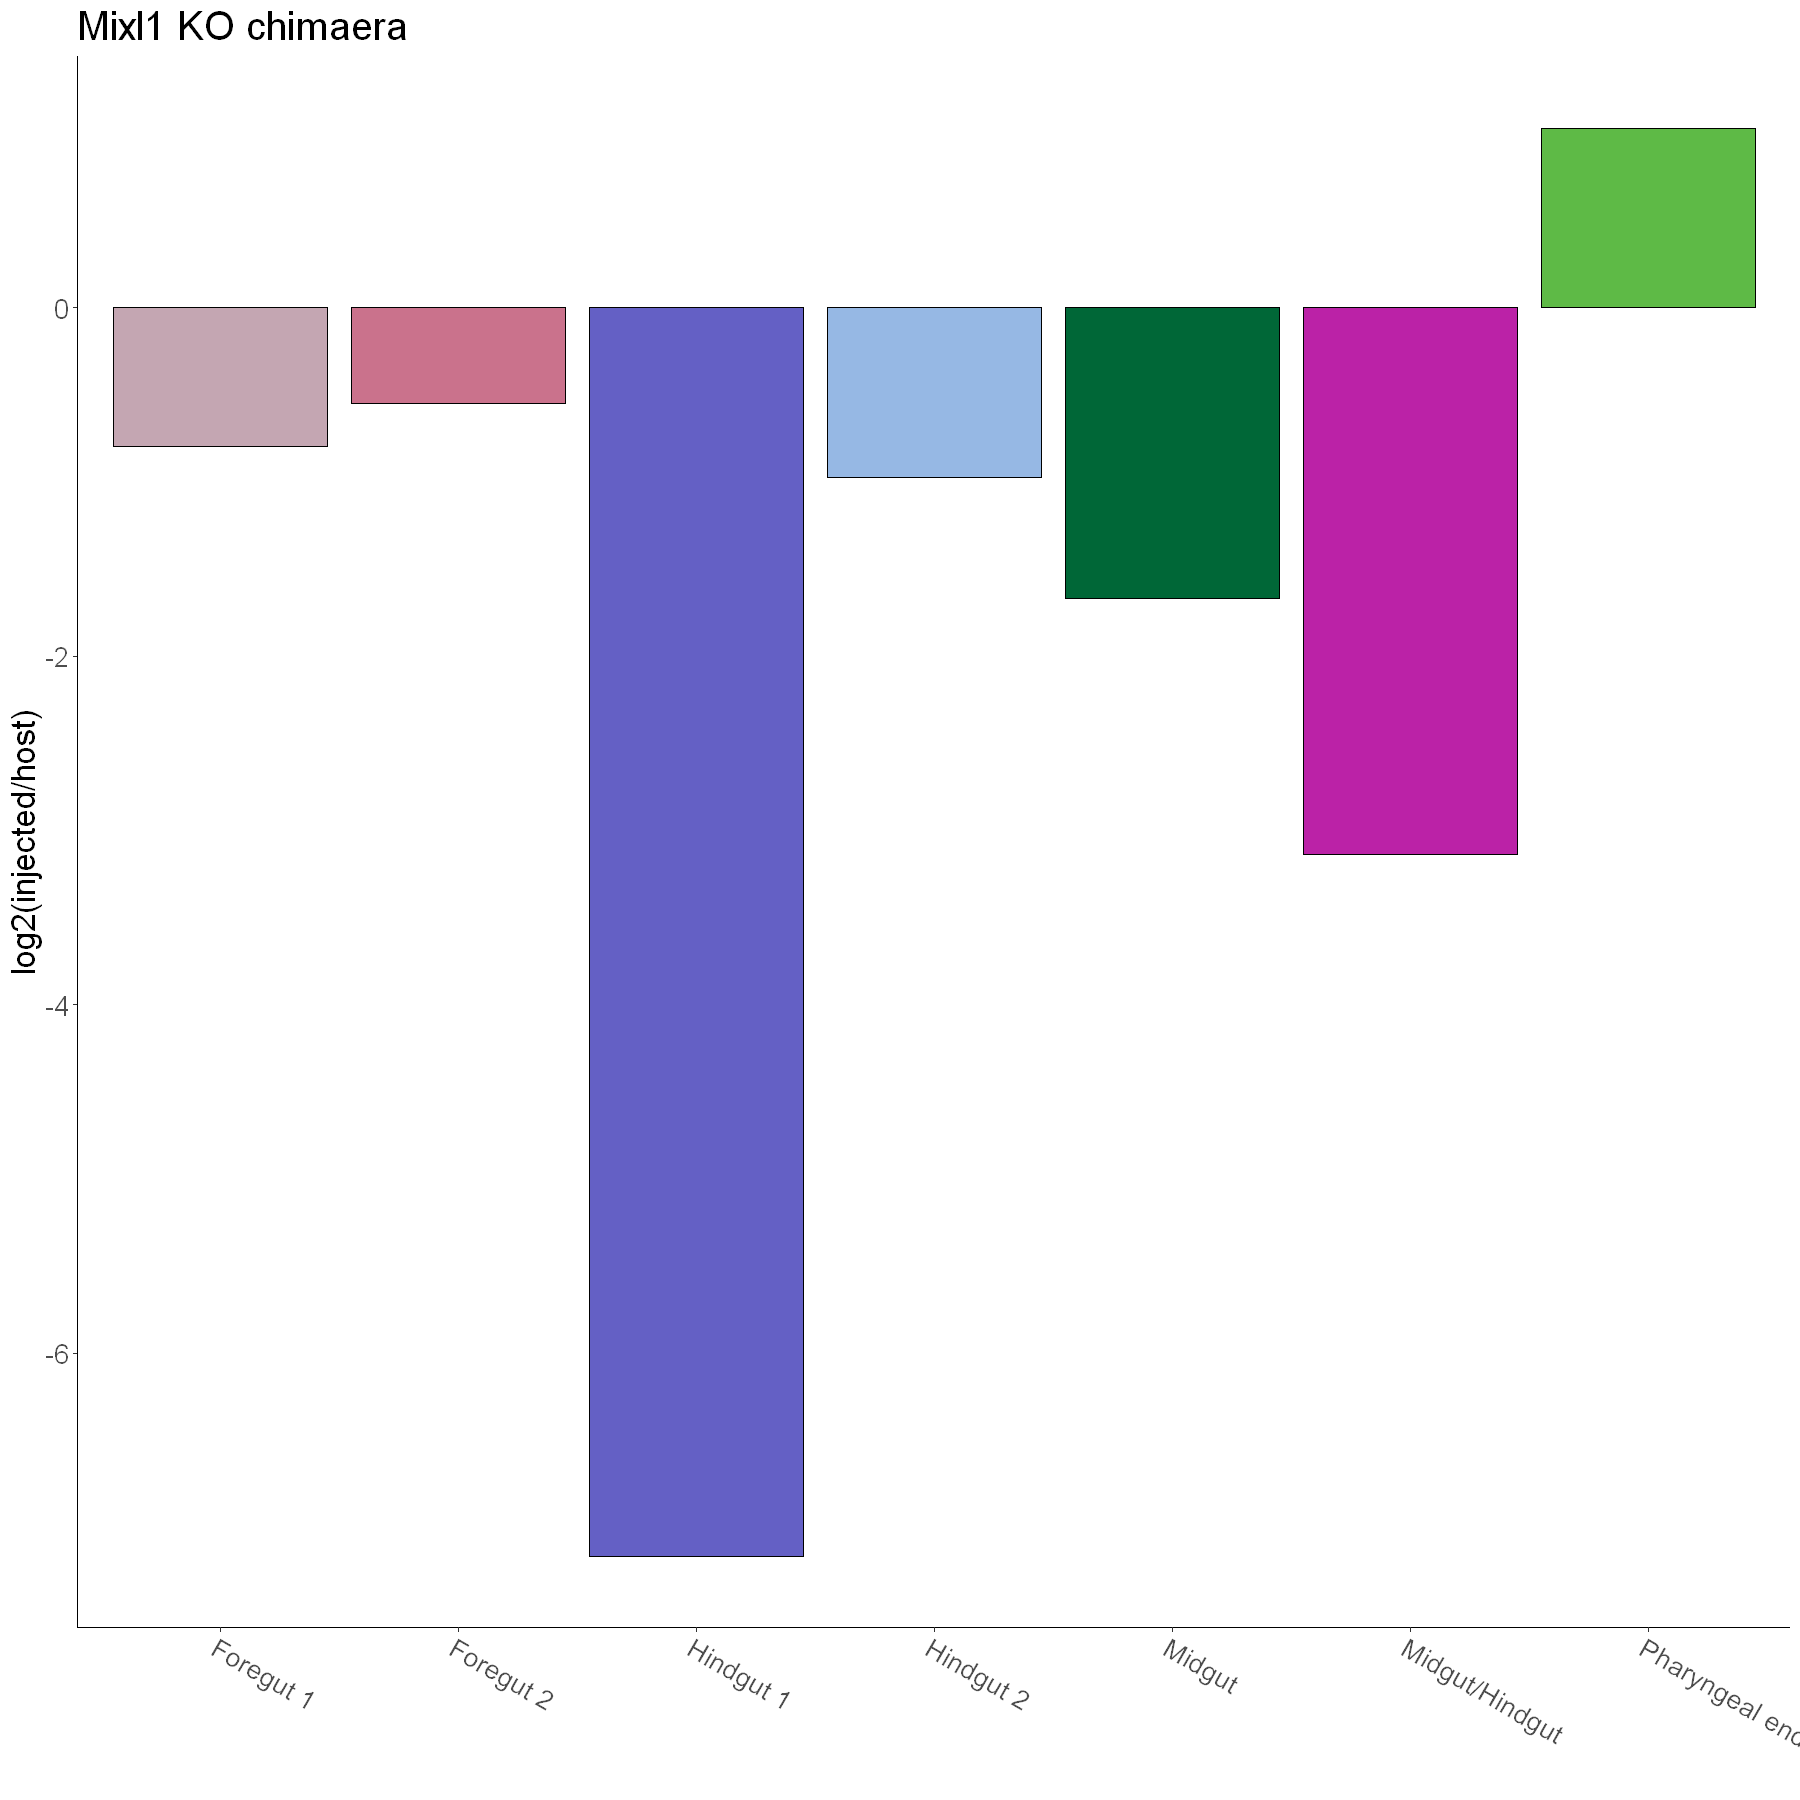

png 
  2

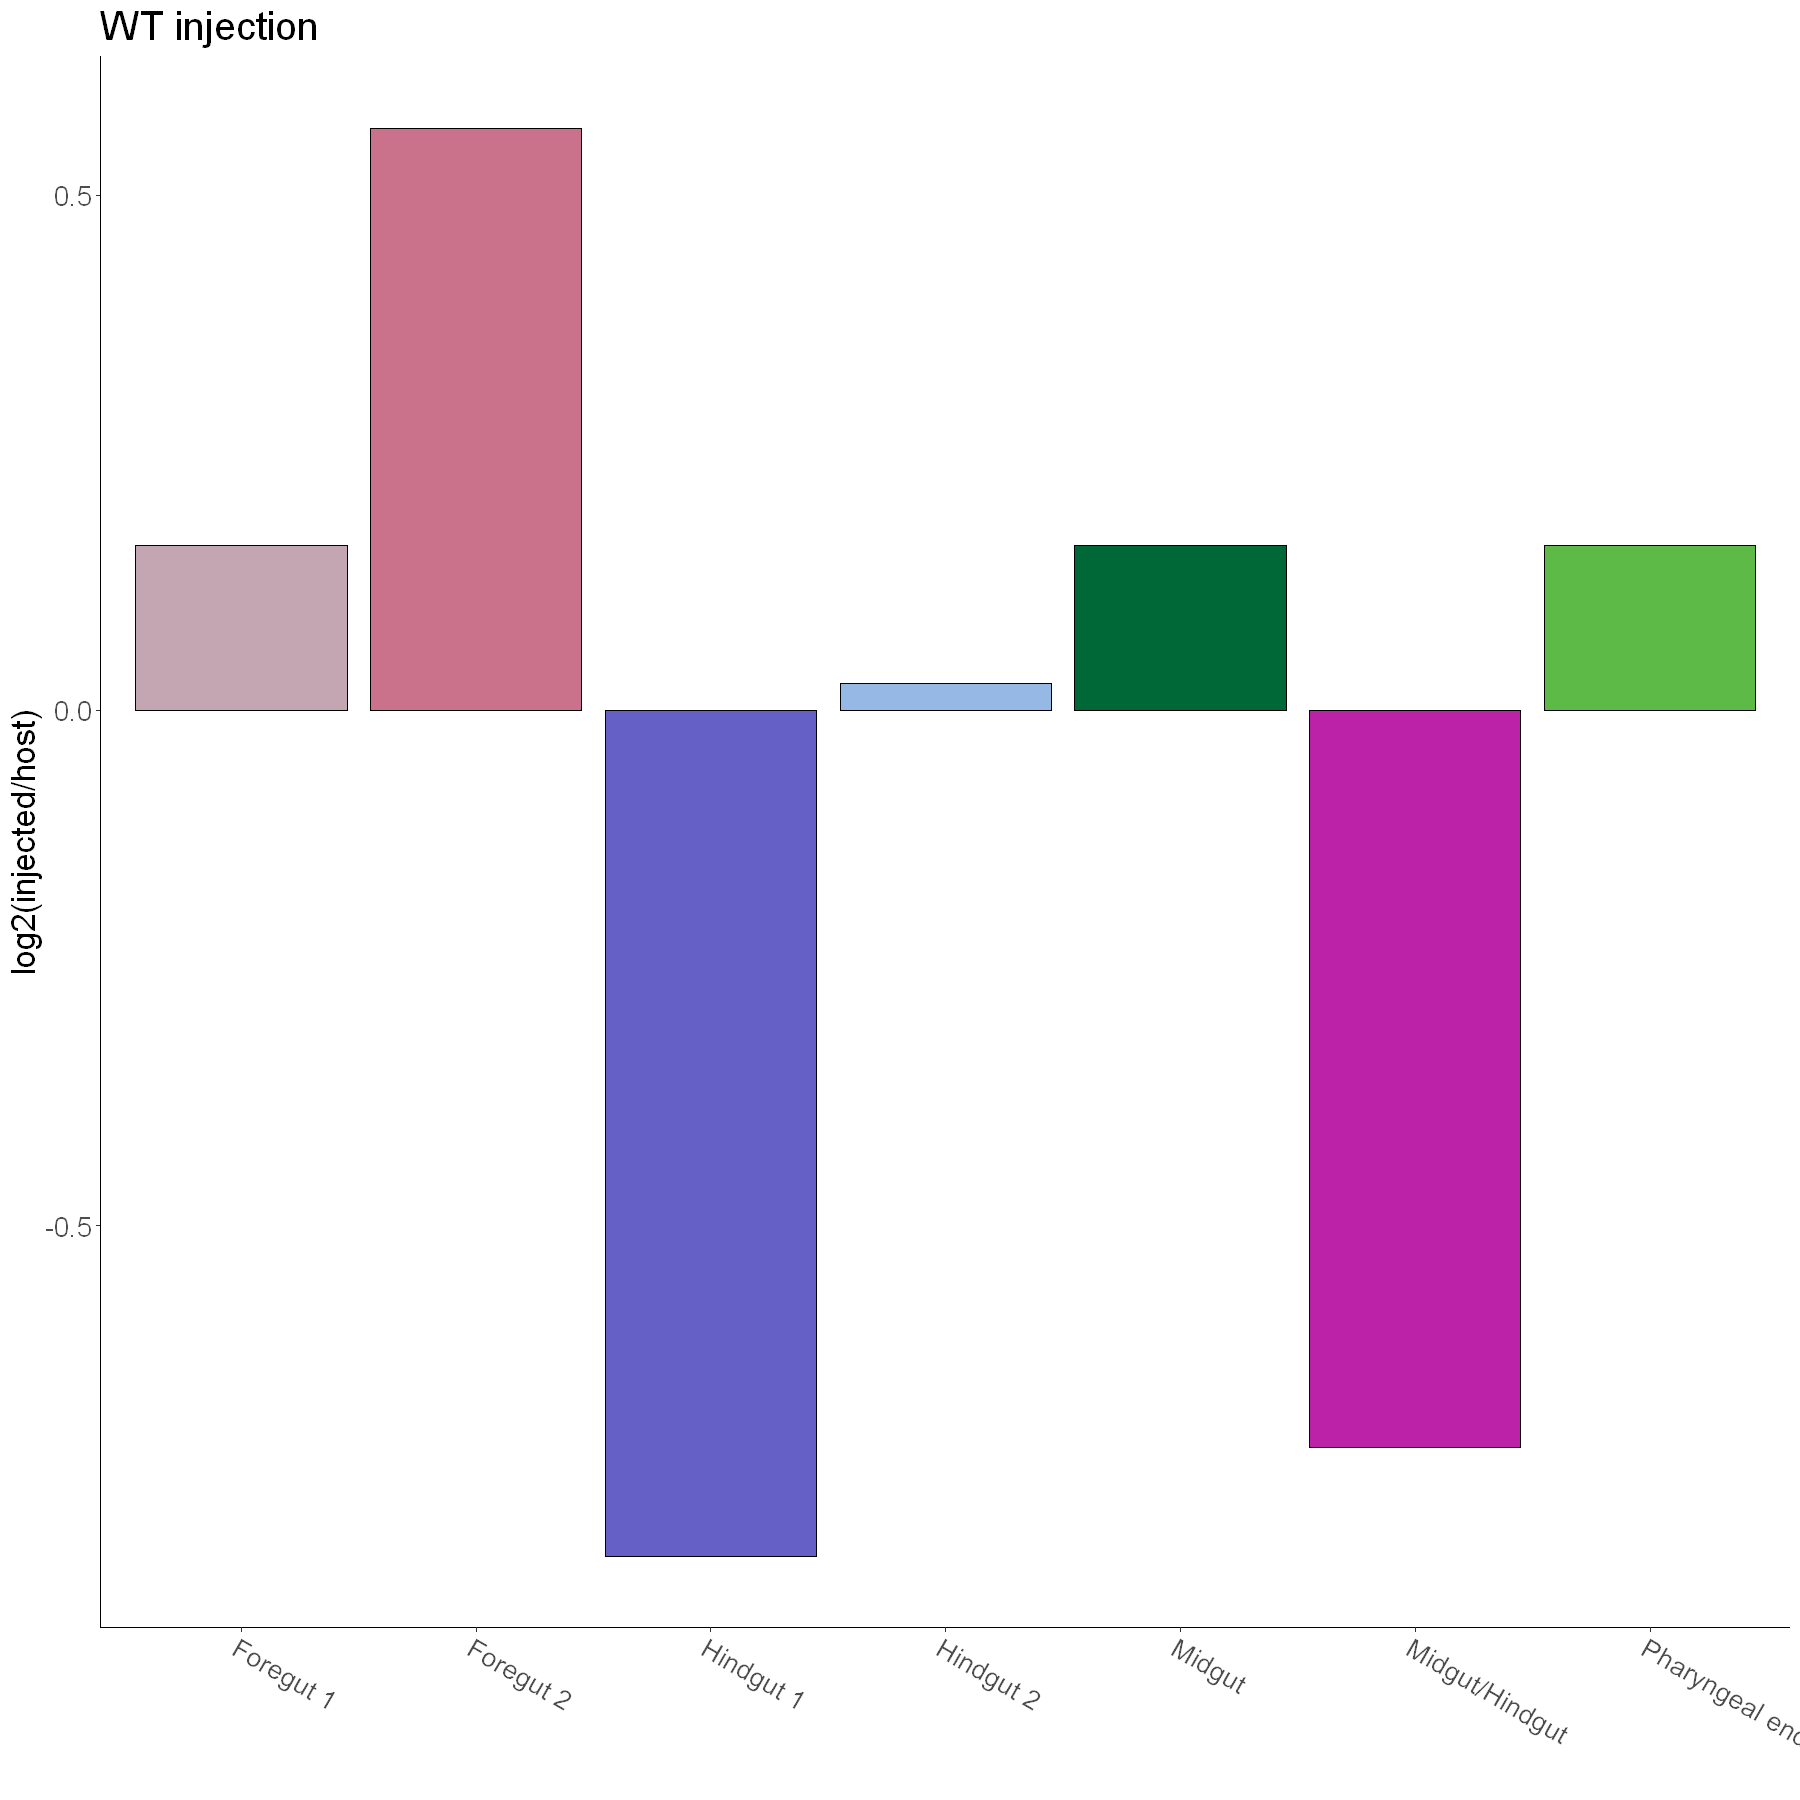

png 
  2

,Var1,sign,exp,ratio
,<fct>,<chr>,<chr>,<dbl>
1,Foregut 1,negative,ratio_wt,0.15982704
2,Foregut 2,negative,ratio_wt,0.56525048
3,Hindgut 1,negative,ratio_wt,-0.82070065
4,Hindgut 2,negative,ratio_wt,0.02631636
5,Midgut,negative,ratio_wt,0.15982704
6,Midgut/Hindgut,negative,ratio_wt,-0.71556893


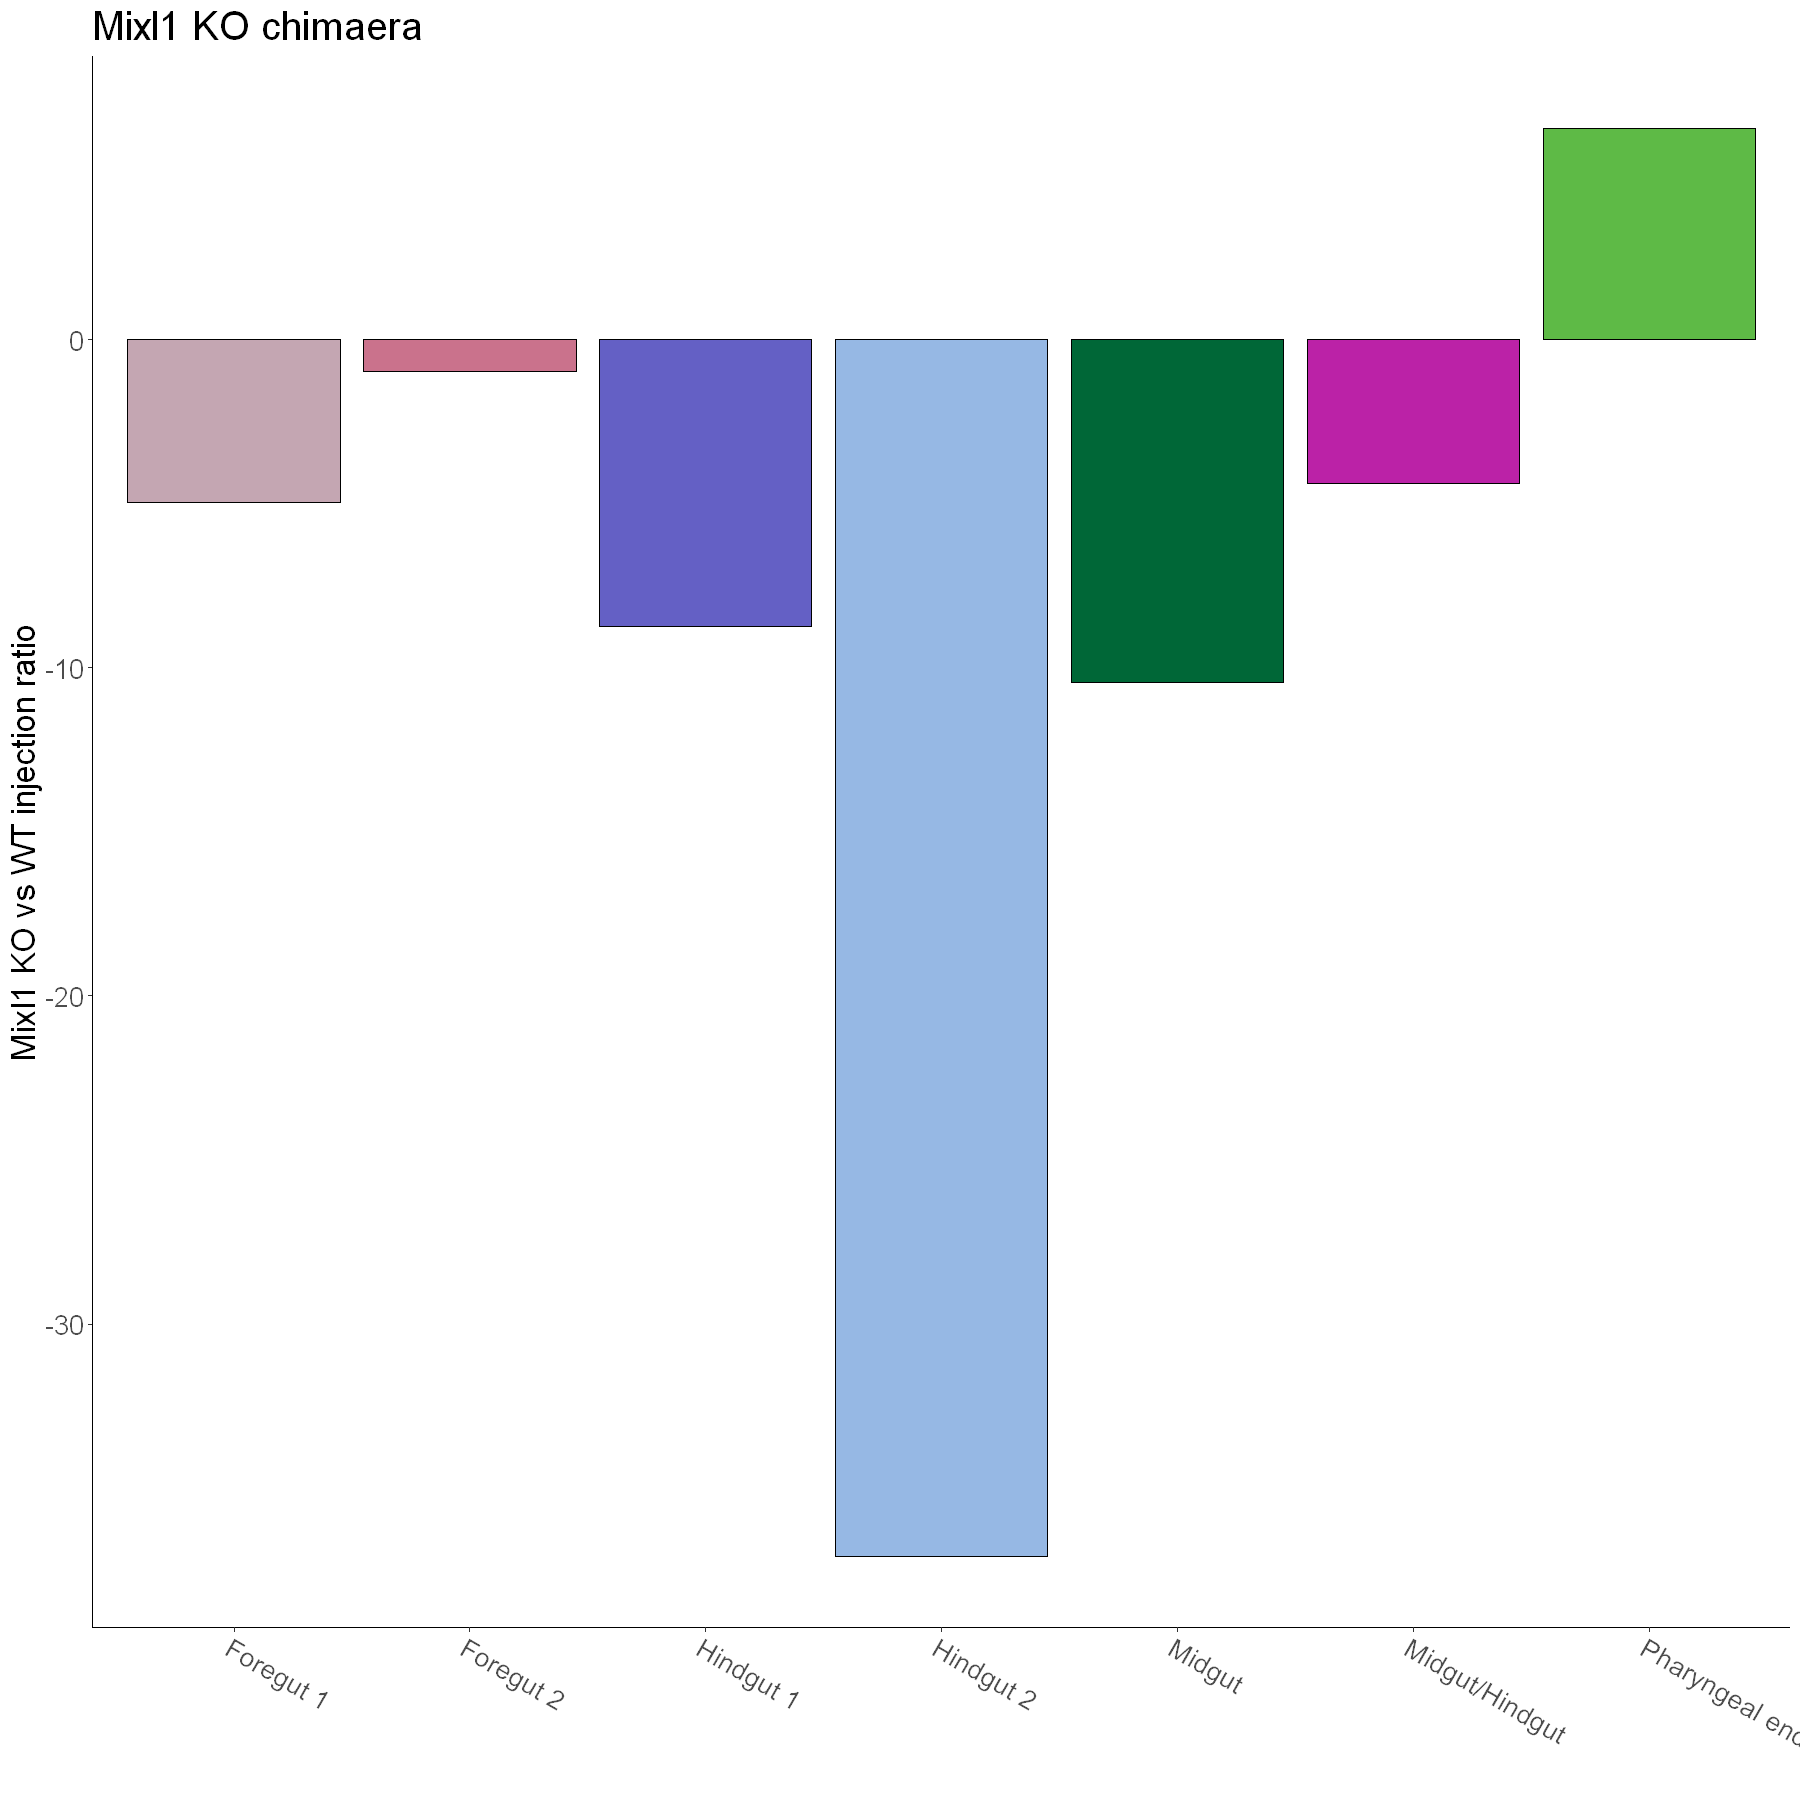

png 
  2

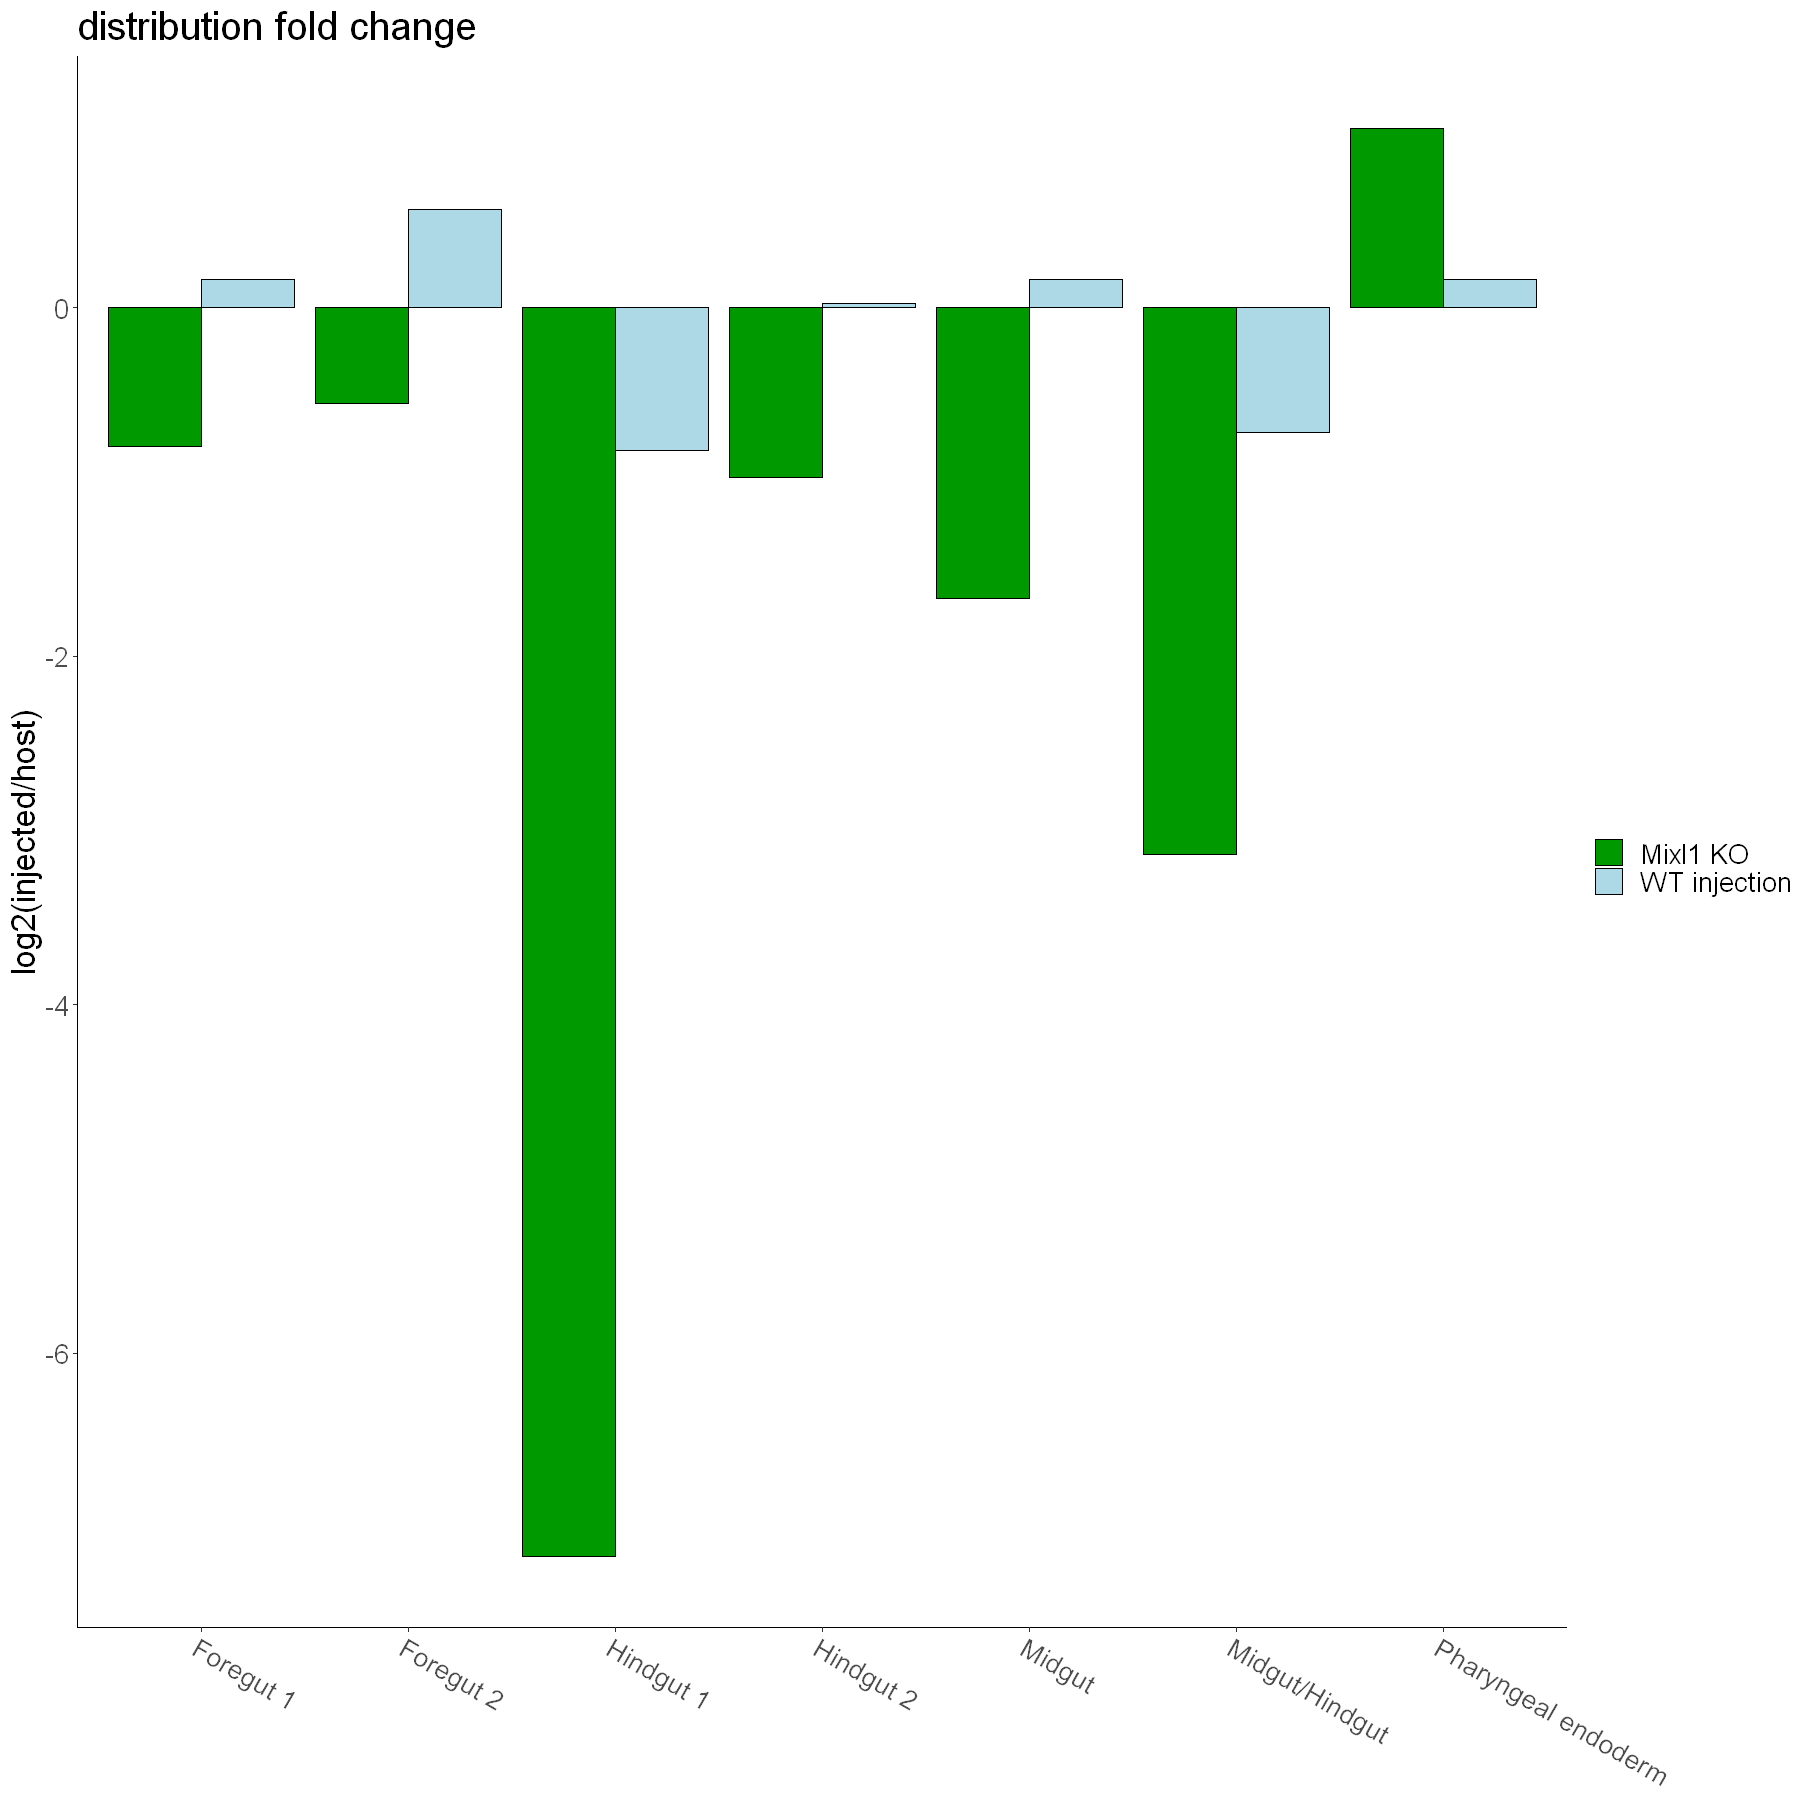

In [242]:
pdf3 = table(meta$gut_subclust.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.00001

p1 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20) ,
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$gut_subclust.mapped)[order(unique(meta$gut_subclust.mapped))])

wt = pdf3

pdf3 = table(gut_meta$gut_subclust.mapped, gut_meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.00001

p2 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("Mixl1 KO injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "right", text = element_text(size = 20),
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(gut_meta$gut_subclust.mapped)[order(unique(gut_meta$gut_subclust.mapped))])

ko = pdf3

options(repr.plot.width = 15, repr.plot.height = 15)
grid.arrange(p1, p2, nrow =2)

pdf("C:/Users/aamw4/home/aamw4/celltype_ko_wt_gut_fraction_comparison.pdf", height=14, width=15)
    grid.arrange(p1, p2, nrow =2)
dev.off()

head(wt)

wt_ratio = spread(wt, Var2, Freq)
colnames(wt_ratio) = c('Var1','host', 'inject')
wt_ratio$ratio_wt = log(wt_ratio$inject/wt_ratio$host)
wt_ratio = wt_ratio %>% select(Var1, ratio_wt)

ko_ratio = spread(ko, Var2, Freq)
colnames(ko_ratio) = c('Var1','host', 'inject')
ko_ratio$ratio_ko = log(ko_ratio$inject/ko_ratio$host)
ko_ratio = ko_ratio %>% select(Var1, ratio_ko)

merged = merge(wt_ratio, ko_ratio, by='Var1')

merged$ratio = abs(merged$ratio_ko/merged$ratio_wt)
merged$sign =  ifelse(merged$ratio_ko < 0,"negative", "positive")
merged$ratio = ifelse(merged$sign == 'negative', -1*merged$ratio, merged$ratio)

head(merged)

#merged_stripped = merged %>% filter(Var1 != 'Mixed mesoderm')
p1 = ggplot(data = merged, mapping = aes(x = Var1, y = ratio_ko, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = gut_colours, labels = gut_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(gut_meta$gut_subclust.mapped)[order(unique(gut_meta$gut_subclust.mapped))])
p1

p2 = ggplot(data = merged, mapping = aes(x = Var1, y = ratio_wt, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = gut_colours, labels = gut_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$gut_subclust.mapped)[order(unique(meta$gut_subclust.mapped))])
p2

pdf("C:/Users/aamw4/home/aamw4/celltype_ko_wt_gut_ratio.pdf", height=14, width=15)
    grid.arrange(p1, p2, nrow =2)
dev.off()

merged_maxed = merged
merged_maxed$ratio = ifelse(merged_maxed$ratio > 20, 20, merged_maxed$ratio)

p = ggplot(data = merged_maxed, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "Mixl1 KO vs WT injection ratio") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = gut_colours, labels = gut_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(gut_meta$gut_subclust.mapped)[order(unique(gut_meta$gut_subclust.mapped))])

p

pdf("C:/Users/aamw4/home/aamw4/celltype_injection_gut_ratio.pdf", height=8, width=15)
    p
dev.off()

merged2 = gather(merged, exp, ratio, -Var1, -ratio, -sign)

head(merged2)

#merged_stripped = merged %>% filter(Var1 != 'Mixed mesoderm')
p = ggplot(data = merged2, mapping = aes(x = Var1, y = ratio, fill=exp)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("distribution fold change") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  scale_fill_manual(values = c("ratio_ko" = "#009900", "ratio_wt" = "#add8e6"), 
                    labels = c("ratio_ko" = "Mixl1 KO", "ratio_wt" = "WT injection"),
                    name = "") +
  scale_x_discrete(breaks = unique(gut_meta$gut_subclust.mapped)[order(unique(gut_meta$gut_subclust.mapped))])
p

pdf("C:/Users/aamw4/home/aamw4/celltype_ko_wt_ratio_gut_side.pdf", height=8, width=15)
    p
dev.off()


## Bootstrapping to get errors

meta needs to be loaded for scales

In [5]:
WT = read.csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/wildtype_injection/chimera-wt/meta.csv")
WT = WT %>% filter(celltype.mapped != 'Doublet' & celltype.mapped != 'Stripped')
WT = WT %>% filter(stage == 'E8.5')

out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
KO = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
KO <- KO %>% filter(!is.na(KO$tdTom))

In [6]:
# put WT and KO in same format
KO$tomato <- KO$tdTom
KO$tomato =  ifelse(KO$tomato == 'pos',TRUE, FALSE)

In [7]:
#define functions

boot = function(df, k){
    big = KO %>% select(celltype.mapped, tomato) %>% distinct() %>% arrange(celltype.mapped)
    colnames(big) = c('Var1', 'Var2')
    
    rownames(df) = df$cell
    
    # Caclulate mean from all data before bootstrapping
    pdf_mean = table(df$celltype.mapped, df$tomato)
    pdf_mean = as.data.frame(sweep(pdf_mean, 2, colSums(pdf_mean), "/"))
    colnames(pdf_mean) = c('Var1', 'Var2', 'mean') # renamed to mean to make compatible with other code
    
    # Calculate SD via bootstrapping
    for(i in 1:k){ # iterate k times
        subset_cells = sample(df$cell, replace = TRUE) # random sampling with replacements
        subset = df[subset_cells,]
        pdf1 = table(subset$celltype.mapped, subset$tomato)
        pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
     #   pdf1$Freq = pdf1$Freq + 0.00001
        colnames(pdf1) = c('Var1', 'Var2', paste0('Freq_', i))
        big = merge(big, pdf1, by=c('Var1', 'Var2'), all.x=TRUE)
    }
    big[is.na(big)] <- 0 # NA = 0
    long = gather(big, sample, frequency, Freq_1:colnames(big[length(big)]), -Var1, -Var2)
    sd = long %>% group_by(Var1, Var2) %>% summarize(sd = sd(frequency, na.rm = TRUE))

    mean_sd = merge(pdf_mean, sd, by=c('Var1', 'Var2'), all.x=TRUE) # merge mean with sd
    
    big = KO %>% select(celltype.mapped, tomato) %>% distinct() %>% arrange(celltype.mapped)
    colnames(big) = c('Var1', 'Var2')
    mean_sd = merge(big, mean_sd, by=c('Var1', 'Var2'), all.x=TRUE)
    mean_sd[is.na(mean_sd)] <- 0
    
    return(mean_sd)
   # return(big)
    
}

plot_freq = function(df, title){
  ggplot(data = df, mapping = aes(x = Var1, y = mean, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle(paste0(title, ' injection frequencies')) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_x_discrete(breaks = unique(df$Var1)[order(unique(df$Var1))])
}

ratio = function(df, original){
    means = df %>% select(Var1, Var2, mean)
    ratio_mean = spread(means, Var2, mean)
    colnames(ratio_mean) = c('Var1', 'host', 'inject')
    ratio_mean$ratio = log2(ratio_mean$inject / ratio_mean$host) # log2 or log?
    ratio_mean_bu = ratio_mean
    ratio_mean = ratio_mean %>% select(Var1, ratio)

    error = df %>% select(Var1, Var2, sd)
    ratio_error = spread(error, Var2, sd)
    colnames(ratio_error) = c('Var1', 'host', 'inject')
    ratio_error$sd = ratio_mean$ratio*sqrt((ratio_error$inject/ratio_mean_bu$inject)^2 + (ratio_error$host/ratio_mean_bu$host)^2)
    #ratio_error$sd = log(ratio_error$inject / ratio_error$host)
    ratio_error = ratio_error %>% select(Var1, sd)

    original$count = 1
    counts = original %>% group_by(celltype.mapped) %>% summarize(count = sum(count))
    colnames(counts) = c('Var1', 'ncells')
    ratio_error = merge(ratio_error, counts, by='Var1')
    ratio_error$sd = ratio_error$sd / sqrt(ratio_error$ncells) # calculate SEM from propagated error
    
    ratio_final = merge(ratio_mean, ratio_error, by='Var1')
    
#     big = KO %>% select(celltype.mapped) %>% distinct() %>% arrange(celltype.mapped)
#     colnames(big) = c('Var1')
#     ratio_final = merge(big, ratio_final, by=c('Var1'), all.x=TRUE)
#     ratio_final[is.na(ratio_final)] <- 0 # NA = 0
    
    return(ratio_final)
}

plot_ratio = function(df, title){
    ggplot(data = df, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
      geom_bar(stat = "identity", position = "dodge", color='black') +
      labs(x = "Atlas celltype", y = "log2(injected/host)") +
      ggtitle(paste0(title, ' injection fold change')) +
      theme_classic() +
      theme(axis.text.x = element_text(angle = -30, hjust = 0),
            legend.position = "none", text = element_text(size = 20), 
            axis.title.x = element_blank()) +
       geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                     position=position_dodge(.9)) +
      scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
      scale_x_discrete(breaks = unique(df$Var1)[order(unique(df$Var1))])
}

combine = function(df1, df2) {
    colnames(df1) = c('Var1', 'ratio_df1', 'sd_df1', 'ncells_df1')#, 'sd_corr_df1')
    colnames(df2) = c('Var1', 'ratio_df2', 'sd_df2', 'ncells_df2')#, 'sd_corr_df2')
    
    df1_ratio = df1 %>% select('Var1', 'ratio_df1')
    df2_ratio = df2 %>% select('Var1', 'ratio_df2')
    merge_ratio = merge(df1_ratio, df2_ratio, by=c('Var1'))
    merge_ratio = gather(merge_ratio, exp, ratio, -Var1)
    merge_ratio$exp = str_replace(merge_ratio$exp, 'ratio_', '')

    df1_sd = df1 %>% select('Var1', 'sd_df1')
    df2_sd = df2 %>% select('Var1', 'sd_df2')
    merge_sd = merge(df1_sd, df2_sd, by=c('Var1'))
    merge_sd = gather(merge_sd, exp, sd, -Var1)
    merge_sd$exp = str_replace(merge_sd$exp, 'sd_', '')
    
#     df1_sd_corr = df1 %>% select('Var1', 'sd_corr_df1')
#     df2_sd_corr = df2 %>% select('Var1', 'sd_corr_df2')
#     merge_sd_corr = merge(df1_sd_corr, df2_sd_corr, by=c('Var1'))
#     merge_sd_corr = gather(merge_sd_corr, exp, sd_corr, -Var1)
#     merge_sd_corr$exp = str_replace(merge_sd_corr$exp, 'sd_corr_', '')
    
    merge = merge(merge_ratio, merge_sd, by=c('Var1', 'exp'))
#     merge = merge(merge, merge_sd_corr, by=c('Var1', 'exp'))
    return(merge)
}

plot_combined = function(df){
    ggplot(data = df, mapping = aes(x = Var1, y = ratio, fill=exp)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("distribution fold change") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  scale_fill_manual(values = c("df2" = "#009900", "df1" = "#add8e6"), 
                    labels = c("df2" = "Mixl1 KO", "df1" = "WT injection"),
                    name = "") +
  geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_x_discrete(breaks = unique(df$Var1)[order(unique(df$Var1))])   
}

In [8]:
# exclude extremely low cell nr
KO$count = 1
counts = KO %>% group_by(celltype.mapped) %>% summarize(count = sum(count))
celltypes.keep = counts %>% filter(count > 5) %>% .$celltype.mapped

wt = boot(WT, 1000)
wt = wt %>% filter(Var1 %in% celltypes.keep)
wt_ratio = ratio(wt, WT)

ko = boot(KO, 1000)
ko = ko %>% filter(Var1 %in% celltypes.keep)
ko_ratio = ratio(ko, KO)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` regrouping output by 'Var1' (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` regrouping output by 'Var1' (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)



In [10]:
combined = combine(wt_ratio, ko_ratio)

# exclude low cell nr
KO$count = 1
counts = KO %>% group_by(celltype.mapped) %>% summarize(count = sum(count))
# exclude ExE
exe = c('ExE ectoderm', 'ExE endoderm', 'Visceral endoderm', 'Parietal endoderm')
exclude = counts %>% filter(count < 40 | celltype.mapped %in% exe) %>% .$celltype.mapped
combined_no_weird = combined %>% filter(!Var1 %in% exclude)

`summarise()` ungrouping output (override with `.groups` argument)



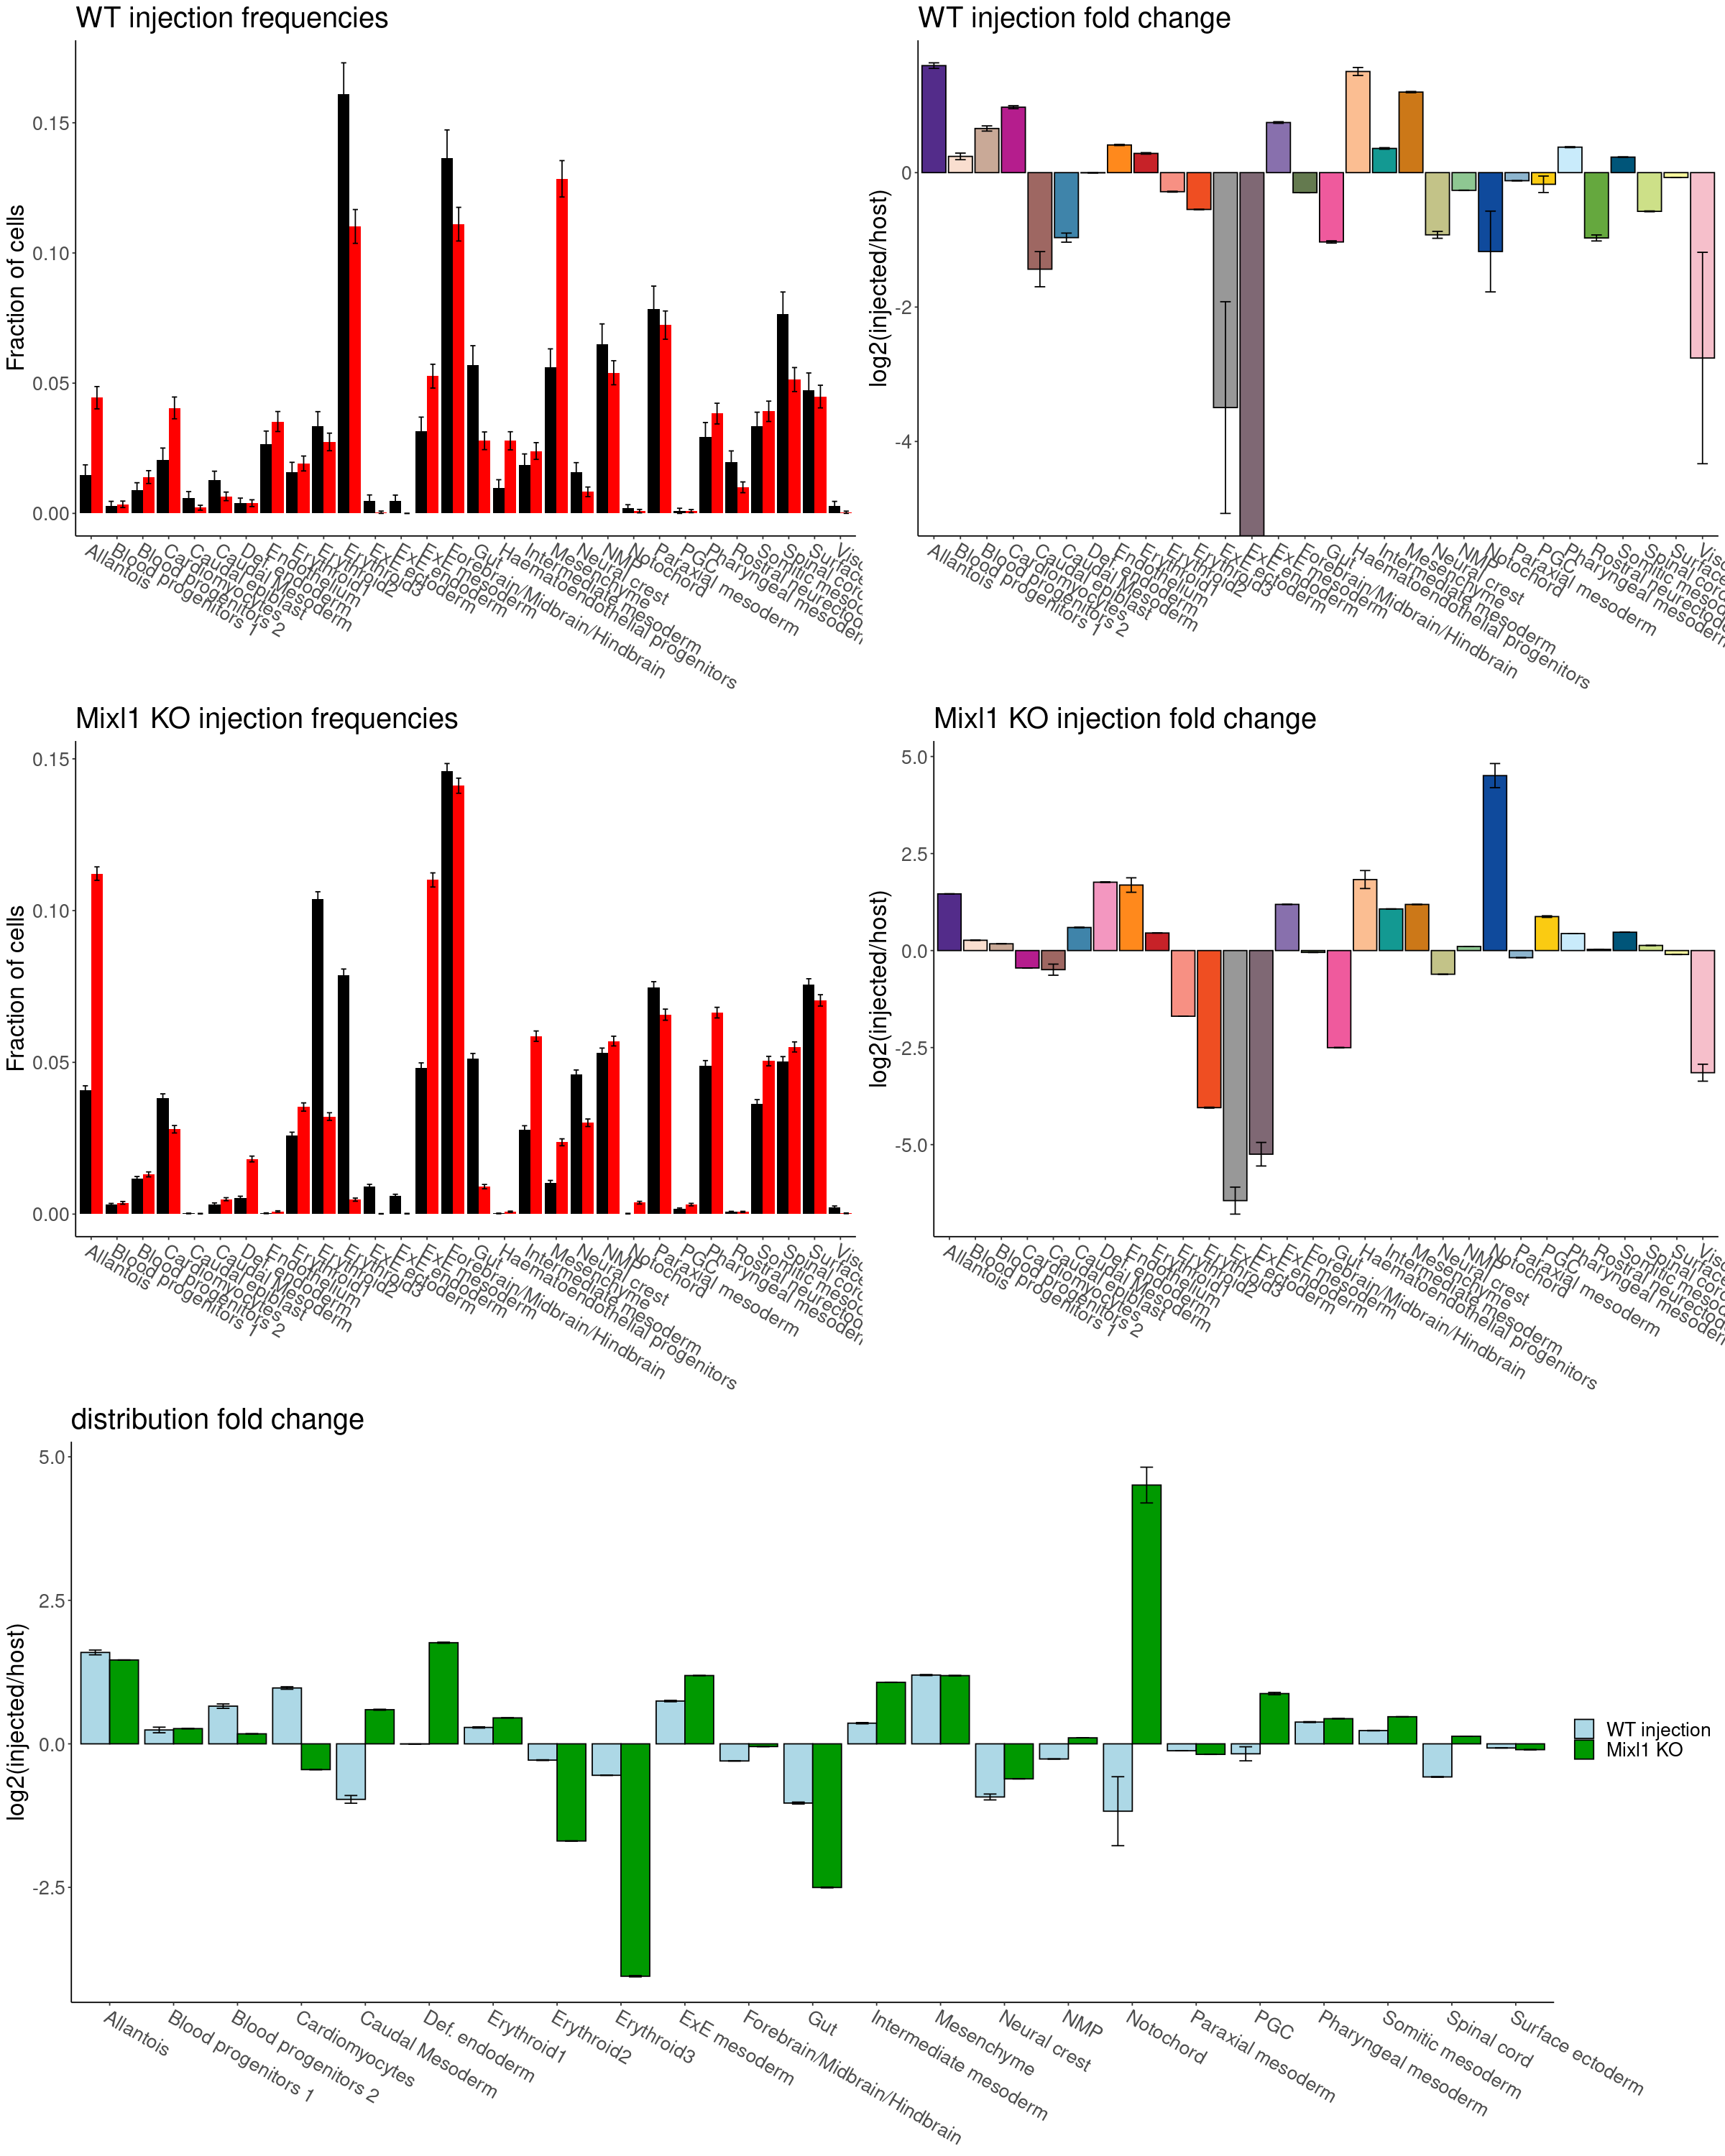

In [11]:
# using propagated error before n cell correction
p1 = plot_freq(wt, 'WT')
p2 = plot_ratio(wt_ratio, 'WT')
p3 = plot_freq(ko, 'Mixl1 KO')
p4 = plot_ratio(ko_ratio, 'Mixl1 KO')

options(repr.plot.width = 20, repr.plot.height = 25)
p = plot_grid(plot_grid(p1, p2, p3, p4, ncol = 2), plot_combined(combined_no_weird), rel_heights = c(0.65, 0.35), nrow = 2)
p

In [17]:
pdf(paste0(plot_folder, "distribution_proper_SEM.pdf"), height=20, width=25)
    p
dev.off()

pdf(paste0(plot_folder, "distribution_frequencies.pdf"), height=15, width=15)
    plot_grid(p3, p1, nrow = 2)
dev.off()

pdf(paste0(plot_folder, "distribution_fold.pdf"), height=15, width=15)
    plot_grid(p4, p2, nrow = 2)
dev.off()

pdf(paste0(plot_folder, "distribution_fold_changes_SEM.pdf"), height=8, width=15)
    plot_combined(combined_no_weird)
dev.off()

png 
  2

png 
  2

png 
  2

png 
  2

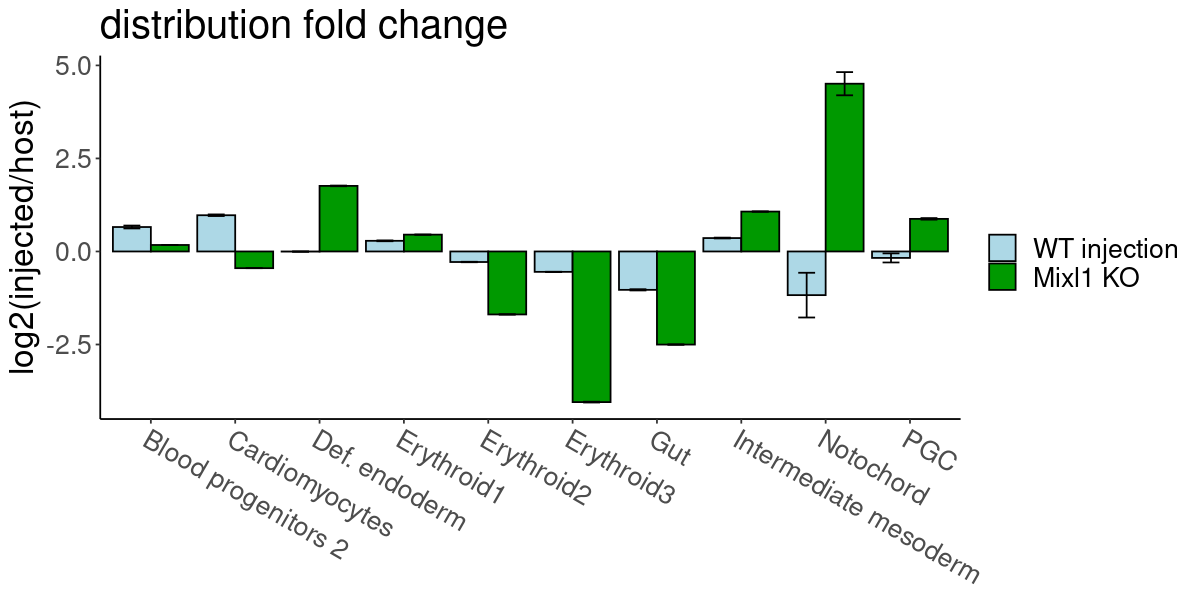

In [18]:
# plot only celltypes that are affected
include = c('Blood progenitors 2', 'Cardiomyocytes', 'Def. endoderm', 'Erythroid1', 'Erythroid2', 'Erythroid3', 'Gut', 'Intermediate mesoderm', 'Notochord', 'PGC')
combined_important = combined_no_weird %>% filter(Var1 %in% include)

options(repr.plot.width = 10, repr.plot.height = 5)
plot_combined(combined_important)

In [19]:
pdf(paste0(plot_folder, "distribution_fold_changes_important_SEM.pdf"), height=5, width=10)
    plot_combined(combined_important)
dev.off()

png 
  2